## Project Overview
This project uses machine learning to predict Airbnb listing prices in Toronto by combining listing-level features with broader city-level variables such as weather, tourism activity, local events, and other demand signals. This approach is supported by prior research showing that Airbnb prices are influenced by property, host, amenity, review, and location-related factors, while weather data helps capture seasonal and environmental variation in demand [1], [2].

## Problem Statement
Airbnb pricing in cities such as Toronto is shaped by multiple interacting factors, including listing characteristics, tourism patterns, seasonal conditions, and broader urban demand. Prior studies have shown that Airbnb prices are not determined by property features alone, which supports the use of a multi-factor modelling approach for prediction [1], [3].

## Project Objective
The objective of this project was to build a cleaned dataset that combines Airbnb listing data with external city-level indicators, compare several supervised learning models, evaluate performance using standard regression metrics, and identify the modelling approach that best predicts Toronto Airbnb prices. This is consistent with previous machine learning research that applies multiple predictive methods to Airbnb price estimation [2].

## Machine Learning Models Tested
The models evaluated were:
- Linear Regression
- K-Nearest Neighbours
- Decision Tree Regressor
- Random Forest Regressor
- Neural Network / Multilayer Perceptron

These models were chosen to compare baseline, distance-based, tree-based, ensemble, and nonlinear approaches, which is in line with prior Airbnb price prediction studies using machine learning and deep learning methods [2].



---
# Initial Data Cleaning

In [878]:
import pandas as pd

In [879]:
df = pd.read_csv("MSE 446 - Raw Project Data.csv")
print(df.head())

   listing_id        date  vacant_days  reserved_days  occupancy  revenue  \
0     4925824  2025-02-01           28              0        0.0        0   
1     4925824  2025-03-01           31              0        0.0        0   
2     4925824  2025-04-01           30              0        0.0        0   
3     4925824  2025-05-01           31              0        0.0        0   
4     4925824  2025-06-01           30              0        0.0        0   

  rate_avg               listing_type     room_type  photos_count  ...  \
0     36.3  Private room in townhouse  private_room             7  ...   
1     35.5  Private room in townhouse  private_room             7  ...   
2     35.9  Private room in townhouse  private_room             7  ...   
3       36  Private room in townhouse  private_room             7  ...   
4     36.5  Private room in townhouse  private_room             7  ...   

   rain_s  snow_v  snow_s  snow_on_ground_v  non_resident_visitors  \
0   17.62   28.99   17

In [880]:
print(df.shape)
print(df.columns.tolist())
df.info()
df.head()

(3236, 93)
['listing_id', 'date', 'vacant_days', 'reserved_days', 'occupancy', 'revenue', 'rate_avg', 'listing_type', 'room_type', 'photos_count', 'superhost', 'latitude', 'longitude', 'guests', 'bedrooms', 'beds', 'baths', 'amenities', 'min_nights', 'cancellation_policy', 'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate', 'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy', 'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar', 'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days', 'ttm_available_days', 'ttm_total_days', 'l90d_revenue', 'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native', 'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar', 'l90d_revpar_native', 'l90d_adjusted_revpar', 'l90d_adjusted_revpar_native', 'l90d_reserved_days', 'l90d_blocked

,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,listing_type,room_type,photos_count,...,rain_s,snow_v,snow_s,snow_on_ground_v,non_resident_visitors,Unnamed: 88,Unnamed: 89,Unnamed: 90,Unnamed: 91,Unnamed: 92
0,4925824,2025-02-01,28,0,0.0,0,36.3,Private room in townhouse,private_room,7,...,17.62,28.99,17.56,6.4,197392,NaN,NaN,NaN,NaN,NaN
1,4925824,2025-03-01,31,0,0.0,0,35.5,Private room in townhouse,private_room,7,...,21.35,16.94,12.79,3.0,251406,NaN,NaN,NaN,NaN,NaN
2,4925824,2025-04-01,30,0,0.0,0,35.9,Private room in townhouse,private_room,7,...,29.82,4.93,5.76,0.5,322508,NaN,NaN,NaN,NaN,NaN
3,4925824,2025-05-01,31,0,0.0,0,36,Private room in townhouse,private_room,7,...,33.46,0.13,0.58,0.0,384863,NaN,NaN,NaN,NaN,NaN
4,4925824,2025-06-01,30,0,0.0,0,36.5,Private room in townhouse,private_room,7,...,39.88,0.00,0.00,0.0,514456,NaN,NaN,NaN,NaN,NaN


In [881]:
# remove empty columns
df = df.drop(columns=["Unnamed: 88","Unnamed: 89","Unnamed: 90","Unnamed: 91","Unnamed: 92"])

In [882]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 3236 entries, 0 to 3235
Data columns (total 88 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   listing_id                   3236 non-null   int64  
 1   date                         3236 non-null   str    
 2   vacant_days                  3236 non-null   int64  
 3   reserved_days                3236 non-null   int64  
 4   occupancy                    3236 non-null   float64
 5   revenue                      3236 non-null   int64  
 6   rate_avg                     3236 non-null   str    
 7   listing_type                 3236 non-null   str    
 8   room_type                    3236 non-null   str    
 9   photos_count                 3236 non-null   int64  
 10  superhost                    3236 non-null   bool   
 11  latitude                     3236 non-null   float64
 12  longitude                    3236 non-null   float64
 13  guests                       

(3236, 88)

In [883]:
# convert data column to date time 
df["date"] = pd.to_datetime(df["date"])

In [884]:
df.head()

,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,listing_type,room_type,photos_count,...,min_temperature_s,min_wind_speed_v,precipitation_v,precipitation_s,rain_v,rain_s,snow_v,snow_s,snow_on_ground_v,non_resident_visitors
0,4925824,2025-02-01,28,0,0.0,0,36.3,Private room in townhouse,private_room,7,...,2.85,6.19,54.10,23.65,26.85,17.62,28.99,17.56,6.4,197392
1,4925824,2025-03-01,31,0,0.0,0,35.5,Private room in townhouse,private_room,7,...,2.22,6.19,51.09,22.55,34.94,21.35,16.94,12.79,3.0,251406
2,4925824,2025-04-01,30,0,0.0,0,35.9,Private room in townhouse,private_room,7,...,1.46,5.37,77.41,31.40,69.94,29.82,4.93,5.76,0.5,322508
3,4925824,2025-05-01,31,0,0.0,0,36,Private room in townhouse,private_room,7,...,1.79,3.89,74.07,33.34,73.94,33.46,0.13,0.58,0.0,384863
4,4925824,2025-06-01,30,0,0.0,0,36.5,Private room in townhouse,private_room,7,...,1.02,3.89,81.50,39.88,81.50,39.88,0.00,0.00,0.0,514456


In [885]:
# convert rate_age to numeric number 
df["rate_avg"] = pd.to_numeric(df["rate_avg"], errors="coerce")

In [886]:
df["rate_avg"].head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3236 entries, 0 to 3235
Data columns (total 88 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   listing_id                   3236 non-null   int64         
 1   date                         3236 non-null   datetime64[us]
 2   vacant_days                  3236 non-null   int64         
 3   reserved_days                3236 non-null   int64         
 4   occupancy                    3236 non-null   float64       
 5   revenue                      3236 non-null   int64         
 6   rate_avg                     3235 non-null   float64       
 7   listing_type                 3236 non-null   str           
 8   room_type                    3236 non-null   str           
 9   photos_count                 3236 non-null   int64         
 10  superhost                    3236 non-null   bool          
 11  latitude                     3236 non-null   float64  

In [887]:
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()

In [888]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3236 entries, 0 to 3235
Data columns (total 90 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   listing_id                   3236 non-null   int64         
 1   date                         3236 non-null   datetime64[us]
 2   vacant_days                  3236 non-null   int64         
 3   reserved_days                3236 non-null   int64         
 4   occupancy                    3236 non-null   float64       
 5   revenue                      3236 non-null   int64         
 6   rate_avg                     3235 non-null   float64       
 7   listing_type                 3236 non-null   str           
 8   room_type                    3236 non-null   str           
 9   photos_count                 3236 non-null   int64         
 10  superhost                    3236 non-null   bool          
 11  latitude                     3236 non-null   float64  

In [889]:
month_dummies = pd.get_dummies(df["month_name"], prefix="is")

month_dummies = month_dummies.astype(int)

month_dummies.columns = month_dummies.columns.str.lower()

df = pd.concat([df, month_dummies], axis=1)

In [890]:
df.filter(like="is_").head()

,is_winter,is_spring,is_summer,is_fall,is_april,is_august,is_december,is_february,is_july,is_june,is_march,is_may,is_november,is_october,is_september
0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0


In [891]:
# Removes december to avoid dummy trap variable 
df = df.drop(columns=["is_december"])

In [892]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 3236 entries, 0 to 3235
Data columns (total 100 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   listing_id                   3236 non-null   int64         
 1   date                         3236 non-null   datetime64[us]
 2   vacant_days                  3236 non-null   int64         
 3   reserved_days                3236 non-null   int64         
 4   occupancy                    3236 non-null   float64       
 5   revenue                      3236 non-null   int64         
 6   rate_avg                     3235 non-null   float64       
 7   listing_type                 3236 non-null   str           
 8   room_type                    3236 non-null   str           
 9   photos_count                 3236 non-null   int64         
 10  superhost                    3236 non-null   bool          
 11  latitude                     3236 non-null   float64 

,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,listing_type,room_type,photos_count,...,is_april,is_august,is_february,is_july,is_june,is_march,is_may,is_november,is_october,is_september
0,4925824,2025-02-01,28,0,0.0,0,36.3,Private room in townhouse,private_room,7,...,0,0,1,0,0,0,0,0,0,0
1,4925824,2025-03-01,31,0,0.0,0,35.5,Private room in townhouse,private_room,7,...,0,0,0,0,0,1,0,0,0,0
2,4925824,2025-04-01,30,0,0.0,0,35.9,Private room in townhouse,private_room,7,...,1,0,0,0,0,0,0,0,0,0
3,4925824,2025-05-01,31,0,0.0,0,36.0,Private room in townhouse,private_room,7,...,0,0,0,0,0,0,1,0,0,0
4,4925824,2025-06-01,30,0,0.0,0,36.5,Private room in townhouse,private_room,7,...,0,0,0,0,1,0,0,0,0,0


In [893]:
df["superhost"] = df["superhost"].astype(int)

In [894]:
df["superhost"].head(50)

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    0
42    0
43    0
44    0
45    0
46    0
47    0
48    0
49    0
Name: superhost, dtype: int64

In [895]:
df["has_free_parking"] = df["amenities"].str.contains("free parking", case=False, na=False).astype(int)

df["has_gym"] = df["amenities"].str.contains("gym", case=False, na=False).astype(int)

df["has_pool"] = df["amenities"].str.contains("pool", case=False, na=False).astype(int)

In [896]:
df[["has_free_parking","has_gym","has_pool"]].head()

,has_free_parking,has_gym,has_pool
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


In [897]:
# after creating dummy columns drop the amenities column 
df = df.drop(columns=["amenities"])

In [898]:
# check remaing text colums 
df.select_dtypes(include="object").columns

/tmp/ipykernel_9621/1515808039.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['listing_type', 'room_type', 'cancellation_policy', 'month_name'], dtype='str')

In [899]:
df = df.drop(columns=["month_name"])

In [900]:
categorical_cols = ["listing_type", "room_type", "cancellation_policy"]
# create dummy vars and drop one to avoid dummy var trap
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [901]:
df.filter(regex="listing_type|room_type|cancellation_policy").head()

,listing_type_Entire condo,listing_type_Entire condominium,listing_type_Entire guest suite,listing_type_Entire guesthouse,listing_type_Entire home,listing_type_Entire house,listing_type_Entire loft,listing_type_Entire place,listing_type_Entire rental unit,listing_type_Entire townhouse,...,listing_type_Private room in home,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,False,False


In [902]:
df = df.apply(lambda col: col.astype(int) if col.dtype == "bool" else col)

In [903]:
df.head()

,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,photos_count,superhost,latitude,...,listing_type_Private room in home,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days
0,4925824,2025-02-01,28,0,0.0,0,36.3,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
1,4925824,2025-03-01,31,0,0.0,0,35.5,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
2,4925824,2025-04-01,30,0,0.0,0,35.9,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
3,4925824,2025-05-01,31,0,0.0,0,36.0,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
4,4925824,2025-06-01,30,0,0.0,0,36.5,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0


In [904]:
print(df.shape)

(3236, 124)


In [905]:
df.duplicated().sum()

np.int64(0)

In [906]:
df.isnull().sum().sort_values(ascending=False).head(20)

rate_avg           1
listing_id         0
vacant_days        0
date               0
reserved_days      0
occupancy          0
revenue            0
photos_count       0
superhost          0
latitude           0
longitude          0
guests             0
bedrooms           0
beds               0
baths              0
min_nights         0
cleaning_fee       0
extra_guest_fee    0
num_reviews        0
rating_overall     0
dtype: int64

In [907]:
df["rate_avg"] = df["rate_avg"].fillna(df["rate_avg"].median())

In [908]:
df.isnull().sum().sort_values(ascending=False).head(20)

listing_id         0
date               0
vacant_days        0
reserved_days      0
occupancy          0
revenue            0
rate_avg           0
photos_count       0
superhost          0
latitude           0
longitude          0
guests             0
bedrooms           0
beds               0
baths              0
min_nights         0
cleaning_fee       0
extra_guest_fee    0
num_reviews        0
rating_overall     0
dtype: int64

In [909]:
# if num of bedrooms or beds is greater than zero and current guests = 1 assume 1 guest
df.loc[(df["guests"] == 0) & ((df["beds"] > 0) | (df["bedrooms"] > 0)),
    "guests"] = 1

In [910]:
# If bedrooms are 0 but beds exist could mean studio or private room so set bedrooms to 1
df.loc[(df["bedrooms"] == 0) & (df["beds"] > 0), "bedrooms"] = 1

In [911]:
df[(df["guests"] == 0)][["guests","bedrooms","beds"]].head()

,guests,bedrooms,beds


In [912]:
#esnure guests is never zero if guests is listed as zero replace with 1
df.loc[df["guests"] < 1, "guests"] = 1

In [913]:
df.shape
df.head()

,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,photos_count,superhost,latitude,...,listing_type_Private room in home,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days
0,4925824,2025-02-01,28,0,0.0,0,36.3,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
1,4925824,2025-03-01,31,0,0.0,0,35.5,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
2,4925824,2025-04-01,30,0,0.0,0,35.9,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
3,4925824,2025-05-01,31,0,0.0,0,36.0,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
4,4925824,2025-06-01,30,0,0.0,0,36.5,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0


In [914]:
print("DATASET SHAPE")
print(df.shape)

print("\nFIRST 5 ROWS")
print(df.head())

print("\nCOLUMN INFO")
print(df.info())

print("\nTOP 20 MISSING VALUES")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nNUMBER OF DUPLICATE ROWS")
print(df.duplicated().sum())

print("\nNUMERIC SUMMARY")
print(df.describe().T)

print("\nOBJECT (CATEGORICAL) COLUMNS")
print(df.select_dtypes(include="object").columns)

print("\nTOTAL NUMBER OF FEATURES")
print(len(df.columns))

DATASET SHAPE
(3236, 124)

FIRST 5 ROWS
   listing_id       date  vacant_days  reserved_days  occupancy  revenue  \
0     4925824 2025-02-01           28              0        0.0        0   
1     4925824 2025-03-01           31              0        0.0        0   
2     4925824 2025-04-01           30              0        0.0        0   
3     4925824 2025-05-01           31              0        0.0        0   
4     4925824 2025-06-01           30              0        0.0        0   

   rate_avg  photos_count  superhost  latitude  ...  \
0      36.3             7          1   43.6483  ...   
1      35.5             7          1   43.6483  ...   
2      35.9             7          1   43.6483  ...   
3      36.0             7          1   43.6483  ...   
4      36.5             7          1   43.6483  ...   

   listing_type_Private room in home  listing_type_Private room in loft  \
0                                  0                                  0   
1                     

In [915]:
df.to_csv("MSE446_cleaned_dataset.csv", index=False)

---
# Exploratory Data Analysis

The purpose of this EDA is to understand the main patterns in our dataset before modelling. In particular, we want to examine how listing characteristics, amenities, time-related variables, and external factors relate to the average nightly price, and identify any redundancy or potential leakage among the features.

In [916]:
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt

In [917]:
df = pd.read_csv("MSE446_cleaned_dataset.csv")

In [918]:
df["date"] = pd.to_datetime(df["date"])
# Data Set Overview 
print("Dataset Shape:")
print(df.shape)

print("\nColumn Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df.head()

Dataset Shape:
(3236, 124)

Column Types:
listing_id                                           int64
date                                        datetime64[us]
vacant_days                                          int64
reserved_days                                        int64
occupancy                                          float64
                                                 ...      
cancellation_policy_Flexible                         int64
cancellation_policy_Limited                          int64
cancellation_policy_Moderate                         int64
cancellation_policy_Strict                           int64
cancellation_policy_Super Strict 30 Days             int64
Length: 124, dtype: object

Missing Values:
listing_id       0
date             0
vacant_days      0
reserved_days    0
occupancy        0
revenue          0
rate_avg         0
photos_count     0
superhost        0
latitude         0
dtype: int64

Duplicate Rows:
0


,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,photos_count,superhost,latitude,...,listing_type_Private room in home,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days
0,4925824,2025-02-01,28,0,0.0,0,36.3,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
1,4925824,2025-03-01,31,0,0.0,0,35.5,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
2,4925824,2025-04-01,30,0,0.0,0,35.9,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
3,4925824,2025-05-01,31,0,0.0,0,36.0,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
4,4925824,2025-06-01,30,0,0.0,0,36.5,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0


### Dataset Overview

Checking the dataset shape, column types, missing values, and duplicate rows to confirm that the cleaned dataset is ready for exploratory data analysis. This gives a quick overview of the structure of the data and helps verify that no major data quality issues remain before modelling.

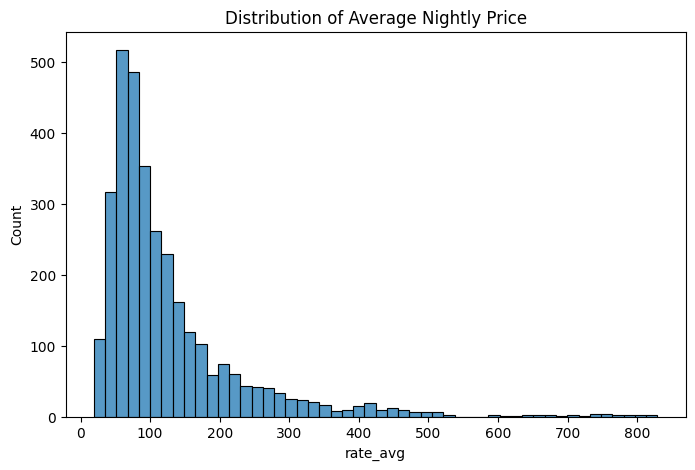

In [919]:
plt.figure(figsize=(8,5))
sns.histplot(df["rate_avg"], bins=50)
plt.title("Distribution of Average Nightly Price")
plt.xlabel("rate_avg")
plt.show()

### Distribution of Average Nightly Price

Starting off with a histogram to show the distribution of listing prices across the dataset, we can see that most listings fall within the $50 to $150 range.

The distribution is right-skewed, with a long tail extending towards higher prices, which suggests the presence of a smaller number of high-priced listings (outliers).

This is important because skewness in the target variable can impact model performance, especially for linear regression. We may consider a transformation (such as log(price)) in modelling to decrease the effect of these more-"extreme" values.

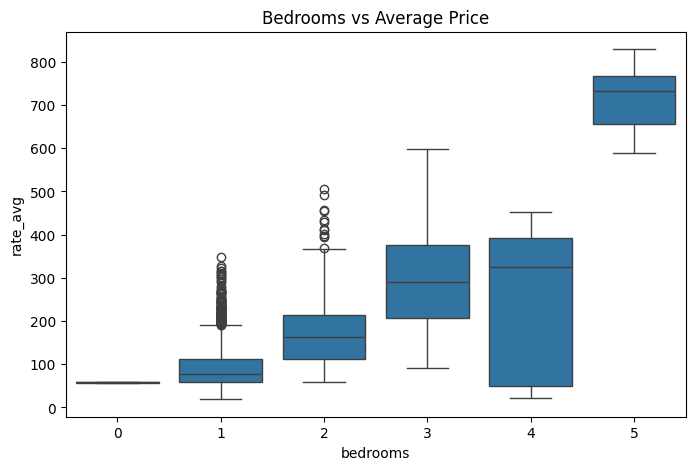

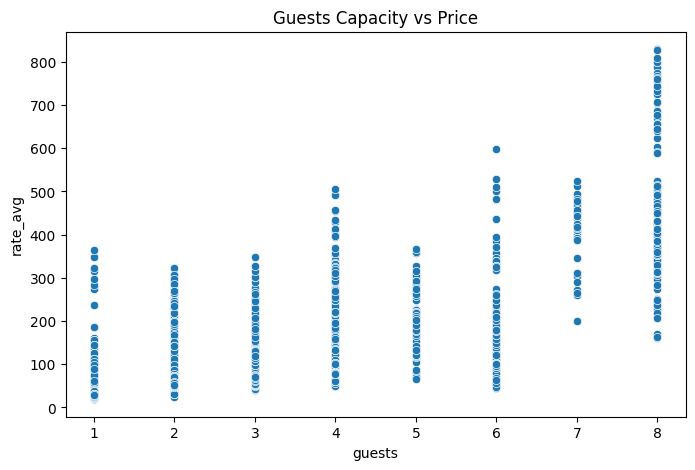

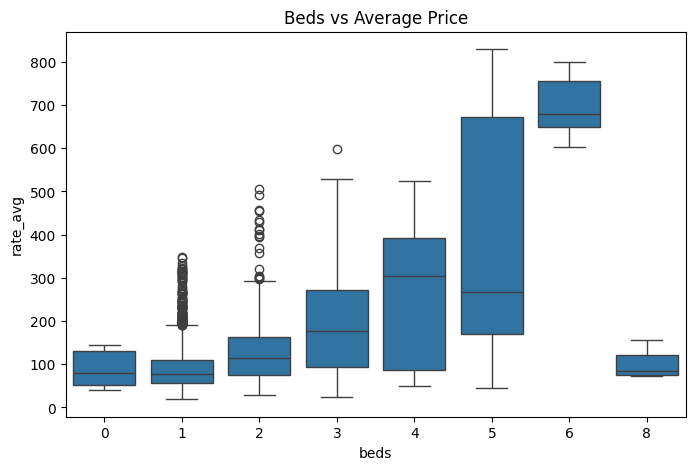

In [920]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["bedrooms"], y=df["rate_avg"])
plt.title("Bedrooms vs Average Price")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["guests"], y=df["rate_avg"])
plt.title("Guests Capacity vs Price")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["beds"], y=df["rate_avg"])
plt.title("Beds vs Average Price")
plt.show()

### Listing Size Features vs Price

These plots examine how listing size features (bedrooms, guest capacity, and number of beds) relate to the average price.

Overall, we can clearly observe a positive relationship. As the size and capacity of a listing increase, the average nightly price also tends to increase. Listings with more bedrooms and higher guest capacity generally have higher median prices and a wider range of values.

However, the variability within each category suggests that, while features related to size are important predictors of price, they are not the only factors influencing pricing.

These features are likely to be strong inputs for the predictive model, but additional variables will be needed to fully explain price differences.

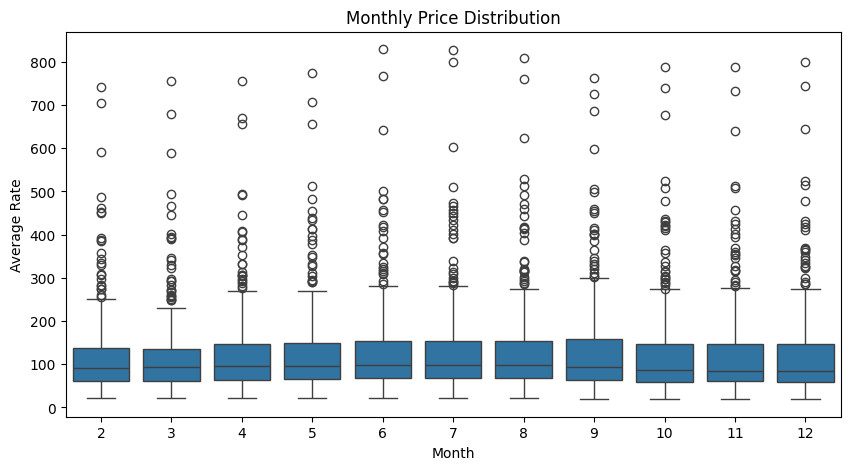

In [921]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["date"].dt.month, y=df["rate_avg"])
plt.title("Monthly Price Distribution")
plt.xlabel("Month")
plt.ylabel("Average Rate")
plt.show()


### Monthly Price Distribution

This box plot shows how listing prices vary across different months of the year. Overall, the median prices remain relatively consistent, with only a slight increase during the middle of the year (summer months).

There are some higher-priced outliers in certain months, but there isn't exactly a strong seasonal pattern in prices, which tells us that the month/time of year could have just a limited impact on pricing compared to the other features.

However, since there are small variations, month can still be included as a feature to capture any seasonal effects in the model, even if they are minor.

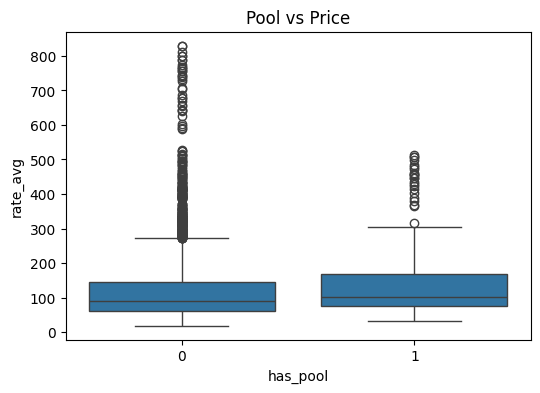

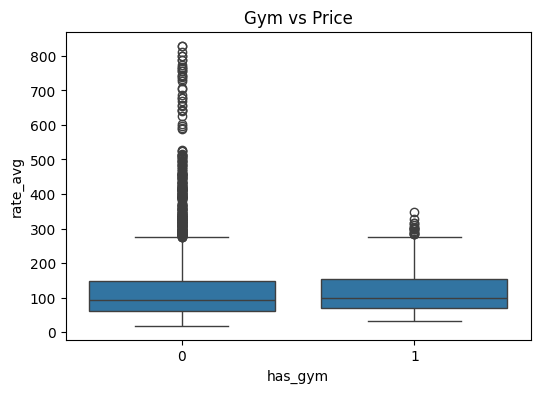

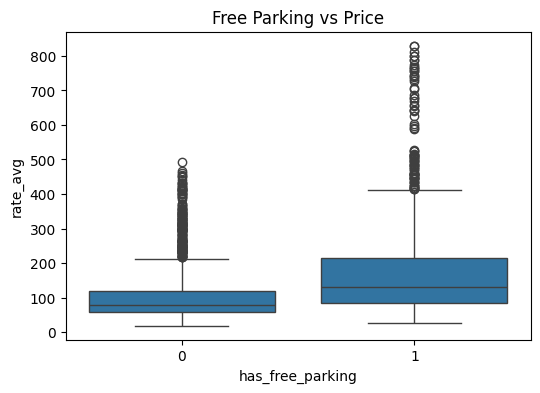

In [922]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["has_pool"], y=df["rate_avg"])
plt.title("Pool vs Price")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["has_gym"], y=df["rate_avg"])
plt.title("Gym vs Price")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["has_free_parking"], y=df["rate_avg"])
plt.title("Free Parking vs Price")
plt.show()

### Amenities vs Price

These plots allow us to compare the effect that amenities have on listing prices (pool, gym, and free parking)

Listings that include these amenities generally have slightly higher median prices compared to those that do not. However, there is significant overlap in price distributions between listings with and without these amenities, which indicates that they are not critical or primary drivers, but still provide useful information

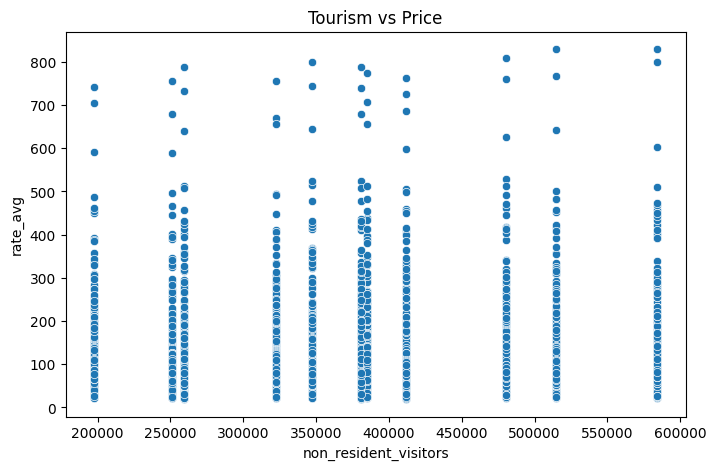

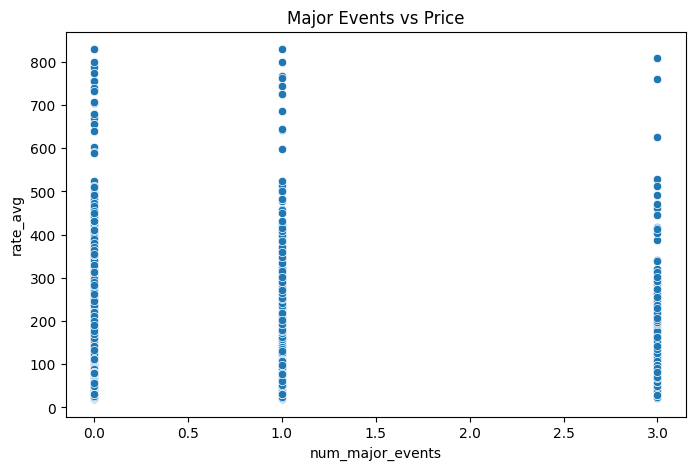

In [923]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["non_resident_visitors"], y=df["rate_avg"])
plt.title("Tourism vs Price")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["num_major_events"], y=df["rate_avg"])
plt.title("Major Events vs Price")
plt.show()

### Tourism and Events vs Price

These plots show us how/if external demand factors, such as tourism levels and major events, relate to listing prices.

There is no strong visible relationship between the number of non-resident visitors and price, as prices remain widely distributed across all tourism levels. This suggests that tourism alone may not be the best predictor for pricing.

Similarly, the number of major events shows a weak trend, with slightly higher prices in months with more events, but a lot of overlap across all categories.

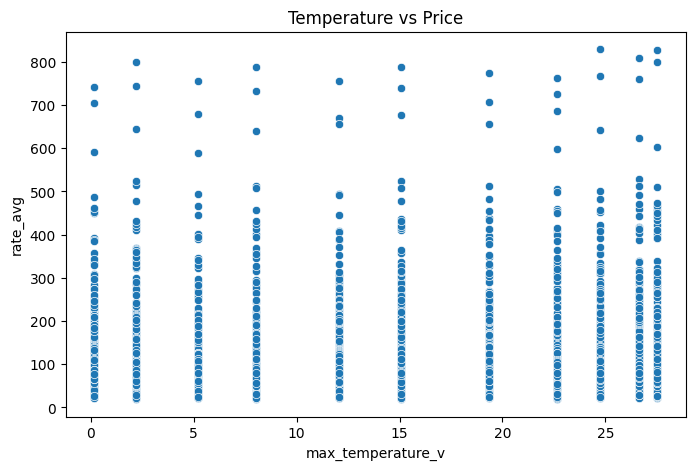

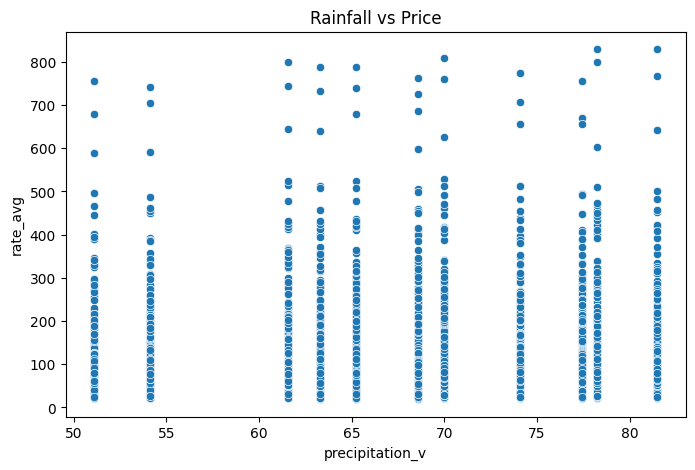

In [924]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["max_temperature_v"], y=df["rate_avg"])
plt.title("Temperature vs Price")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["precipitation_v"], y=df["rate_avg"])
plt.title("Rainfall vs Price")
plt.show()

### Weather vs Price

These plots explore the relationship between weather conditions (temperature and rainfall) and listing prices.

We don't see a clear relationship between temperature and price, as listings are spread across all price levels regardless of temperature. Similarly, rainfall does not show any strong pattern, with prices being widely distributed across different precipitation levels.

These weather variables could potentially capture and relate to seasonal effects, but they don't significantly influence pricing.

In [925]:
corr_target = df.corr()["rate_avg"].sort_values(ascending=False)

print("\nTop 50 Features Correlated with Price:")
print(corr_target.head(50))


Top 50 Features Correlated with Price:
rate_avg                           1.000000
ttm_avg_rate_native                0.974066
ttm_avg_rate                       0.974062
l90d_avg_rate                      0.926502
l90d_avg_rate_native               0.926488
bedrooms                           0.728454
guests                             0.720947
baths                              0.642458
ttm_revpar                         0.620521
ttm_revpar_native                  0.620055
ttm_revenue                        0.618774
ttm_revenue_native                 0.618357
beds                               0.567727
ttm_adjusted_revpar                0.517727
ttm_adjusted_revpar_native         0.517148
revenue                            0.497300
listing_type_Entire home           0.484531
cleaning_fee                       0.369838
l90d_revenue                       0.329042
l90d_revenue_native                0.329030
has_free_parking                   0.327361
l90d_revpar_native                 0

### Correlation with Price

This output shows the features most strongly correlated with average nightly price.

Many of the features that have a strong positive correlations with price are related to listing size (bedrooms, guests, baths, and beds). This aligns with the previous visuals, confirming that larger listings tend to be more expensive. Amenities and rating-related features, or weather and tourism variables have very low correlations, reinforcing that they have a smaller impact on pricing.

There are also very high correlations with variables such as `ttm_avg_rate` and `l90d_avg_rate`. However, these are derived pricing metrics and are related to the target variable itself, so they may introduce data leakage if used in our model.

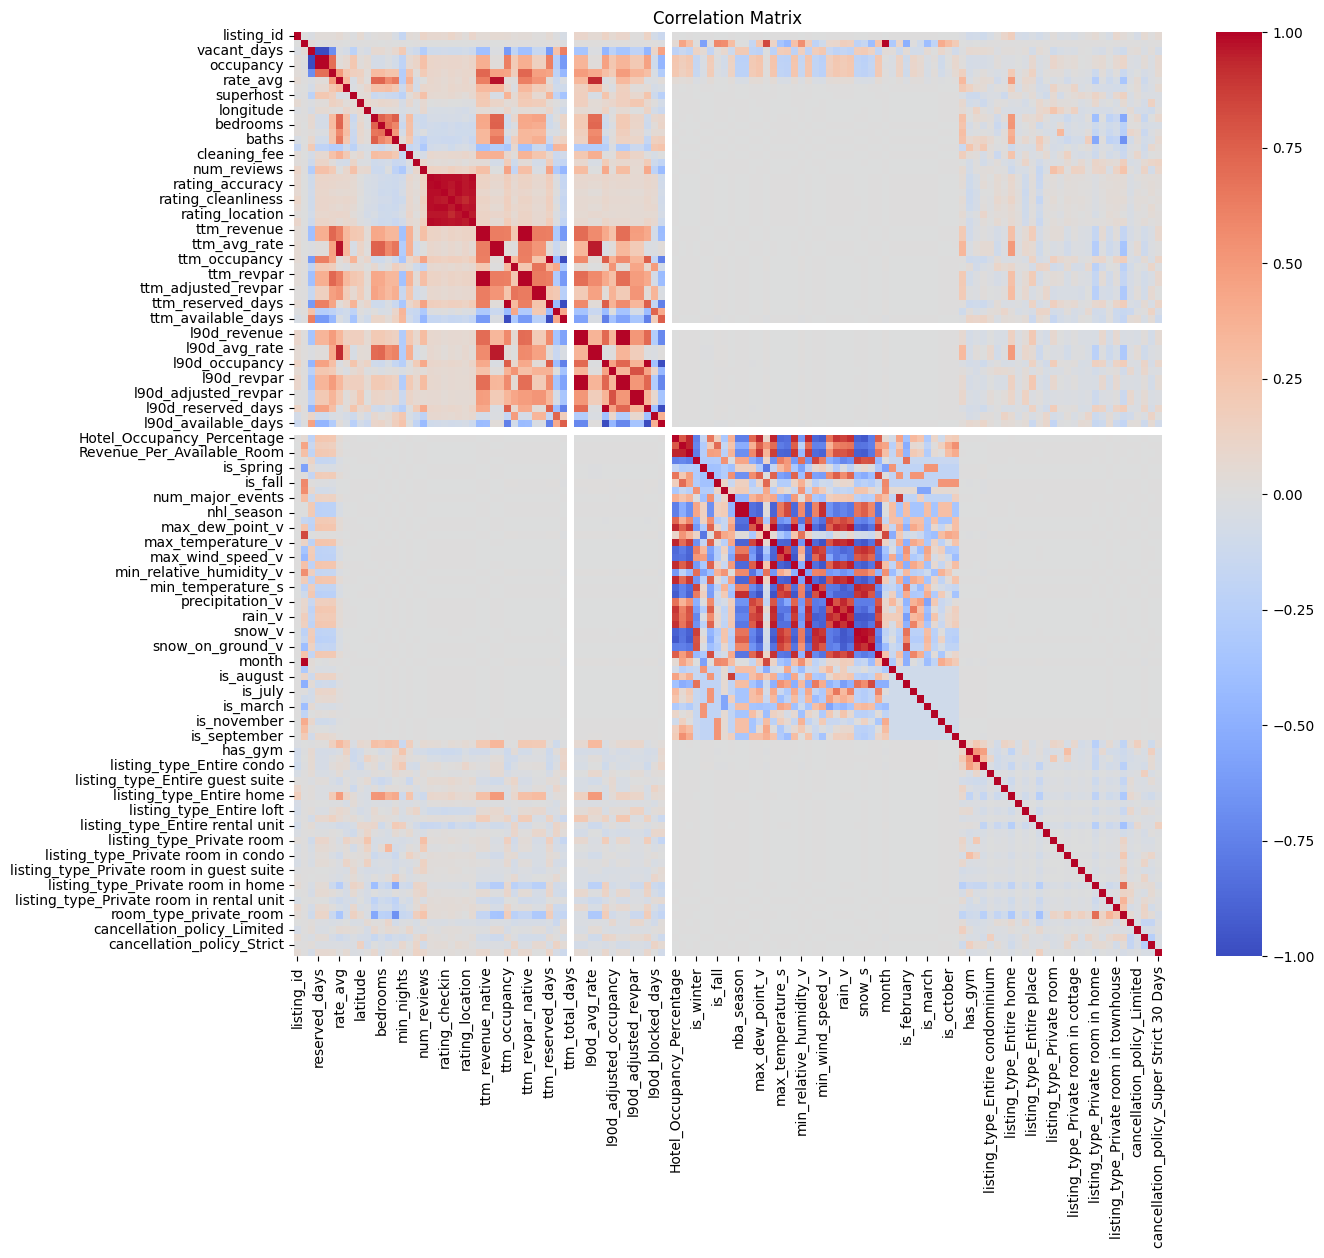

In [926]:
plt.figure(figsize=(14,12))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix

This heatmap shows the pairwise correlations between all numerical features in the dataset.

Clusters of highly correlated variables are observed, particularly with pricing-related and revenue-based features. This shows some overlap (redundancy), as many of the variables capture similar information. Size-related features such as bedrooms, guests, and beds also show positive correlations with pricing variables, while weather, tourism, and some categorical variables show relatively weak correlations with most features - this all reflects what was previously observed.

This highlights potential multicollinearity in the dataset and again emphasizes the need to carefully select our features before modeling.

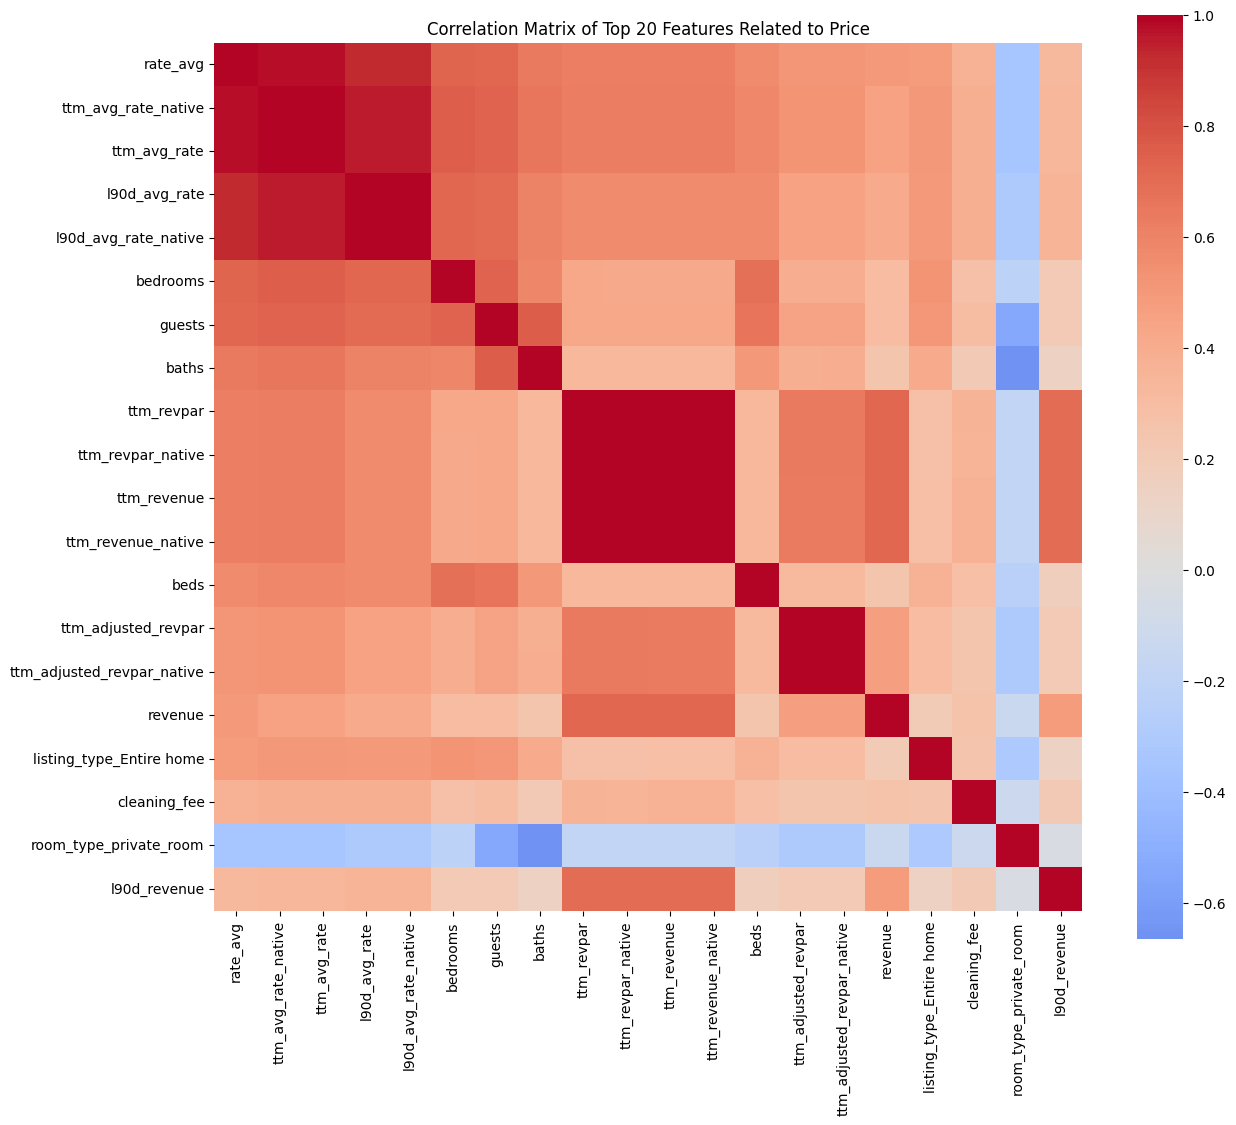

In [927]:
corr_with_target = df.corr()["rate_avg"].abs().sort_values(ascending=False)
top_20_features = corr_with_target.head(20).index
top_corr_matrix = df[top_20_features].corr()

plt.figure(figsize=(14,12))

sns.heatmap(
    top_corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Top 20 Features Related to Price")

plt.show()

### Correlation Matrix of Top Features

This heatmap focuses on the top 20 features most strongly correlated with average nightly price.

Strong positive relationships are observed between price and pricing/revenue-related metrics, such as `ttm_avg_rate`, `l90d_avg_rate`, and `ttm_revpar`, indicating that historical pricing and performance metrics are highly predictive of current prices. This again indicates redundancy.

Interestingly, features like `cleaning_fee` and certain listing types (e.g., entire home) are positively associated with price, while private room listings show a negative correlation.

In [928]:
import numpy as np  

corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool) 
)

high_corr = [column for column in upper.columns if any(upper[column] > 0.9)]

print("\nHighly Correlated Features (>0.9):")
print(high_corr)


Highly Correlated Features (>0.9):
['reserved_days', 'occupancy', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 'ttm_revenue_native', 'ttm_avg_rate', 'ttm_avg_rate_native', 'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_available_days', 'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native', 'l90d_revpar', 'l90d_revpar_native', 'l90d_adjusted_revpar_native', 'l90d_reserved_days', 'l90d_available_days', 'Revenue_Per_Available_Room', 'nhl_season', 'max_dew_point_v', 'max_temperature_v', 'max_wind_speed_v', 'min_dew_point_v', 'min_temperature_v', 'min_temperature_s', 'min_wind_speed_v', 'precipitation_s', 'rain_v', 'rain_s', 'snow_v', 'snow_s', 'snow_on_ground_v', 'non_resident_visitors', 'month']


### Highly Correlated Features

We identified features with very high correlation above 0.9 to check for redundancy in the dataset.

A large number of pricing, revenue, rating, and weather variables are highly correlated with each other, which suggests that several of them are capturing almost the same information. This will help guide feature selection before modeling, since keeping too many overlapping variables may make the model less efficient and harder to interpret.

### Overall EDA Summary

From the exploratory analysis, listing size features such as bedrooms, guests, baths, and beds appear to have the clearest relationship with price. Amenities such as free parking, pools, and gyms show some effect, but their impact is smaller. In contrast, weather, tourism, and event-related variables do not show strong direct relationships with price.

The correlation analysis also shows that many pricing and revenue-based variables are highly correlated with the target and with each other. Because of this, the modeling stage will need to consider both feature redundancy and possible data leakage when selecting variables.

---
# Post EDA - Further Data Cleaning

This notebook contains the cleaning steps and updated top-20 correlation analysis moved from the post-EDA workflow. 

Based on the results of our EDA, we finalized the dataset by removing features that could introduce data leakage, redundancy, or limited predictive value.

In [929]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

new_df = pd.read_csv("MSE446_cleaned_dataset.csv")


### Analysis of EDA & Further Data Cleaning

Based on the results of our EDA, we will finalize our dataset before we begin modelling.

The ttm_ and l90d_ features represent historical pricing and performance metrics and are directly derived from pricing and booking outcomes, making them highly correlated with the target variable (rate_avg).

Including these features would introduce data leakage, as they contain information that would not be available when setting a price for a listing. 

In [930]:
# Remove all columns that start with 'ttm_' or 'l90d_'
cols_to_drop = [col for col in new_df.columns if col.startswith("ttm_") or col.startswith("l90d_")]
new_df = new_df.drop(columns=cols_to_drop)

print("Dropped columns:")
print(cols_to_drop)

Dropped columns:
['ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate', 'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy', 'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar', 'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days', 'ttm_available_days', 'ttm_total_days', 'l90d_revenue', 'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native', 'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar', 'l90d_revpar_native', 'l90d_adjusted_revpar', 'l90d_adjusted_revpar_native', 'l90d_reserved_days', 'l90d_blocked_days', 'l90d_available_days', 'l90d_total_days']


During EDA, a clear outlier we identfied was a listing with 8 beds, which had very low prices. These extreme values could disproportionately influence model training and distort relationships between listing size and price. To improve model stability and reduce the impact of outliers, these observations were removed.

In [931]:
# Remove rows where beds = 8
new_df = new_df[new_df["beds"] != 8]

print("New shape after removing beds=8:")
print(new_df.shape)
print(new_df["beds"].value_counts())

New shape after removing beds=8:
(3225, 96)
beds
1    1876
2     759
3     282
4     187
5      66
0      44
6      11
Name: count, dtype: int64


Additional columns were removed based on their lack of relevance or predictive usefulness:

listing_id was removed as it is simply an identifier and does not provide meaningful information for our prediction.

Seasonal indicator variables (e.g., nba_season, nhl_season, mlb_season) were removed due to their limited variation and weak relationship with price observed during EDA.

Detailed weather variables (e.g., dew point, humidity, wind speed, precipitation components) were removed to reduce redundancy and noise, as these variables showed minimal impact on pricing and were highly correlated with each other.

The variables revenue, occupancy, and reserved_days were removed as they represent outcomes of pricing decisions rather than independent predictors.

These variables are determined after a listing is priced and booked, meaning they are influenced by the target variable itself. Including them would introduce data leakage and could lead to overly optimistic model performance.

To ensure the model reflects a realistic pricing scenario, only features available prior to pricing were retained.

In [932]:
# Remove additional ID, date, season, and weather columns
extra_cols_to_remove = [
    "listing_id", "date", "nba_season", "nhl_season", "mlb_season",
    "max_dew_point_v", "max_relative_humidity_v", "max_temperature_s", "max_wind_speed_v",
    "min_dew_point_v", "min_relative_humidity_v", "min_temperature_s", "min_wind_speed_v",
    "precipitation_v", "precipitation_s", "rain_v", "rain_s", "snow_v", "snow_s",
    "snow_on_ground_v", "revenue", "occupancy", "reserved_days", "vacant_days"
]

existing_extra_cols = [col for col in extra_cols_to_remove if col in new_df.columns]
missing_extra_cols = [col for col in extra_cols_to_remove if col not in new_df.columns]

new_df = new_df.drop(columns=existing_extra_cols)

print("Dropped extra columns:")
print(existing_extra_cols)

if missing_extra_cols:
    print("\nColumns not found (already absent):")
    print(missing_extra_cols)

print("\nShape after extra column removal:")
print(new_df.shape)

Dropped extra columns:
['listing_id', 'date', 'nba_season', 'nhl_season', 'mlb_season', 'max_dew_point_v', 'max_relative_humidity_v', 'max_temperature_s', 'max_wind_speed_v', 'min_dew_point_v', 'min_relative_humidity_v', 'min_temperature_s', 'min_wind_speed_v', 'precipitation_v', 'precipitation_s', 'rain_v', 'rain_s', 'snow_v', 'snow_s', 'snow_on_ground_v', 'revenue', 'occupancy', 'reserved_days', 'vacant_days']

Shape after extra column removal:
(3225, 72)


The minimum and maximum temperature variables were combined into a single avg_temp feature to simplify the representation of weather conditions.

This reduces redundancy while still capturing overall temperature trends, making the dataset more efficient and interpretable for modelling.

In [933]:
# Create average temperature and remove source temperature columns
temp_cols = ["min_temperature_v", "max_temperature_v"]

if all(col in new_df.columns for col in temp_cols):
    new_df["avg_temp"] = (new_df["min_temperature_v"] + new_df["max_temperature_v"]) / 2
    new_df = new_df.drop(columns=temp_cols)
    print("Created 'avg_temp' and dropped min_temperature_v, max_temperature_v")
else:
    missing_temp_cols = [col for col in temp_cols if col not in new_df.columns]
    print("Could not create avg_temp. Missing columns:")
    print(missing_temp_cols)

print("Current shape:")
print(new_df.shape)

Created 'avg_temp' and dropped min_temperature_v, max_temperature_v
Current shape:
(3225, 71)


After cleaning, a final correlation analysis was performed to identify the most relevant remaining features.

The results confirm that listing size attributes (e.g., bedrooms, guests, baths, beds) remain the strongest predictors of price, while other features such as amenities and location contribute to a lesser extent.

This step validates that the dataset is now well-structured and suitable for model training.

Top 20 remaining features by |correlation| with rate_avg:
['bedrooms', 'guests', 'baths', 'beds', 'listing_type_Entire home', 'cleaning_fee', 'room_type_private_room', 'has_free_parking', 'photos_count', 'min_nights', 'listing_type_Private room in home', 'cancellation_policy_Moderate', 'latitude', 'listing_type_Private room in rental unit', 'rating_location', 'listing_type_Entire guest suite', 'listing_type_Entire rental unit', 'rating_overall', 'listing_type_Private room in condo', 'listing_type_Entire loft']


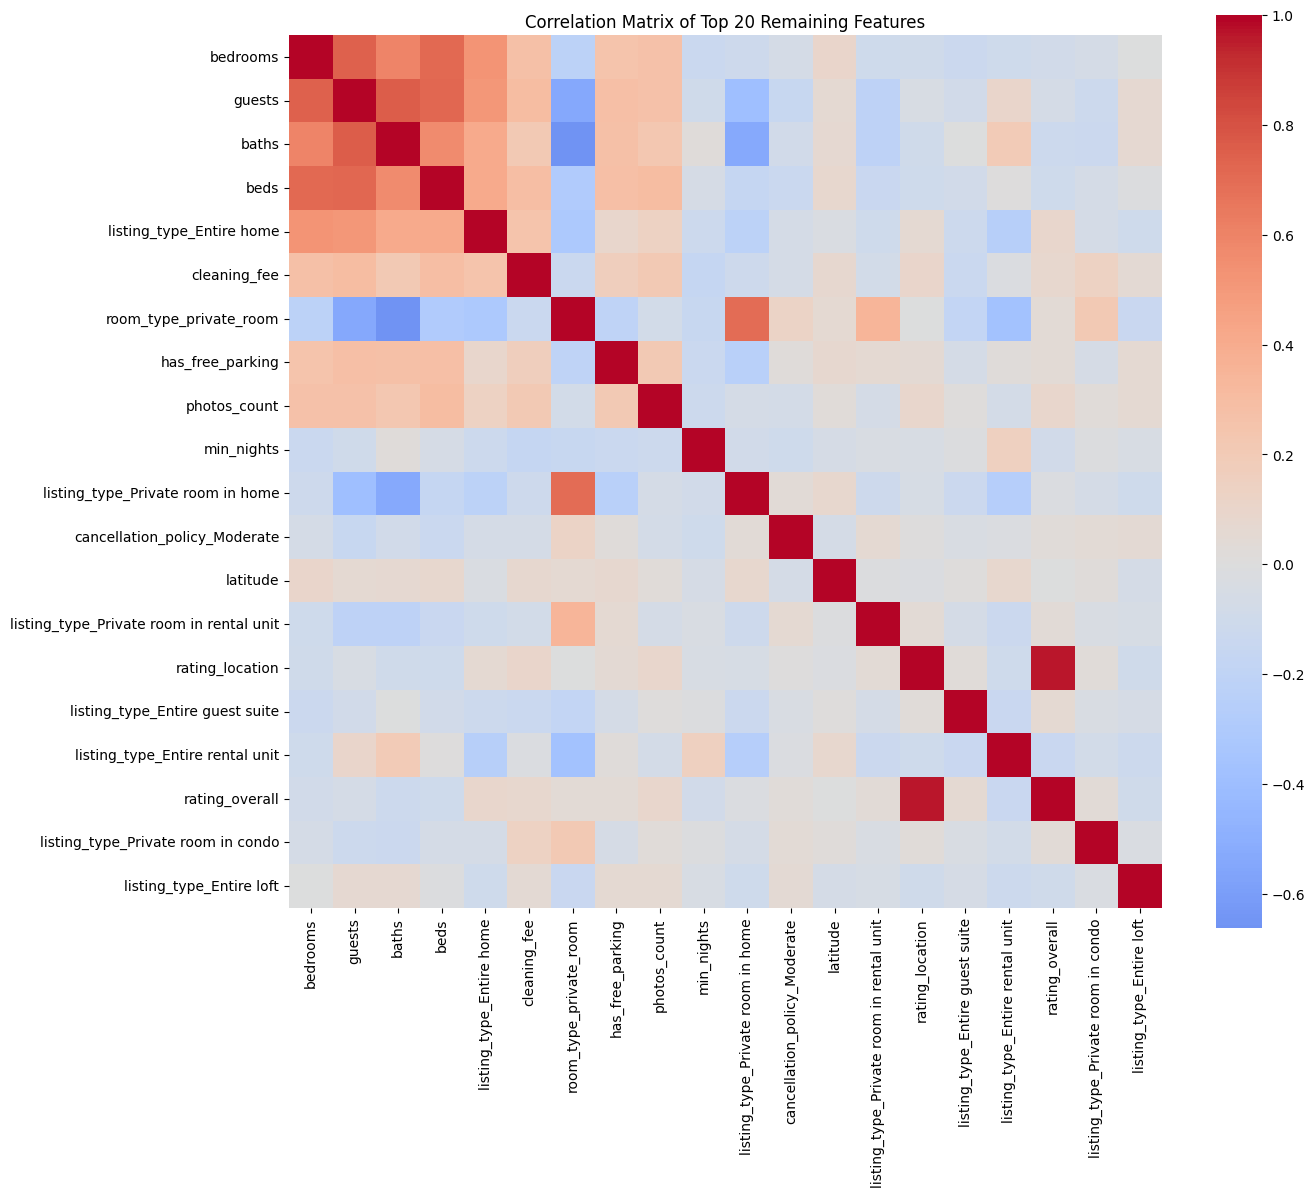

In [934]:
# Correlation matrix for top 20 remaining features
numeric_df = new_df.select_dtypes(include="number").copy()
corr_with_target = numeric_df.corr()["rate_avg"].abs().sort_values(ascending=False)
top_20_features = corr_with_target.drop("rate_avg").head(20).index.tolist()

print("Top 20 remaining features by |correlation| with rate_avg:")
print(top_20_features)

top_corr_matrix = numeric_df[top_20_features].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(top_corr_matrix, cmap="coolwarm", center=0, square=True, annot=False)
plt.title("Correlation Matrix of Top 20 Remaining Features")
plt.tight_layout()
plt.show()

In [935]:
print(new_df.shape)

(3225, 71)


In [936]:
# Export cleaned dataframe to CSV
new_df.to_csv("MSE446_cleaned_dataset_postEDA.csv", index=False)

---
# Linear Regression Model

This file aims to predict the variable 'rate_avg' from the available features using a linear regression model. First, linear regression is performed without any feature selection. This gives us a baseline model we will use later for comparison. Second, ridge regression is performed and the model is evaluated. Finally, lasso regression provides us with a model in which some unimportant features have their coefficient being zeroed out. A comparison table at the end of this file summarizes the obtained results.

The following metrics are used to evaluate the different models:
- MSE: penalizes large errors
- MAE: direct representation of sum of error terms
- MAPE: percentage of true value y, shows 'how far the model is from actual values' <=> average relative error in %
- R^2: fraction of variance explained by the data

Due to the lack of adequate values in the dateset, the data can not be used as time series. Therefore, we chose to consider the points as being completely independent of time. Another choice could be to consider time series based on yearly division. 

### Outline :
The following processes will be applied with different types of feature selection:
1. split data
2. develop and fit the model
3. predict using the model + hyperparameter tuning with 5-fold CV
4. evaluate the model
5. bootstrap to get CI for coeffs and metrics

Types of feature selection to which the processes above will be applied:
- baseline model including all features
- ridge regression
- lasso regression

In [937]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [938]:
the_df=pd.read_csv('MSE446_cleaned_dataset_postEDA.csv')
print(the_df.shape)
the_df.head()

(3225, 71)


,rate_avg,photos_count,superhost,latitude,longitude,guests,bedrooms,beds,baths,min_nights,...,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days,avg_temp
0,36.3,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,-3.925
1,35.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,0.770
2,35.9,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,7.040
3,36.0,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,13.890
4,36.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,19.470


In [939]:
mse_compare=[]
mae_compare=[]
mape_compare=[]
r2_compare=[]

We first start with a baseline model that uses all available features from the dataset. 

## Baseline model

Split the data to define the training and the test set.

In [940]:
from sklearn.model_selection import train_test_split

X = the_df.drop(columns=['rate_avg']) #select all columns except 'rate_avg'
print(X.shape)
y=the_df['rate_avg']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=156)
print('\n'+str(X_train.shape))
print(X_test.shape)
print(y_train.shape)

print(y_test.shape)

(3225, 70)

(2580, 70)
(645, 70)
(2580,)
(645,)


In [941]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [942]:
# Create and fit the model
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [943]:
# Print the parameters of the model
print(lm.intercept_)
#print(lm.coef_)
coef_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print(coef_df.sort_values(by='Coefficient', ascending=False))

127.47945736434153
                          Coefficient
rating_overall             100.957002
bedrooms                    36.173597
listing_type_Entire home    36.029765
baths                       31.287171
rating_location             30.694863
...                               ...
rating_cleanliness          -9.716884
min_nights                 -15.943207
rating_checkin             -29.418175
rating_accuracy            -39.120051
rating_value               -47.655212

[70 rows x 1 columns]


The baseline coefficients are very large (on the order of 10^13), which is a sign of numerical instability due to multicollinearity in the feature set. Using ridge and lasso regression constitutes a possible solution to this problem, since these methods reduce or even zero out some feature coefficients.

Predict with the model and output the following metrics: MAE, MSE, MAPE, R^2. Plot the predicted values vs the true values for 'rate_avg'.

MAE:  40.77948722327634
MSE:  3183.0813629163067
MAPE:  0.42207067720815256
R^2:  0.7074434502789042


Text(0.5, 1.0, 'Residual Plot')

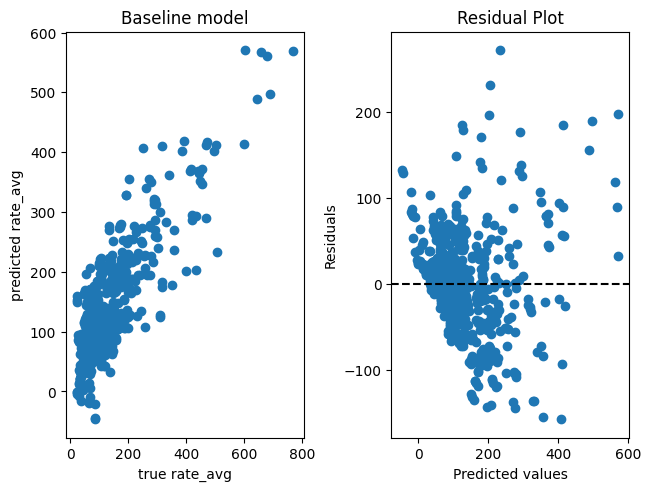

In [944]:
predictions = lm.predict(X_test_scaled)

from sklearn import metrics
print('MAE: ', metrics.mean_absolute_error(y_test, predictions))
print('MSE: ', metrics.mean_squared_error(y_test, predictions))
print('MAPE: ', metrics.mean_absolute_percentage_error(y_test, predictions))

from sklearn.metrics import r2_score

print('R^2: ', r2_score(y_test, predictions))

mae_compare.append(metrics.mean_absolute_error(y_test, predictions))
mse_compare.append(metrics.mean_squared_error(y_test, predictions))
mape_compare.append(metrics.mean_absolute_percentage_error(y_test, predictions))
r2_compare.append(metrics.r2_score(y_test, predictions))

fig, axs=plt.subplots(1, 2, layout="constrained")
axs[0].scatter(y_test, predictions)
axs[0].set_title('Baseline model')
axs[0].set_xlabel('true rate_avg')
axs[0].set_ylabel('predicted rate_avg')

residuals = y_test - predictions
axs[1].scatter(predictions, residuals)
axs[1].axhline(0, linestyle='--', color='black')
axs[1].set_xlabel('Predicted values')
axs[1].set_ylabel('Residuals')
axs[1].set_title('Residual Plot')

As can be seen, this baseline model performs moderately well. The MSE is large, indicating that some points are predicted with a large error. An R^2  value of 0.71 means that only 71% of variance in the predicted data can actually be explained by the model. The large residuals and high MAPE show that the model lacks precision when predicting the target variable.

## Ridge regression

We will now follow the same procedure, but will use this time ridge regression to shrink the coefficients of some features to reduce the impact of multicollinearity. As a reminder, ridge regression keeps all features but tries to stabilize the model. 

In [945]:
#delete same-named variables:
del X, y, X_train, X_test, y_train, y_test, predictions

We start by splitting the data into training and test sets.

In [946]:
from sklearn.model_selection import train_test_split

X = the_df.drop(columns=['rate_avg']) #select all columns except 'rate_avg'
print(X.shape)
y=the_df['rate_avg']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=156)
print('\n'+str(X_train.shape))
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3225, 70)

(2580, 70)
(645, 70)
(2580,)
(645,)


Then, we fit the model and perform hyperparameter tuning (using 5-fold Cross Validation) to find the best alpha value for the ridge regression model:

In [947]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

#scale features, initiate model, use GridSearchCV, search for the best penality alpha between 0.1 and 5
pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
params = {'ridge__alpha': np.linspace(0.1, 5, 100)}
grid_ridge = GridSearchCV(pipe, params, scoring='neg_mean_absolute_error', cv=5)

grid_ridge.fit(X_train, y_train) #fit the function to train set 

# Find the best parameter and see how well it performs on test set
print(grid_ridge.best_params_)
best_scaler = grid_ridge.best_estimator_.named_steps['scaler']
best_alpha=float(grid_ridge.best_params_['ridge__alpha'])
print(grid_ridge.score(X_test, y_test))
#print(grid_ridge.cv_results_['mean_test_score'])

X_train_scaled = best_scaler.transform(X_train)
X_test_scaled  = best_scaler.transform(X_test)

{'ridge__alpha': np.float64(3.366666666666667)}
-40.69112302307125


Now, let's evaluate the model. It uses the optimal alpha (ridge's penality coefficient) found through hyperparameter tuning. 

MAE:  40.69112302307125
MSE:  3180.767225373393
MAPE:  0.41855049905182035
R^2:  0.7076561423272516
Max Error: 272.04582028017694
Median Absolute Error: 28.539683884232545


Text(0.5, 1.0, 'Q-Q Plot of Residuals')

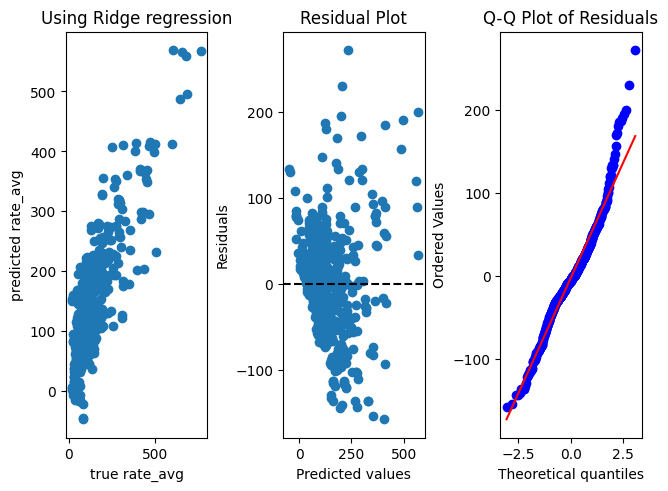

In [948]:
predict = grid_ridge.best_estimator_.predict(X_test)

from sklearn import metrics

print('MAE: ', metrics.mean_absolute_error(y_test, predict))
print('MSE: ', metrics.mean_squared_error(y_test, predict))
print('MAPE: ', metrics.mean_absolute_percentage_error(y_test, predict))
print('R^2: ', metrics.r2_score(y_test, predict))
print('Max Error:', metrics.max_error(y_test, predict))
print('Median Absolute Error:', metrics.median_absolute_error(y_test, predict)) #more robust to outliers than mean

mae_compare.append(metrics.mean_absolute_error(y_test, predict))
mse_compare.append(metrics.mean_squared_error(y_test, predict))
mape_compare.append(metrics.mean_absolute_percentage_error(y_test, predict))
r2_compare.append(metrics.r2_score(y_test, predict))

fig, axs=plt.subplots(1, 3, layout="constrained")
axs[0].scatter(y_test, predict)
axs[0].set_title('Using Ridge regression')
axs[0].set_xlabel('true rate_avg')
axs[0].set_ylabel('predicted rate_avg')

residuals = y_test - predict
axs[1].scatter(predict, residuals)
axs[1].axhline(0, linestyle='--', color='black')
axs[1].set_xlabel('Predicted values')
axs[1].set_ylabel('Residuals')
axs[1].set_title('Residual Plot')

import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axs[2])
axs[2].set_title('Q-Q Plot of Residuals') #values following red line = residuals are normally distributed (=assumption of lin reg)

The first plot shows the predicted vs the true values. The second displays the behavior of the residuals vs the predicted values. Despite using ridge regression, it can be observed that some predicted values have a large error, leading to a high MSE value. The Quantile-Quantile residual plot helps verifying if the residuals follow a normal distribution. It can be seen that this is not exactly the case, meaning that linear regression may not be the best model to predict the values of 'rate_avg'.

Finally, we use bootstrap on the training set to find confidence intervals for the coefficients and the metrics.

In [949]:
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

score_mse = []
score_mae = []
score_mape = []
score_r2 = []
n_iterations = 1000
coef_list = []

for i in range(n_iterations):
    # resample the TRAINING set, keep test set fixed
    X_boot, y_boot = resample(X_train_scaled, y_train, replace=True)
    
    #refit model on each bootstrap sample
    model_boot = Ridge(alpha=best_alpha)
    model_boot.fit(X_boot, y_boot)
    
    #evaluate on FIXED test set
    predict = model_boot.predict(X_test_scaled)
    curr_score_mse = mean_squared_error(y_test, predict)    
    curr_score_mae = mean_absolute_error(y_test, predict) #MAE
    curr_score_mape = mean_absolute_percentage_error(y_test, predict) #MAPE
    curr_score_r2 = r2_score(y_test, predict) #R^2
    score_mse.append(curr_score_mse)
    score_mae.append(curr_score_mae)
    score_mape.append(curr_score_mape)
    score_r2.append(curr_score_r2)
    
    #collect coeffs
    coef_list.append(model_boot.coef_) 
    
coef_array = np.array(coef_list)  #shape:(1000, n_features)
for j, col in enumerate(X.columns):
    lo = np.percentile(coef_array[:, j], 2.5)
    hi = np.percentile(coef_array[:, j], 97.5)
    print(f'{col:30s}: 95% CI [{lo:.3f}, {hi:.3f}]')  #if CI crosses 0 --> unstable feature    
       
median_mse = np.median(score_mse)
lower_mse  = np.percentile(score_mse, 2.5)
upper_mse  = np.percentile(score_mse, 97.5)

median_mae = np.median(score_mae)
lower_mae  = np.percentile(score_mae, 2.5)
upper_mae  = np.percentile(score_mae, 97.5)

median_mape = np.median(score_mape)
lower_mape  = np.percentile(score_mape, 2.5)
upper_mape  = np.percentile(score_mape, 97.5)

median_r2 = np.median(score_r2)
lower_r2  = np.percentile(score_r2, 2.5)
upper_r2  = np.percentile(score_r2, 97.5)

#for coefficients (not for results):
#the further from 0 is the CI, the better
#the smaller the CI, the better
print(f'\nMedian MSE: {median_mse:.2f}, 95% CI: [{lower_mse:.2f}, {upper_mse:.2f}]')
print(f'Median MAE: {median_mae:.2f}, 95% CI: [{lower_mae:.2f}, {upper_mae:.2f}]')
print(f'Median MAPE: {median_mape:.2f}, 95% CI: [{lower_mape:.2f}, {upper_mape:.2f}]')
print(f'Median R^2: {median_r2:.2f}, 95% CI: [{lower_r2:.2f}, {upper_r2:.2f}]')

photos_count                  : 95% CI [-1.876, 5.295]
superhost                     : 95% CI [-5.803, -0.879]
latitude                      : 95% CI [-1.227, 5.750]
longitude                     : 95% CI [2.342, 6.596]
guests                        : 95% CI [7.745, 21.845]
bedrooms                      : 95% CI [29.723, 44.601]
beds                          : 95% CI [-0.449, 8.541]
baths                         : 95% CI [23.308, 39.903]
min_nights                    : 95% CI [-18.778, -13.305]
cleaning_fee                  : 95% CI [7.521, 13.638]
extra_guest_fee               : 95% CI [-2.434, 0.952]
num_reviews                   : 95% CI [6.562, 11.169]
rating_overall                : 95% CI [64.318, 102.124]
rating_accuracy               : 95% CI [-46.426, -14.936]
rating_checkin                : 95% CI [-42.995, -10.327]
rating_cleanliness            : 95% CI [-16.642, 4.539]
rating_communication          : 95% CI [-10.042, 23.312]
rating_location               : 95% CI [21.275, 3

Text(0.5, 1.0, 'R^2')

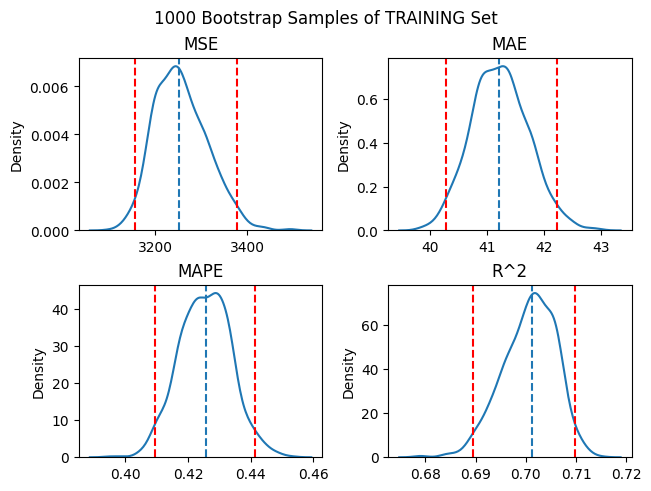

In [950]:
fig, axs = plt.subplots(2, 2, layout="constrained")
fig.suptitle('1000 Bootstrap Samples of TRAINING Set')
#MSE
sns.kdeplot(score_mse, ax=axs[0, 0])
axs[0, 0].axvline(median_mse, linestyle="--")
axs[0, 0].axvline(lower_mse, linestyle="--", color="red")
axs[0, 0].axvline(upper_mse, linestyle="--", color="red")
axs[0, 0].set_title('MSE')
#MAE
sns.kdeplot(score_mae, ax=axs[0, 1])
axs[0, 1].axvline(median_mae, linestyle="--")
axs[0, 1].axvline(lower_mae, linestyle="--", color="red")
axs[0, 1].axvline(upper_mae, linestyle="--", color="red")
axs[0, 1].set_title('MAE')
#MAPE
sns.kdeplot(score_mape, ax=axs[1, 0])
axs[1, 0].axvline(median_mape, linestyle="--")
axs[1, 0].axvline(lower_mape, linestyle="--", color="red")
axs[1, 0].axvline(upper_mape, linestyle="--", color="red")
axs[1, 0].set_title('MAPE')
#R^2
sns.kdeplot(score_r2, ax=axs[1, 1])
axs[1, 1].axvline(median_r2, linestyle="--")
axs[1, 1].axvline(lower_r2, linestyle="--", color="red")
axs[1, 1].axvline(upper_r2, linestyle="--", color="red")
axs[1, 1].set_title('R^2')

Text(0.5, 1.0, 'Coefficient estimates with 95% CI')

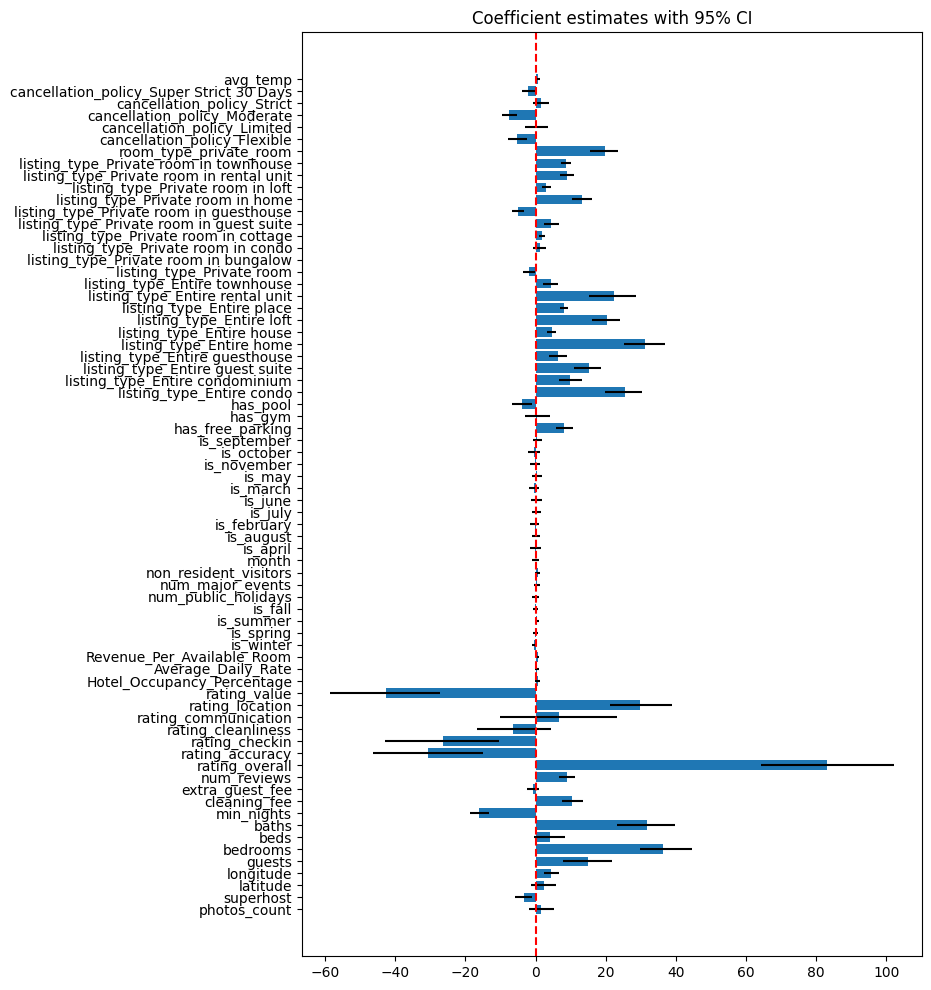

In [951]:
#coeff plot --> visualize bootstrap coefficient CIs
coef_array=np.array(coef_list)
means = coef_array.mean(axis=0)
lows  = np.percentile(coef_array,2.5,  axis=0)
highs = np.percentile(coef_array, 97.5, axis=0)

plt.figure(figsize=(8, 12))
plt.barh(X.columns, means, xerr=[means-lows, highs-means])
plt.axvline(0, linestyle='--', color='red')
plt.title('Coefficient estimates with 95% CI')
#features whose CI crosses 0 = unstable/unreliable

The CV learning curves display, for the training set error and the validation set error, the MAE vs the amount of training data that the training set is allowed to see. As can be seen, a small training set seems to lead to overfitting, but this problem is solved as the size of the training set increases. 

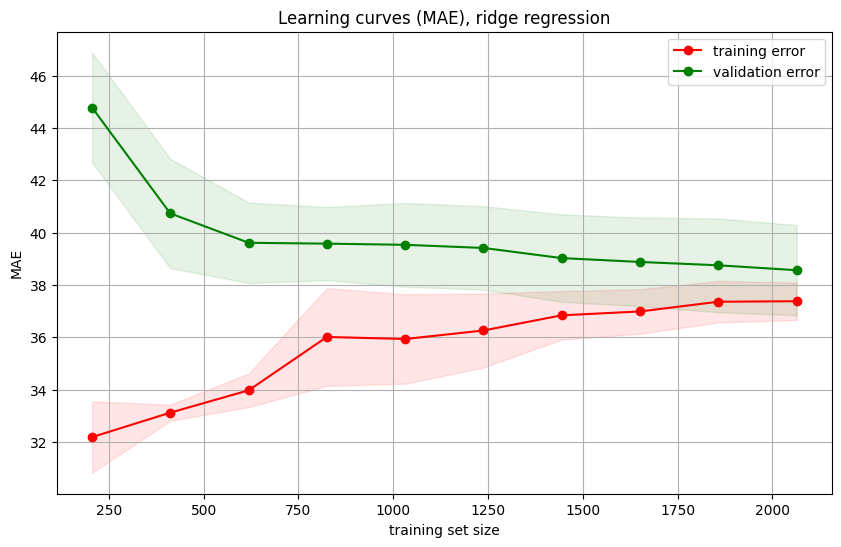

In [952]:
#CV learning curves: whether underfitting or overfitting + if more data would help
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipe, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_absolute_error', cv=5
)
train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)

train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))

plt.plot(train_sizes, train_errors, 'o-', color="r", label="training error")
plt.plot(train_sizes, val_errors, 'o-', color="g", label="validation error")

plt.fill_between(train_sizes, train_errors - train_std, train_errors + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, val_errors - val_std, val_errors + val_std, alpha=0.1, color="g")

plt.title("Learning curves (MAE), ridge regression")
plt.xlabel("training set size")
plt.ylabel("MAE")
plt.legend(loc="best")
plt.grid(True)
plt.show()

## Lasso regression

We will now follow the same procedure, but will use this time lasso regression to zero out the coefficients of the least important features. Lasso automatically picks one feature from a correlated pair and zeroes out the other.

In [953]:
#delete same-named variables:
del X_train, X_test, y_train, y_test, coef_list, predict, coef_array

We start with the usual train-test split.

In [954]:
from sklearn.model_selection import train_test_split
 
X = the_df.drop(columns=['rate_avg']) #select all columns except 'rate_avg'
print(X.shape)
y = the_df['rate_avg']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156)
print('\n'+str(X_train.shape))
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3225, 70)

(2580, 70)
(645, 70)
(2580,)
(645,)


Then, we perform hyperparameter tuning to find the best alpha (penalty coefficient of lasso regression model) by using 5-fold Cross Validation. These lines are relatively time consuming when searching over a broad range of values, so the results of former executions are commented below. An appropriate value for alpha was iteratively searched (starting with [0.01, 1.0]) to obtain the narrow interval that allows to get a precise value as shown below. 

In [955]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso 
from sklearn.model_selection import GridSearchCV
 
# Scale features, initiate model, use GridSearchCV, search for the best penalty alpha
pipe = Pipeline([('scaler', StandardScaler()), ('lasso', Lasso(max_iter=100000))])  
params = {'lasso__alpha': np.linspace(0.035, 0.036, 10)}

# Possible regression metrics to use:
# neg_mean_squared_error (MSE)
# neg_mean_absolute_error (MAE)
# r2 (R-squared)
grid_lasso = GridSearchCV(pipe, params, scoring='neg_mean_absolute_error', cv=5)
grid_lasso.fit(X_train, y_train)
 
# Find the best parameter and see how well it performs on test set
print(grid_lasso.best_params_)
best_scaler = grid_lasso.best_estimator_.named_steps['scaler']
best_alpha = float(grid_lasso.best_params_['lasso__alpha'])
print(grid_lasso.score(X_test, y_test))
 
X_train_scaled = best_scaler.transform(X_train)
X_test_scaled  = best_scaler.transform(X_test)

#results of former executions:
#{'lasso__alpha': 0.046415888336127774}
#-40.75628578796824
#{'lasso__alpha': 0.035}
#-40.74154014859792
#{'lasso__alpha': 0.035555555555555556}
#-40.741929929187094
#{'lasso__alpha': 0.035666666666666666}

{'lasso__alpha': np.float64(0.035)}
-40.7018223425363


Using the obtained alpha, the model can now predict the values for 'rate_avg'. The resulting metrics, as well as the features whose coefficient was put to zero by lasso regression are displayed below. 

MAE:  40.7018223425363
MSE:  3181.3867486852555
MAPE:  0.419229452476883
R^2:  0.707599202028866
Max Error: 271.9717079856923
Median Absolute Error: 27.91790380086482

Features put to 0 by Lasso (14): ['Hotel_Occupancy_Percentage', 'Revenue_Per_Available_Room', 'is_winter', 'is_spring', 'is_summer', 'is_fall', 'num_public_holidays', 'non_resident_visitors', 'is_august', 'is_february', 'is_july', 'is_november', 'listing_type_Private room in bungalow', 'listing_type_Private room in home']


Text(0.5, 1.0, 'Q-Q Plot of Residuals')

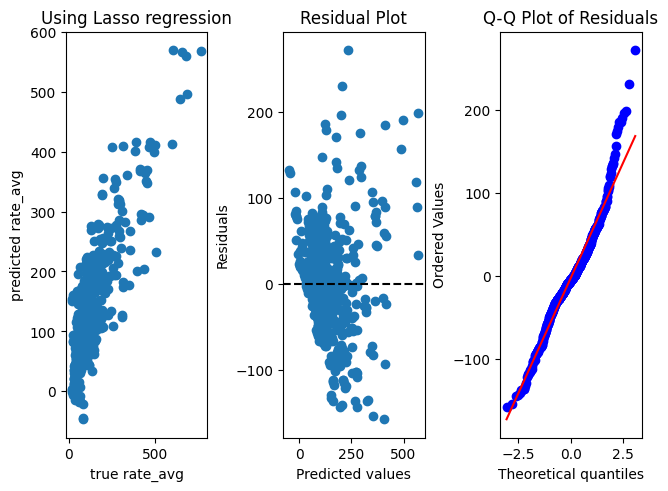

In [956]:
predict = grid_lasso.best_estimator_.predict(X_test)

from sklearn import metrics
 
print('MAE: ', metrics.mean_absolute_error(y_test, predict))
print('MSE: ', metrics.mean_squared_error(y_test, predict))
print('MAPE: ', metrics.mean_absolute_percentage_error(y_test, predict))
print('R^2: ', metrics.r2_score(y_test, predict))
print('Max Error:', metrics.max_error(y_test, predict))
print('Median Absolute Error:', metrics.median_absolute_error(y_test, predict))

mae_compare.append(metrics.mean_absolute_error(y_test, predict))
mse_compare.append(metrics.mean_squared_error(y_test, predict))
mape_compare.append(metrics.mean_absolute_percentage_error(y_test, predict))
r2_compare.append(metrics.r2_score(y_test, predict))

#show features that were put to 0 by lasso
lasso_coefs = grid_lasso.best_estimator_.named_steps['lasso'].coef_
zeroed = [col for col, coef in zip(X.columns, lasso_coefs) if coef == 0]
print(f'\nFeatures put to 0 by Lasso ({len(zeroed)}): {zeroed}')
 
fig, axs = plt.subplots(1, 3, layout="constrained")
axs[0].scatter(y_test, predict)
axs[0].set_title('Using Lasso regression')
axs[0].set_xlabel('true rate_avg')
axs[0].set_ylabel('predicted rate_avg')
 
residuals = y_test - predict
axs[1].scatter(predict, residuals)
axs[1].axhline(0, linestyle='--', color='black')
axs[1].set_xlabel('Predicted values')
axs[1].set_ylabel('Residuals')
axs[1].set_title('Residual Plot')
 
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axs[2])
axs[2].set_title('Q-Q Plot of Residuals')

Similar to the case of ridge regression, we can observe that large error persist between the predicted and true values (high residuals). The Q-Q also indicated that the residuals are not following a perfect normal distribution. Lasso regression lead to 17 features being zeroed out without noticeable performance improvement. 

We use bootstrap on the training set to find confidence intervals for the coefficients and the metrics.

In [957]:
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
 
score_mse  = []
score_mae  = []
score_mape = []
score_r2   = []
n_iterations = 1000
coef_list = []
 
for i in range(n_iterations):
    #resample the TRAINING set, keep test set fixed
    X_boot, y_boot = resample(X_train_scaled, y_train, replace=True)
 
    #refit model on each bootstrap sample
    model_boot = Lasso(alpha=best_alpha, max_iter=10000)
    model_boot.fit(X_boot, y_boot)
 
    #evaluate on FIXED test set
    predict_boot = model_boot.predict(X_test_scaled)
    score_mse.append(mean_squared_error(y_test, predict_boot))
    score_mae.append(mean_absolute_error(y_test, predict_boot))
    score_mape.append(mean_absolute_percentage_error(y_test, predict_boot))
    score_r2.append(r2_score(y_test, predict_boot))
 
    #collect coefficients
    coef_list.append(model_boot.coef_)
 
coef_array = np.array(coef_list)  #shape:(1000,n_features)
for j, col in enumerate(X.columns):
    lo = np.percentile(coef_array[:, j], 2.5)
    hi = np.percentile(coef_array[:, j], 97.5)
    print(f'{col:30s}: 95% CI [{lo:.3f}, {hi:.3f}]')  # if CI crosses 0 --> unstable feature
 
median_mse = np.median(score_mse)
lower_mse  = np.percentile(score_mse, 2.5)
upper_mse  = np.percentile(score_mse, 97.5)
 
median_mae = np.median(score_mae)
lower_mae  = np.percentile(score_mae, 2.5)
upper_mae  = np.percentile(score_mae, 97.5)
 
median_mape = np.median(score_mape)
lower_mape  = np.percentile(score_mape, 2.5)
upper_mape  = np.percentile(score_mape, 97.5)
 
median_r2 = np.median(score_r2)
lower_r2  = np.percentile(score_r2, 2.5)
upper_r2  = np.percentile(score_r2, 97.5)
 
#for coefficients (not for results):
#the further from 0 the CI, the better
#the smaller the CI, the better
print(f'\nMedian MSE:  {median_mse:.2f},  95% CI: [{lower_mse:.2f},  {upper_mse:.2f}]')
print(f'Median MAE:  {median_mae:.2f},  95% CI: [{lower_mae:.2f},  {upper_mae:.2f}]')
print(f'Median MAPE: {median_mape:.2f}, 95% CI: [{lower_mape:.2f}, {upper_mape:.2f}]')
print(f'Median R^2:  {median_r2:.2f},  95% CI: [{lower_r2:.2f},  {upper_r2:.2f}]')

photos_count                  : 95% CI [-1.601, 5.171]
superhost                     : 95% CI [-5.950, -0.847]
latitude                      : 95% CI [-1.125, 5.698]
longitude                     : 95% CI [2.224, 6.539]
guests                        : 95% CI [8.176, 22.295]
bedrooms                      : 95% CI [29.393, 44.277]
beds                          : 95% CI [-0.001, 8.659]
baths                         : 95% CI [23.608, 39.557]
min_nights                    : 95% CI [-18.803, -13.213]
cleaning_fee                  : 95% CI [7.419, 13.494]
extra_guest_fee               : 95% CI [-2.276, 0.754]
num_reviews                   : 95% CI [6.530, 11.264]
rating_overall                : 95% CI [69.918, 116.017]
rating_accuracy               : 95% CI [-50.832, -16.830]
rating_checkin                : 95% CI [-44.660, -10.747]
rating_cleanliness            : 95% CI [-19.752, 1.171]
rating_communication          : 95% CI [-7.691, 21.132]
rating_location               : 95% CI [21.307, 38

Text(0.5, 1.0, 'R^2')

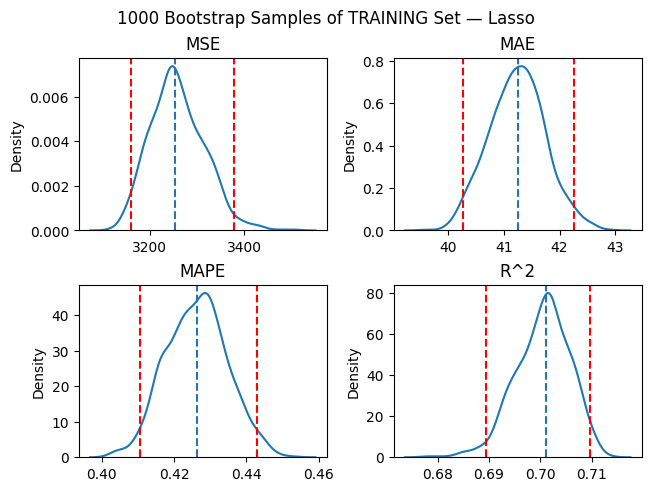

In [958]:
fig, axs = plt.subplots(2, 2, layout="constrained")
fig.suptitle('1000 Bootstrap Samples of TRAINING Set — Lasso')
# MSE
sns.kdeplot(score_mse, ax=axs[0, 0])
axs[0, 0].axvline(median_mse, linestyle="--")
axs[0, 0].axvline(lower_mse,  linestyle="--", color="red")
axs[0, 0].axvline(upper_mse,  linestyle="--", color="red")
axs[0, 0].set_title('MSE')
# MAE
sns.kdeplot(score_mae, ax=axs[0, 1])
axs[0, 1].axvline(median_mae, linestyle="--")
axs[0, 1].axvline(lower_mae,  linestyle="--", color="red")
axs[0, 1].axvline(upper_mae,  linestyle="--", color="red")
axs[0, 1].set_title('MAE')
# MAPE
sns.kdeplot(score_mape, ax=axs[1, 0])
axs[1, 0].axvline(median_mape, linestyle="--")
axs[1, 0].axvline(lower_mape,  linestyle="--", color="red")
axs[1, 0].axvline(upper_mape,  linestyle="--", color="red")
axs[1, 0].set_title('MAPE')
# R^2
sns.kdeplot(score_r2, ax=axs[1, 1])
axs[1, 1].axvline(median_r2, linestyle="--")
axs[1, 1].axvline(lower_r2,  linestyle="--", color="red")
axs[1, 1].axvline(upper_r2,  linestyle="--", color="red")
axs[1, 1].set_title('R^2')

Text(0.5, 1.0, 'Coefficient estimates with 95% CI')

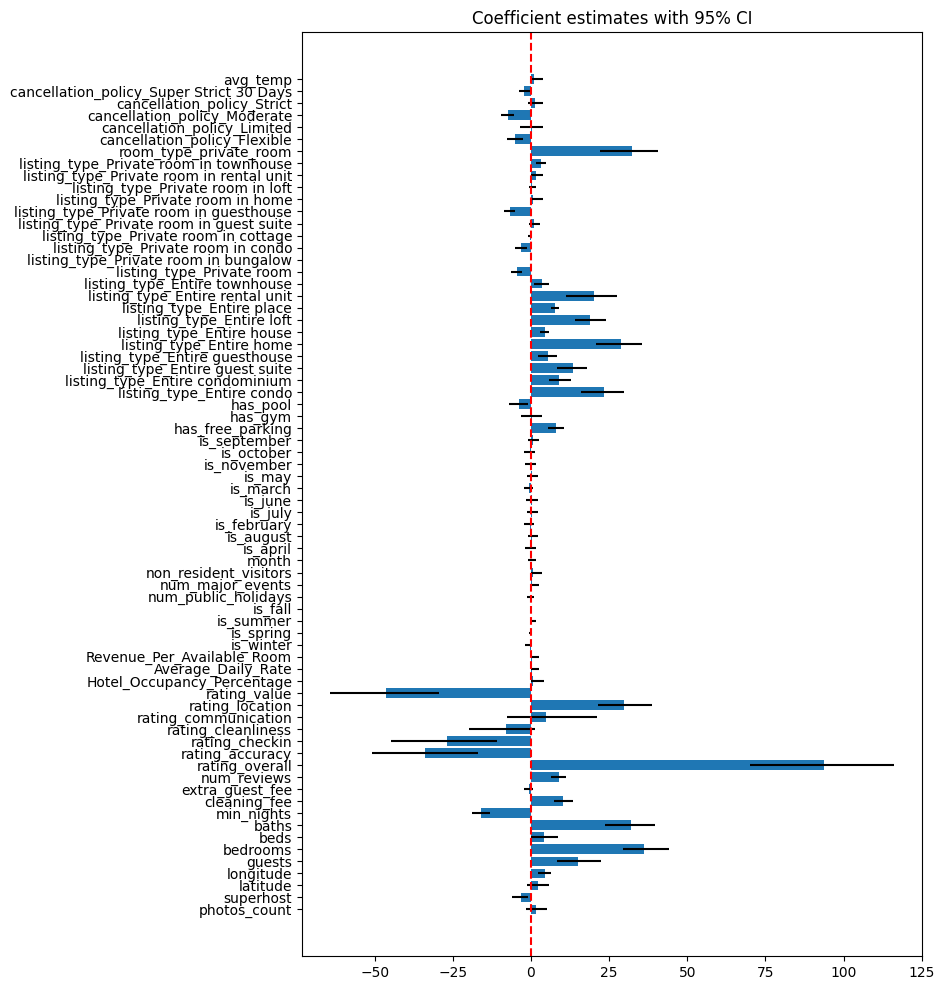

In [959]:
#coeff plot --> visualize bootstrap coefficient CIs
coef_array=np.array(coef_list)
means = coef_array.mean(axis=0)
lows  = np.percentile(coef_array,2.5,  axis=0)
highs = np.percentile(coef_array, 97.5, axis=0)

plt.figure(figsize=(8, 12))
plt.barh(X.columns, means, xerr=[np.abs(means-lows), np.abs(highs-means)])
plt.axvline(0, linestyle='--', color='red')
plt.title('Coefficient estimates with 95% CI')
#features whose CI crosses 0 = unstable/unreliable

Again, we display the CV learning curve showing the training set error and validation set error as a function of the training set size. 

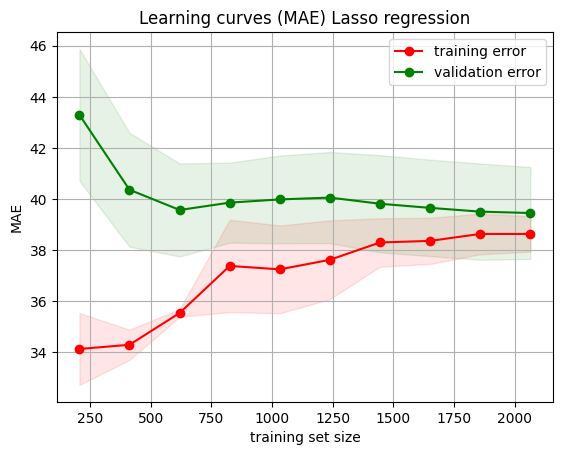

In [960]:
#CV learning curves: whether underfitting or overfitting + if more data would help
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(pipe, X_train, y_train,train_sizes=np.linspace(0.1, 1.0, 10),scoring='neg_mean_absolute_error', cv=5)
train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)

train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure()
plt.plot(train_sizes, train_errors, 'o-', color="r", label="training error")
plt.plot(train_sizes, val_errors, 'o-', color="g", label="validation error")
plt.fill_between(train_sizes, train_errors - train_std, train_errors + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, val_errors - val_std, val_errors + val_std, alpha=0.1, color="g")
plt.title("Learning curves (MAE) Lasso regression")
plt.xlabel("training set size")
plt.ylabel("MAE")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [961]:
#compare the results side-by-side
results = {
    'Category':  ['Baseline', 'Ridge', 'Lasso'],   
    'MAE':       mae_compare,
    'MSE':       mse_compare,
    'MAPE':      mape_compare,
    'R^2':       r2_compare
}
df = pd.DataFrame(results).set_index('Category').T
df

Category,Baseline,Ridge,Lasso
MAE,40.779487,40.691123,40.701822
MSE,3183.081363,3180.767225,3181.386749
MAPE,0.422071,0.418550,0.419229
R^2,0.707443,0.707656,0.707599


This table summarizes the results obtained using linear regression models with no feature selection, ridge regression and lasso regression. It can be observed that there is no particular improvement between the ridge/lasso models and the baseline model, even though the former should have stabilized the model, helping to tackle multicollinearity issues. Furthermore, the MAPE (~43%) means that the average prediction error lies at around 43% for all three models. This indicates that neither shrinking nor zeroing out feature coefficients has an impact on the prediction correctness. The lasso regression model zeroed out 17 features but no performance improvement was recorded. We can therefore deduce that the poor predicting performance are not due to issues with the data available, but rather due to the model used: linear regression seems to be inappropriate for this dataset. In fact, ridge and lasso regression can change the coefficients, allowing to reduce the importance of redundant features, but can not fix a model that is unsuitable for the data. R^2 plateaus at ~0.71, MAPE stays around  ~43% and the residuals don't follow a normal distribution (as can be seen on the Q-Q curves). The main source of error is bias, since the model is not flexible enough to capture the variations in the data. 

In other notebooks, we will explore different methods for predicting 'rate_avg'.

---
# KNN Models


- **Section 1:**  KNN workflow using Lasso-based feature selection and comparison models
- **Section 2:**  KNN workflow using a manually shortened feature list (60 selected features)
- **Section 3:** Final comparison and recommendation

These models apply **K-Nearest Neighbors (KNN) regression** to predict **average Airbnb price**.  
KNN is a distance-based supervised learning method that predicts a numeric value by averaging the target values of the **most similar observations** in the training set.

KNN is appropriate for this project because Airbnb pricing is naturally **similarity-based**. If two listings are similar in terms of location, amenities, host characteristics, room type, availability, and review patterns, then their prices are also likely to be similar. This makes KNN a reasonable model for predicting listing price.

## Section 1: Lasso & Scaled KNN Approach

The section below presents the original Lasso-based KNN workflow:

## KNN Models

##### Model 1: No Scaling (69 features)
- Basic Train/Test  
- Cross Validation  

##### Model 2: Scaled Features (69 features)
- Basic Train/Test  
- Cross Validation  

##### Model 3: Lasso (α = 1.0)
- Basic Train/Test (**31 features removed**)  
- Cross Validation (**31 features removed**)  

##### Model 4: Lasso (α = 0.035)
- Basic Train/Test (**17 features removed**)  
- Cross Validation (**17 features removed**)  

### Why Lasso was used in Models 3 and 4

Lasso was used in Models 3 and 4 as a practical **feature reduction method** to improve KNN performance. Since KNN is a **distance-based model**, it can perform poorly when too many weak or irrelevant features are included, especially in higher-dimensional datasets.

Although Lasso is based on a **linear modeling method**, and KNN is a **distance-based method**, Lasso still provides a useful and data-driven way to remove less important predictors. This made it a more reliable feature selection approach than relying only on manual choices or arbitrary cutoffs.

As shown later in the results, using Lasso-based feature selection led to a **substantial reduction in prediction error**, particularly in MSE. This suggests that even though Lasso and KNN are based on different modeling methods, Lasso was still effective as a data engineering step for improving KNN performance.

### Why 5-fold cross-validation was used

For all cross-validation models, **5-fold cross-validation** was used to keep the evaluation process consistent across all model versions.

Since the main comparison in this section focuses on how **scaling and feature selection** affect KNN performance, keeping the number of folds constant helps isolate those differences more clearly. 5-fold cross-validation provides a strong and commonly used balance between **computational efficiency** and **reliable performance estimation**.

Loading in imports: 

In [962]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

df = pd.read_csv('MSE446_cleaned_dataset_postEDA.csv')
df.head() 



,rate_avg,photos_count,superhost,latitude,longitude,guests,bedrooms,beds,baths,min_nights,...,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days,avg_temp
0,36.3,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,-3.925
1,35.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,0.770
2,35.9,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,7.040
3,36.0,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,13.890
4,36.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,19.470


In [963]:
X = df.drop('rate_avg', axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
neighbors_settings = [3, 4, 5, 7, 9, 11]

(2580, 70) (645, 70) (2580,) (645,)


### Model 1: No Scaling (Basic Train Test)

In [964]:
records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))                   
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) 

    records.append((n_neighbors, round(r2, 4), round(mse, 2), round(rmse, 4),round(mae, 2), round(mape, 2)))
    preds[n_neighbors] = y_pred

results_df = pd.DataFrame(records, columns=["k", "R²", "MSE", "RMSE","MAE", "MAPE"]).set_index("k")
print(f"\nModel 1 — All Features, No Scaling")
print(f"\n{'k':<6} {'R²':<10} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'MAPE':<10}")                    
print("-" * 58)                                                                                          
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['R²']:<10} {row['MSE']:<12} {row['RMSE']:<10} {row['MAE']:<10} {row['MAPE']:<10}")



Model 1 — All Features, No Scaling

k      R²         MSE          RMSE       MAE        MAPE      
----------------------------------------------------------
3      0.1931     8586.55      92.6637    58.49      0.53      
4      0.2166     8336.59      91.3049    58.15      0.53      
5      0.2214     8285.36      91.024     58.48      0.53      
7      0.2228     8270.31      90.9413    57.12      0.52      
9      0.2485     7997.05      89.4262    55.99      0.52      
11     0.248      8002.07      89.4543    55.91      0.52      


### Model 1: No Scaling (Cross Validation)


Model 1 — All Features, No Scaling CV

k      CV R²      CV MSE       CV RMSE      CV MAE       CV MAPE   
--------------------------------------------------------------
3      0.2699     8615.17      92.818       58.25        0.5365    
4      0.2702     8618.14      92.8339      57.94        0.5373    
5      0.252      8830.37      93.9701      58.04        0.5428    
7      0.2252     9150.31      95.6573      58.28        0.5486    
9      0.2326     9066.53      95.2183      57.62        0.5397    
11     0.2257     9146.01      95.6348      57.72        0.5403    


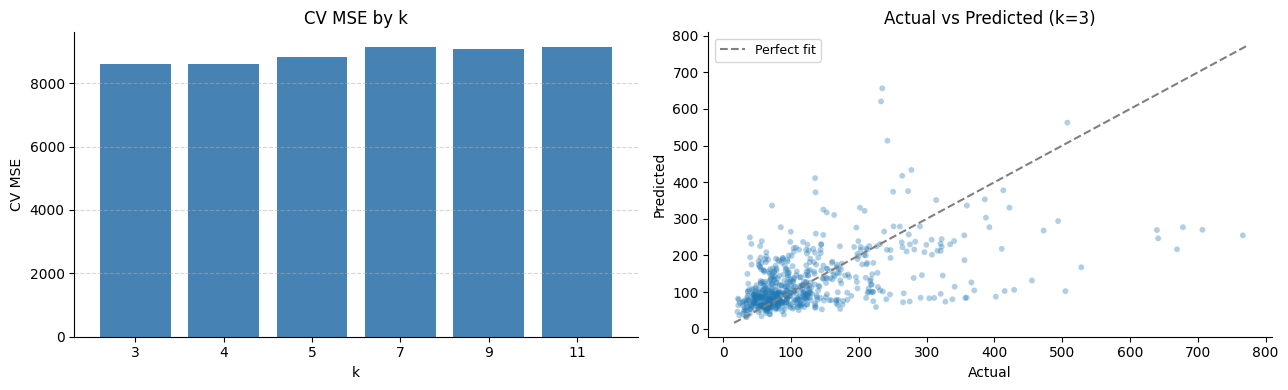

In [965]:
records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    cv_results = cross_validate(knn, X_train, y_train, cv=5, scoring={
        'mse':  'neg_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'mape': 'neg_mean_absolute_percentage_error',
        'r2':   'r2'
    })
    cv_mse  = -cv_results['test_mse'].mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mae  = -cv_results['test_mae'].mean()
    cv_mape = -cv_results['test_mape'].mean()
    cv_r2   = cv_results['test_r2'].mean()

    records.append((n_neighbors, round(cv_r2, 4), round(cv_mse, 2), round(cv_rmse, 4), round(cv_mae, 2), round(cv_mape, 4)))
    preds[n_neighbors] = knn.fit(X_train, y_train).predict(X_test)

results_df = pd.DataFrame(records, columns=["k", "CV R²", "CV MSE", "CV RMSE", "CV MAE", "CV MAPE"]).set_index("k")
print(f"\nModel 1 — All Features, No Scaling CV")
print(f"\n{'k':<6} {'CV R²':<10} {'CV MSE':<12} {'CV RMSE':<12} {'CV MAE':<12} {'CV MAPE':<10}")
print("-" * 62)
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['CV R²']:<10} {row['CV MSE']:<12} {row['CV RMSE']:<12} {row['CV MAE']:<12} {row['CV MAPE']:<10}")

best_k = results_df["CV MSE"].idxmin()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([str(k) for k in results_df.index], results_df["CV MSE"], color="steelblue")
ax1.set_xlabel("k"); ax1.set_ylabel("CV MSE"); ax1.set_title("CV MSE by k")
ax1.grid(axis="y", linestyle="--", alpha=0.5); sns.despine(ax=ax1)
lims = [y_test.min() - 5, y_test.max() + 5]
ax2.plot(lims, lims, "--", color="gray", lw=1.5, label="Perfect fit")
ax2.scatter(y_test, preds[best_k], alpha=0.35, s=18, edgecolors="none")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Actual vs Predicted (k={best_k})"); ax2.legend(fontsize=9)
sns.despine(ax=ax2); plt.tight_layout(); plt.show()

### Model 2: Scaled Features (Basic Train Test)

In [966]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))                        
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) 

    records.append((n_neighbors, round(r2, 4), round(mse, 2), round(rmse, 4), round(mae, 2), round(mape, 2)))
    preds[n_neighbors] = y_pred

results_df = pd.DataFrame(records, columns=["k", "R²", "MSE", "RMSE","MAE", "MAPE"]).set_index("k")
print(f"\nModel 2 — All Features, Scaled")
print(f"\n{'k':<6} {'R²':<10} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'MAPE':<10}")                    
print("-" * 58)                                                                                          
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['R²']:<10} {row['MSE']:<12} {row['RMSE']:<10} {row['MAE']:<10} {row['MAPE']:<10}")


Model 2 — All Features, Scaled

k      R²         MSE          RMSE       MAE        MAPE      
----------------------------------------------------------
3      0.6147     4099.7       64.0289    41.98      0.38      
4      0.6882     3318.35      57.6051    38.77      0.36      
5      0.6986     3207.04      56.6307    37.99      0.35      
7      0.7144     3039.31      55.13      37.28      0.34      
9      0.7194     2985.88      54.6432    36.88      0.34      
11     0.7343     2827.11      53.1706    36.33      0.34      


### Model 2: Scaled Features (Cross Validation)


Model 2 CV — All Features, With Scaling

k      CV R²      CV MSE       CV RMSE      CV MAE       CV MAPE   
--------------------------------------------------------------
3      0.664      3967.87      62.991       41.22        0.3749    
4      0.6904     3657.6       60.4781      39.9         0.3667    
5      0.7019     3521.01      59.3381      38.91        0.3593    
7      0.7093     3435.57      58.6137      38.47        0.3562    
9      0.7191     3323.28      57.6479      38.11        0.355     
11     0.7172     3343.44      57.8225      38.53        0.3579    


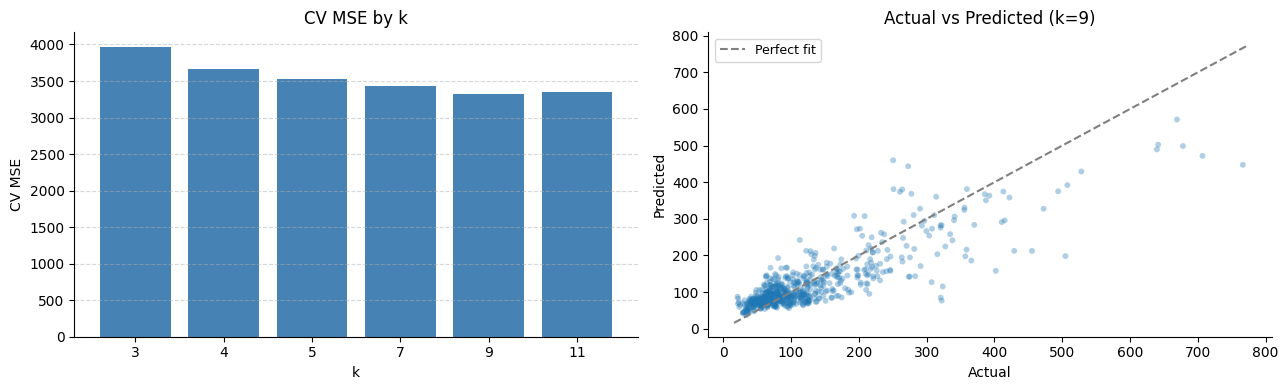

In [967]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    cv_results = cross_validate(knn, X_train_scaled, y_train, cv=5, scoring={
        'r2':   'r2',
        'mse':  'neg_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'mape': 'neg_mean_absolute_percentage_error'
    })
    cv_r2   =  cv_results['test_r2'].mean()
    cv_mse  = -cv_results['test_mse'].mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mae  = -cv_results['test_mae'].mean()
    cv_mape = -cv_results['test_mape'].mean()

    records.append((n_neighbors, round(cv_r2, 4), round(cv_mse, 2), round(cv_rmse, 4), round(cv_mae, 2), round(cv_mape, 4)))
    preds[n_neighbors] = knn.fit(X_train_scaled, y_train).predict(X_test_scaled)

results_df = pd.DataFrame(records, columns=["k", "CV R²", "CV MSE", "CV RMSE", "CV MAE", "CV MAPE"]).set_index("k")
print(f"\nModel 2 CV — All Features, With Scaling")
print(f"\n{'k':<6} {'CV R²':<10} {'CV MSE':<12} {'CV RMSE':<12} {'CV MAE':<12} {'CV MAPE':<10}")
print("-" * 62)
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['CV R²']:<10} {row['CV MSE']:<12} {row['CV RMSE']:<12} {row['CV MAE']:<12} {row['CV MAPE']:<10}")

best_k = results_df["CV MSE"].idxmin()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([str(k) for k in results_df.index], results_df["CV MSE"], color="steelblue")
ax1.set_xlabel("k"); ax1.set_ylabel("CV MSE"); ax1.set_title("CV MSE by k")
ax1.grid(axis="y", linestyle="--", alpha=0.5); sns.despine(ax=ax1)
lims = [y_test.min() - 5, y_test.max() + 5]
ax2.plot(lims, lims, "--", color="gray", lw=1.5, label="Perfect fit")
ax2.scatter(y_test, preds[best_k], alpha=0.35, s=18, edgecolors="none")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Actual vs Predicted (k={best_k})"); ax2.legend(fontsize=9)
sns.despine(ax=ax2); plt.tight_layout(); plt.show()

### Model 3: Lasso (α = 1.0) (Basic Train Test)

Below is the initial calculation to retrieve the features to remove and fine tune the KNN model with Lasso when alpha = 1. 

In [968]:
# Scaling features ( Since Lasso penalizes coefficients, features must be on same scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
# Building and training the model
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)
 
# Making predictions on the test set
y_pred = lasso.predict(X_test_scaled)
 
# Identify which features were zeroed out by Lasso
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': lasso.coef_})
 
zeroed_features = coef_df[coef_df['coefficient'] == 0]
kept_features = coef_df[coef_df['coefficient'] != 0]
 
print(f"\nTotal features: {len(X.columns)}")
print(f"Features zeroed out by Lasso: {len(zeroed_features)}")
print(f"Features kept by Lasso: {len(kept_features)}")
 
print(f"\nZeroed out features:")
print(zeroed_features['feature'].tolist())



Total features: 70
Features zeroed out by Lasso: 30
Features kept by Lasso: 40

Zeroed out features:
['rating_overall', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_value', 'Hotel_Occupancy_Percentage', 'Average_Daily_Rate', 'Revenue_Per_Available_Room', 'is_winter', 'is_spring', 'is_fall', 'num_public_holidays', 'num_major_events', 'month', 'is_april', 'is_august', 'is_february', 'is_july', 'is_june', 'is_may', 'is_november', 'is_october', 'has_gym', 'listing_type_Entire house', 'listing_type_Private room in bungalow', 'listing_type_Private room in cottage', 'listing_type_Private room in home', 'listing_type_Private room in loft', 'room_type_private_room']


The features found above are now going to be removed from the initial data set, and tested below for both basic train test as well as cross validation.

In [969]:

X = df.drop(['rate_avg', 'rating_overall', 'rating_accuracy', 'rating_checkin',
             'rating_cleanliness', 'rating_communication', 'rating_value',
             'Hotel_Occupancy_Percentage', 'Average_Daily_Rate', 'Revenue_Per_Available_Room',
             'is_winter', 'is_spring', 'is_fall', 'num_public_holidays', 'num_major_events',
             'month', 'is_april', 'is_august', 'is_february', 'is_july', 'is_june', 'is_may',
             'is_november', 'is_october', 'has_gym', 'listing_type_Entire house',
             'listing_type_Private room in bungalow', 'listing_type_Private room in cottage',
             'listing_type_Private room in home', 'listing_type_Private room in loft',
             'room_type_private_room', 'cancellation_policy_Super Strict 30 Days'], axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))                         
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) 

    records.append((n_neighbors, round(r2, 4), round(mse, 2), round(rmse, 4), round(mae, 2), round(mape, 2)))
    preds[n_neighbors] = y_pred

results_df = pd.DataFrame(records, columns=["k", "R²", "MSE", "RMSE", "MAE", "MAPE"]).set_index("k")
print(f"\nModel 3 — Lasso (α=1.0) Feature Selection (39 features)")
print(f"\n{'k':<6} {'R²':<10} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'MAPE':<10}")                    
print("-" * 58)                                                                                          
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['R²']:<10} {row['MSE']:<12} {row['RMSE']:<10} {row['MAE']:<10} {row['MAPE']:<10}")


(2580, 39) (645, 39) (2580,) (645,)

Model 3 — Lasso (α=1.0) Feature Selection (39 features)

k      R²         MSE          RMSE       MAE        MAPE      
----------------------------------------------------------
3      0.9011     1052.27      32.4387    19.09      0.17      
4      0.9085     973.61       31.2027    19.13      0.17      
5      0.9026     1036.09      32.1884    19.92      0.17      
7      0.8686     1398.48      37.3962    23.23      0.2       
9      0.846      1638.75      40.4815    25.27      0.22      
11     0.8277     1833.35      42.8176    27.36      0.24      


### Model 3: Lasso (α = 1.0) (Cross Validation)

(2580, 39) (645, 39) (2580,) (645,)

Model 3 — Lasso (α=1.0) Feature Selection (39 features)

k      CV R²      CV MSE       CV RMSE      CV MAE       CV MAPE   
--------------------------------------------------------------
3      0.9054     1115.68      33.4018      19.98        0.1776    
4      0.8996     1182.25      34.3839      21.45        0.194     
5      0.8888     1311.72      36.2177      22.85        0.2083    
7      0.8707     1527.68      39.0856      25.26        0.2334    
9      0.8521     1748.87      41.8195      27.35        0.2539    
11     0.8309     1998.26      44.7019      29.54        0.2729    


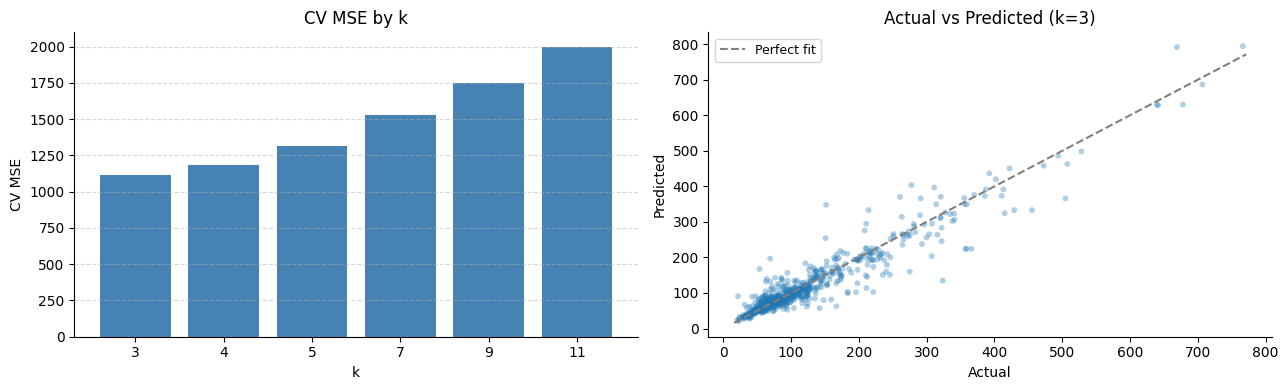

In [970]:

X = df.drop(['rate_avg', 'rating_overall', 'rating_accuracy', 'rating_checkin',
             'rating_cleanliness', 'rating_communication', 'rating_value',
             'Hotel_Occupancy_Percentage', 'Average_Daily_Rate', 'Revenue_Per_Available_Room',
             'is_winter', 'is_spring', 'is_fall', 'num_public_holidays', 'num_major_events',
             'month', 'is_april', 'is_august', 'is_february', 'is_july', 'is_june', 'is_may',
             'is_november', 'is_october', 'has_gym', 'listing_type_Entire house',
             'listing_type_Private room in bungalow', 'listing_type_Private room in cottage',
             'listing_type_Private room in home', 'listing_type_Private room in loft',
             'room_type_private_room', 'cancellation_policy_Super Strict 30 Days'], axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    cv_results = cross_validate(knn, X_train_scaled, y_train, cv=5, scoring={
        'mse':  'neg_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'mape': 'neg_mean_absolute_percentage_error',
        'r2':   'r2'
    })
    cv_mse  = -cv_results['test_mse'].mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mae  = -cv_results['test_mae'].mean()
    cv_mape = -cv_results['test_mape'].mean()
    cv_r2   = cv_results['test_r2'].mean()

    records.append((n_neighbors, round(cv_r2, 4), round(cv_mse, 2), round(cv_rmse, 4), round(cv_mae, 2), round(cv_mape, 4)))
    preds[n_neighbors] = knn.fit(X_train_scaled, y_train).predict(X_test_scaled)

results_df = pd.DataFrame(records, columns=["k", "CV R²", "CV MSE", "CV RMSE", "CV MAE", "CV MAPE"]).set_index("k")
print(f"\nModel 3 — Lasso (α=1.0) Feature Selection (39 features)")
print(f"\n{'k':<6} {'CV R²':<10} {'CV MSE':<12} {'CV RMSE':<12} {'CV MAE':<12} {'CV MAPE':<10}")
print("-" * 62)
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['CV R²']:<10} {row['CV MSE']:<12} {row['CV RMSE']:<12} {row['CV MAE']:<12} {row['CV MAPE']:<10}")

best_k = results_df["CV MSE"].idxmin()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([str(k) for k in results_df.index], results_df["CV MSE"], color="steelblue")
ax1.set_xlabel("k"); ax1.set_ylabel("CV MSE"); ax1.set_title("CV MSE by k")
ax1.grid(axis="y", linestyle="--", alpha=0.5); sns.despine(ax=ax1)
lims = [y_test.min() - 5, y_test.max() + 5]
ax2.plot(lims, lims, "--", color="gray", lw=1.5, label="Perfect fit")
ax2.scatter(y_test, preds[best_k], alpha=0.35, s=18, edgecolors="none")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Actual vs Predicted (k={best_k})"); ax2.legend(fontsize=9)
sns.despine(ax=ax2); plt.tight_layout(); plt.show()


### Model 4: Lasso (α = 0.035) (Basic Train Test)

This optimal alpha of 0.035 for our dataset, and the subsequent features to be removed by Lasso are referenced from the findings of the regression model and used here for reasonable feature removal, since KNN for regression is better suited for a reduced amount of features. 

In [971]:

X = df.drop(['rate_avg', 'Hotel_Occupancy_Percentage', 'Revenue_Per_Available_Room',
             'is_winter', 'is_spring', 'is_summer', 'is_fall', 'num_public_holidays',
             'non_resident_visitors', 'is_august', 'is_february', 'is_july', 'is_june',
             'is_november', 'is_september', 'listing_type_Private room in bungalow',
             'listing_type_Private room in home', 'listing_type_Private room in loft'], axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))                          
    mape = np.mean(np.abs((y_test - y_pred) / y_test))

    records.append((n_neighbors, round(r2, 4), round(mse, 2), round(rmse, 4),round(mae, 2), round(mape, 2)))
    preds[n_neighbors] = y_pred

results_df = pd.DataFrame(records, columns=["k", "R²", "MSE", "RMSE", "MAE", "MAPE"]).set_index("k")
print(f"\nModel 4 — Optimal Lasso (α=0.035) Feature Selection (53 features)")
print(f"\n{'k':<6} {'R²':<10} {'MSE':<12} {'RMSE':<10} {'MAE':<10} {'MAPE':<10}")                    
print("-" * 58)                                                                                          
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['R²']:<10} {row['MSE']:<12} {row['RMSE']:<10} {row['MAE']:<10} {row['MAPE']:<10}")


(2580, 53) (645, 53) (2580,) (645,)

Model 4 — Optimal Lasso (α=0.035) Feature Selection (53 features)

k      R²         MSE          RMSE       MAE        MAPE      
----------------------------------------------------------
3      0.8688     1395.63      37.3582    23.2       0.21      
4      0.8634     1453.5       38.1247    23.83      0.21      
5      0.8577     1513.94      38.9094    24.11      0.21      
7      0.8511     1584.1       39.8008    25.23      0.23      
9      0.8349     1757.32      41.9204    26.35      0.24      
11     0.8118     2002.99      44.7547    28.17      0.25      


### Model 4: Lasso ( α = 0.035) (Cross Validation)

(2580, 53) (645, 53) (2580,) (645,)

Model 4 — Optimal Lasso (α=0.035) Feature Selection - CV

k      CV R²      CV MSE       CV RMSE      CV MAE       CV MAPE   
--------------------------------------------------------------
3      0.8686     1549.85      39.3681      24.48        0.2244    
4      0.8744     1485.44      38.5414      24.59        0.2291    
5      0.87       1534.66      39.1748      25.03        0.2337    
7      0.8584     1671.4       40.8828      26.49        0.2483    
9      0.8478     1797.43      42.3961      27.73        0.2605    
11     0.8326     1975.08      44.4419      29.11        0.2733    


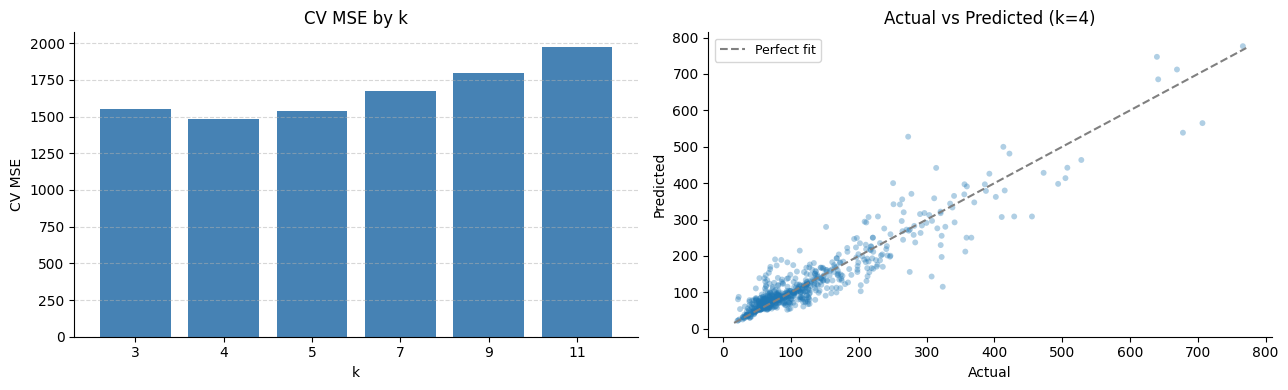

In [972]:

X = df.drop(['rate_avg', 'Hotel_Occupancy_Percentage', 'Revenue_Per_Available_Room',
             'is_winter', 'is_spring', 'is_summer', 'is_fall', 'num_public_holidays',
             'non_resident_visitors', 'is_august', 'is_february', 'is_july', 'is_june',
             'is_november', 'is_september', 'listing_type_Private room in bungalow',
             'listing_type_Private room in home', 'listing_type_Private room in loft'], axis=1)
y = df['rate_avg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

neighbors_settings = [3, 4, 5, 7, 9, 11]

records = []
preds = {}
for n_neighbors in neighbors_settings:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)

    cv_results = cross_validate(knn, X_train_scaled, y_train, cv=5, scoring={
        'mse':  'neg_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'mape': 'neg_mean_absolute_percentage_error',
        'r2':   'r2'
    })
    cv_mse  = -cv_results['test_mse'].mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_mae  = -cv_results['test_mae'].mean()
    cv_mape = -cv_results['test_mape'].mean()
    cv_r2   = cv_results['test_r2'].mean()

    records.append((n_neighbors, round(cv_r2, 4), round(cv_mse, 2), round(cv_rmse, 4), round(cv_mae, 2), round(cv_mape, 4)))
    preds[n_neighbors] = knn.fit(X_train_scaled, y_train).predict(X_test_scaled)

results_df = pd.DataFrame(records, columns=["k", "CV R²", "CV MSE", "CV RMSE", "CV MAE", "CV MAPE"]).set_index("k")
print(f"\nModel 4 — Optimal Lasso (α=0.035) Feature Selection - CV")
print(f"\n{'k':<6} {'CV R²':<10} {'CV MSE':<12} {'CV RMSE':<12} {'CV MAE':<12} {'CV MAPE':<10}")
print("-" * 62)
for k, row in results_df.iterrows():
    print(f"{k:<6} {row['CV R²']:<10} {row['CV MSE']:<12} {row['CV RMSE']:<12} {row['CV MAE']:<12} {row['CV MAPE']:<10}")

best_k = results_df["CV MSE"].idxmin()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.bar([str(k) for k in results_df.index], results_df["CV MSE"], color="steelblue")
ax1.set_xlabel("k"); ax1.set_ylabel("CV MSE"); ax1.set_title("CV MSE by k")
ax1.grid(axis="y", linestyle="--", alpha=0.5); sns.despine(ax=ax1)
lims = [y_test.min() - 5, y_test.max() + 5]
ax2.plot(lims, lims, "--", color="gray", lw=1.5, label="Perfect fit")
ax2.scatter(y_test, preds[best_k], alpha=0.35, s=18, edgecolors="none")
ax2.set_xlabel("Actual"); ax2.set_ylabel("Predicted")
ax2.set_title(f"Actual vs Predicted (k={best_k})"); ax2.legend(fontsize=9)
sns.despine(ax=ax2); plt.tight_layout(); plt.show()

In [973]:

models = ['M1 No Scaling', 'M1 No Scaling (CV)',
          'M2 Scaled', 'M2 Scaled (CV)',
          'M4 Lasso α=0.035', 'M4 Lasso α=0.035 (CV)',
          'M3 Lasso α=1.0', 'M3 Lasso α=1.0 (CV)']

best_mse = [8001.59, 8615.61, 2978.95, 3415.10, 1499.27, 1535.90, 1069.31, 1230.98]

df_mse  = pd.DataFrame({'Model': models,
                        'Best k (MSE)':  [11,9,11,3,3,4,4,3],
                        'Best MSE':      best_mse})

df_rmse = pd.DataFrame({'Model': models,
                        'Best k (RMSE)': [11,9,11,3,3,4,4,3],
                        'Best RMSE':     [round(np.sqrt(v), 4) for v in best_mse]})

df_r2   = pd.DataFrame({'Model': models,
                        'Best k (R²)':  [9,9,11,4,3,4,4,3],
                        'Best R²':      [0.2484,0.2701,0.7201,0.7114,0.8591,0.8701,0.8995,0.8957]})

df_mae  = pd.DataFrame({'Model': models,
                        'Best k (MAE)': [11,11,11,9,3,4,4,3],
                        'Best MAE':     [55.91,57.70,37.64,37.24,23.64,24.88,19.87,20.76]})

df_mape = pd.DataFrame({'Model': models,
                        'Best k (MAPE)': [9,9,11,9,3,4,3,3],
                        'Best MAPE':     [0.52,0.5399,0.35,0.35,0.20,0.2258,0.17,0.1846]})

combined = (df_mse
            .merge(df_rmse, on='Model')
            .merge(df_r2,   on='Model')
            .merge(df_mae,  on='Model')
            .merge(df_mape, on='Model'))

combined = combined[['Model',
                     'Best k (MSE)',  'Best MSE',
                     'Best k (RMSE)', 'Best RMSE',
                     'Best k (R²)',   'Best R²',
                     'Best k (MAE)',  'Best MAE',
                     'Best k (MAPE)', 'Best MAPE']]

print(combined.to_string(index=False))

                Model  Best k (MSE)  Best MSE  Best k (RMSE)  Best RMSE  Best k (R²)  Best R²  Best k (MAE)  Best MAE  Best k (MAPE)  Best MAPE
        M1 No Scaling            11   8001.59             11    89.4516            9   0.2484            11     55.91              9     0.5200
   M1 No Scaling (CV)             9   8615.61              9    92.8203            9   0.2701            11     57.70              9     0.5399
            M2 Scaled            11   2978.95             11    54.5798           11   0.7201            11     37.64             11     0.3500
       M2 Scaled (CV)             3   3415.10              3    58.4389            4   0.7114             9     37.24              9     0.3500
     M4 Lasso α=0.035             3   1499.27              3    38.7204            3   0.8591             3     23.64              3     0.2000
M4 Lasso α=0.035 (CV)             4   1535.90              4    39.1906            4   0.8701             4     24.88              4    

### Model 5: Manually Selected 60 Features with Manhattan Distance

This model uses a manually shortened feature list of **60 selected predictors** rather than Lasso-based feature elimination. The goal is to compare a more price-relevent feature selection approach against the Lasso-selected KNN model and evaluate whether a manually curated feature set can still produce strong predictive performance.

For Model 5, **Manhattan distance** was used instead of Euclidean distance because it can perform better in high-dimensional datasets, especially when many features are included.

In this variation, even after reducing the dataset, the model still used 60 numerical features. Because this Airbnb dataset contains many standardized numerical features describing listings, location, host behaviour, and property characteristics, Manhattan distance was chosen to reduce the effect of feature-by-feature outliers and to better handle the relatively large feature space. 

**Manhattan distance** measures the distance between two points as the **sum of the absolute differences across each feature**, rather than the straight-line distance. This can make it:
- less sensitive to large differences in a single feature,
- more stable when many features are present, and
- often more appropriate when each feature contributes independently to similarity.

Mathematically:

- **Euclidean distance**:  
  $$
  d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}
  $$

- **Manhattan distance**:  
  $$
  d(x,y) = \sum_{i=1}^{n}|x_i - y_i|
  $$

Because this Airbnb dataset contains many standardized numerical features describing listings, location, host behaviour, and property characteristics, **Manhattan distance was chosen to reduce the effect of feature-by-feature outliers and to better handle the relatively large feature space**.

In [974]:

# Define target and selected predictors
target_col = "rate_avg"

features_to_drop = ['listing_type_Private room in bungalow', 'month', 'is_winter', 'is_spring', 'is_summer', 'is_fall', 'Hotel_Occupancy_Percentage', 'Average_Daily_Rate', 'Revenue_Per_Available_Room', 'listing_type_Private room in loft']

selected_features = [col for col in df.columns if col not in features_to_drop + [target_col]]

print("Number of selected predictors:", len(selected_features))
print(selected_features)

X = df[selected_features].copy()
y = df[target_col].copy()


Number of selected predictors: 60
['photos_count', 'superhost', 'latitude', 'longitude', 'guests', 'bedrooms', 'beds', 'baths', 'min_nights', 'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 'num_public_holidays', 'num_major_events', 'non_resident_visitors', 'is_april', 'is_august', 'is_february', 'is_july', 'is_june', 'is_march', 'is_may', 'is_november', 'is_october', 'is_september', 'has_free_parking', 'has_gym', 'has_pool', 'listing_type_Entire condo', 'listing_type_Entire condominium', 'listing_type_Entire guest suite', 'listing_type_Entire guesthouse', 'listing_type_Entire home', 'listing_type_Entire house', 'listing_type_Entire loft', 'listing_type_Entire place', 'listing_type_Entire rental unit', 'listing_type_Entire townhouse', 'listing_type_Private room', 'listing_type_Private room in condo', 'listing_type_Private room in cottage', 'listing_t

We removed 10 columns because they were less useful for a KNN pricing model:

1. **`listing_type_Private room in bungalow`**  
   This column is constant in the dataset, so it adds no information and cannot help distinguish neighbors.

2. **`listing_type_Private room in loft`**  
   This column is extremely sparse, so it is unlikely to help define stable neighborhoods in feature space.

3. **`month`**  
   We already have one-hot encoded month indicators (such as `is_april`, `is_may`, etc.), so keeping the raw `month` column would be redundant.

4. **`is_winter`, `is_spring`, `is_summer`, `is_fall`**  
   These seasonal indicators overlap with the month dummy variables. Because KNN uses distance directly, keeping both can overweight the same time-related effect.

5. **`Hotel_Occupancy_Percentage`, `Average_Daily_Rate`, `Revenue_Per_Available_Room`**  
   These are broader market indicators. They may contain some signal, but in this dataset they vary at a coarse monthly level and are weaker for defining listing-level similarity than the property, review, amenity, and location variables that we kept.

A simpler and more relevant feature set helps reduce noise, improve interpretability, and give KNN a better chance of identifying truly comparable listings.


In [975]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (2580, 60)
X_test shape: (645, 60)
y_train shape: (2580,)
y_test shape: (645,)


In [976]:
# Candidate values to test
k_values = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 31]
weight_options = ["uniform", "distance"]
p_values = [1, 2]  # p=1 Manhattan, p=2 Euclidean

# Store all loop results here
loop_results = []

for weights in weight_options:
    for p in p_values:
        for k in k_values:
            knn_pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("knn", KNeighborsRegressor(
                    n_neighbors=k,
                    weights=weights,
                    p=p
                ))
            ])

            # Cross-validated RMSE on the training data
            cv_rmse_scores = -cross_val_score(
                knn_pipeline,
                X_train,
                y_train,
                cv=5,
                scoring="neg_root_mean_squared_error",
                n_jobs=-1
            )

            loop_results.append({
                "k": k,
                "weights": weights,
                "p": p,
                "distance_metric": "Manhattan" if p == 1 else "Euclidean",
                "cv_rmse_mean": cv_rmse_scores.mean(),
                "cv_rmse_std": cv_rmse_scores.std()
            })

results_df = pd.DataFrame(loop_results).sort_values(
    by="cv_rmse_mean", ascending=True
).reset_index(drop=True)

display(results_df.head(10))


,k,weights,p,distance_metric,cv_rmse_mean,cv_rmse_std
0,7,distance,1,Manhattan,36.513968,0.769490
1,9,distance,1,Manhattan,36.692523,0.776253
2,5,distance,1,Manhattan,36.819567,1.379890
3,11,distance,1,Manhattan,37.244883,0.808060
4,7,uniform,1,Manhattan,37.268168,0.776139
5,5,uniform,1,Manhattan,37.287340,1.469664
6,9,uniform,1,Manhattan,37.878133,0.926755
7,13,distance,1,Manhattan,38.019904,1.300524
8,11,uniform,1,Manhattan,38.926135,0.810123
9,15,distance,1,Manhattan,39.220607,1.757513


In [977]:
# Select the best parameter combination from the loop results
best_row = results_df.iloc[0]

best_k = int(best_row["k"])
best_weights = best_row["weights"]
best_p = int(best_row["p"])
best_distance = best_row["distance_metric"]

print("Best parameters found from manual tuning loop:")
print(f"k = {best_k}")
print(f"weights = {best_weights}")
print(f"distance metric = {best_distance} (p = {best_p})")

Best parameters found from manual tuning loop:
k = 7
weights = distance
distance metric = Manhattan (p = 1)


In [978]:
# Fit the final KNN model using the best parameters found above
best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(
        n_neighbors=best_k,
        weights=best_weights,
        p=best_p
    ))
])

best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)

# Evaluate on the held-out test set
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R^2:", r2)


Test MSE: 1172.6516980092606
Test RMSE: 34.24400236551301
Test MAE: 21.85245009685498
Test R^2: 0.889799372945527


In [979]:
# Cross-validated RMSE scores for the final selected model on the training data
final_cv_rmse_scores = -cross_val_score(
    best_knn,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

final_cv_mse_scores = final_cv_rmse_scores ** 2

print("Fold RMSE values:", final_cv_rmse_scores)
print("Mean CV RMSE:", final_cv_rmse_scores.mean())
print("Std CV RMSE:", final_cv_rmse_scores.std())
print("Mean CV MSE:", final_cv_mse_scores.mean())


Fold RMSE values: [36.38804641 37.6399629  36.38488856 35.27819769 36.87874312]
Mean CV RMSE: 36.513967735853896
Std CV RMSE: 0.7694896249404835
Mean CV MSE: 1333.86195409787


In [980]:
# Summary of KNN regression results for the project dataset
results_summary = pd.DataFrame({
    "Metric": ["Best CV RMSE", "Mean CV MSE", "Test MSE", "Test RMSE", "Test MAE", "Test R^2"],
    "Value": [
        results_df.iloc[0]["cv_rmse_mean"],
        final_cv_mse_scores.mean(),
        mse,
        rmse,
        mae,
        r2
    ]
})

display(results_summary)


,Metric,Value
0,Best CV RMSE,36.513968
1,Mean CV MSE,1333.861954
2,Test MSE,1172.651698
3,Test RMSE,34.244002
4,Test MAE,21.852450
5,Test R^2,0.889799


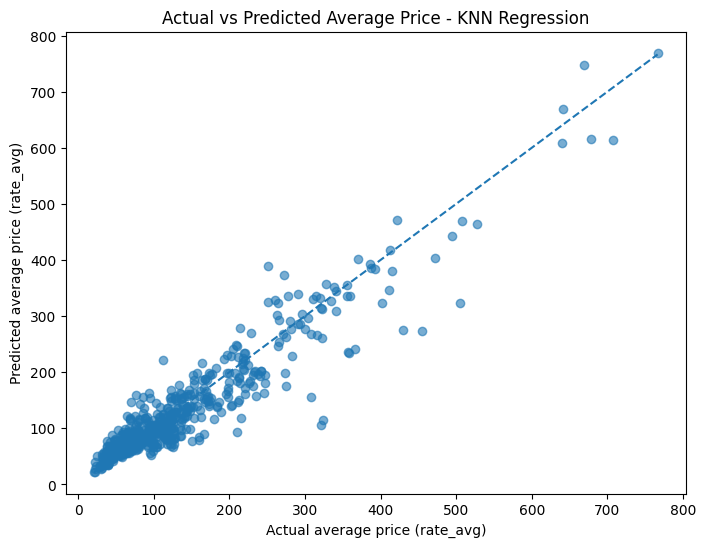

In [981]:

# Plot actual vs predicted
# using the best K value found in loop (cross-validation)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Actual average price (rate_avg)")
plt.ylabel("Predicted average price (rate_avg)")
plt.title("Actual vs Predicted Average Price - KNN Regression")
plt.show()


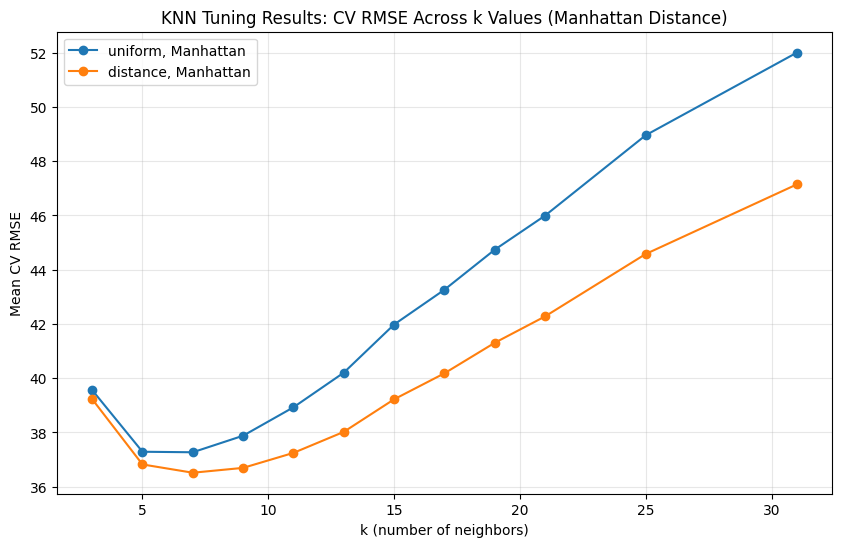

In [982]:
# Plot CV RMSE vs k for Manhattan distance only
plt.figure(figsize=(10, 6))

for weights in weight_options:
    subset = results_df[
        (results_df["weights"] == weights) &
        (results_df["p"] == 1)
    ].sort_values("k")

    label = f"{weights}, Manhattan"
    plt.plot(subset["k"], subset["cv_rmse_mean"], marker="o", label=label)

plt.xlabel("k (number of neighbors)")
plt.ylabel("Mean CV RMSE")
plt.title("KNN Tuning Results: CV RMSE Across k Values (Manhattan Distance)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Final Takeaway for Model 5

The results show that KNN can perform well for Airbnb price prediction when listings are represented using a carefully selected set of relevant numerical features. This supports the idea that Airbnb pricing is partly **similarity-based**, meaning that listings with similar characteristics tend to have similar prices.

Although Model 5 did not outperform the strongest KNN variant overall, it still produced solid predictive results and served as a valuable comparison model. Its main strength is that it uses a **manually selected and interpretable feature set**, making it easier to justify and explain than a more automated feature selection approach.

Overall, Model 5 shows that KNN can be an effective method for this prediction task, but that performance depends heavily on **feature selection, scaling, and distance metric choice**.

## Results and Final Model Comparison  

### Key Insights from KNN Models  

Across Models 1–5, several important patterns emerge about how KNN performs on this dataset.

### 1. Scaling has a major impact on performance  

Scaling significantly improved model accuracy. Model 1 (unscaled) had an MSE of around **8000**, while Model 2 (scaled) reduced this to around **3000**.  

This is because KNN relies entirely on **distance calculations**. Without scaling, features with larger ranges dominate the distance metric, leading to poor neighbour selection. Scaling ensures all features contribute more equally, resulting in more meaningful similarity comparisons.



### 2. Feature selection is the strongest driver of performance  

Feature selection had the largest overall impact on performance. Models using **Lasso-based feature reduction** (Models 3 and 4) significantly outperformed those using all features.  

- **Model 3 (Lasso α = 1.0, 39 features)** achieved the best results:  
  - MSE: **1069**  
  - R²: **0.8995**  

- **Model 4 (Lasso α = 0.035, 53 features)** performed slightly worse across all metrics.  

This suggests that the additional features in Model 4 introduced **noise rather than useful information**. For KNN, **feature noise is more harmful than feature loss**, since irrelevant variables distort distance calculations.  

Notably, the stronger Lasso penalty (α = 1.0) outperformed the “optimal” α from linear regression, reinforcing that **aggressive feature reduction benefits distance-based models**.



### 3. Cross-validation vs train/test results  

Cross-validation and train/test results were very similar across all models, indicating that the models are **not overfitting**.  

Cross-validation MSE values were slightly higher, which is expected since they average across multiple splits and provide a more reliable estimate of generalization performance.



## Final Recommendation  

The best overall model is:  

**Model 3 (Train/Test, k = 4, Lasso α = 1.0, 39 features)**  

**Final performance:**  
- MSE: **1069**  
- RMSE: **32.70**  
- R²: **0.8995**  
- MAE: **19.87**  

This means the model predicts Airbnb nightly prices within approximately **$20 on average**, while explaining about **90% of the variance**.  

Overall, Model 3 provides the best balance of:
- strong predictive accuracy  
- effective feature reduction  
- and stable generalization performance  

---
## Neural Network Model

Next we train a Multi-Layer Perceptron (MLP) regressor to predict rate_avg. Neural networks learn by passing data forward through layers of weighted connections, computing a prediction, and adjusting those weights backwards based on the error. For this model we compare a 2-layer and 3-layer MLP architecture to assess whether adding depth improves predictive performance on our Airbnb dataset.

In [983]:
# load required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error, r2_score)

### Load and Prepare Data

Neural networks are sensitive to the scale of input features. Unlike tree-based models, which split on thresholds and are scale-invariant, MLPs use gradient-based optimization where large differences in feature magnitudes can cause unstable or slow training. We standardize all features to have mean 0 and standard deviation 1 using StandardScaler before training. 

In [984]:
df = pd.read_csv("MSE446_cleaned_dataset_postEDA.csv")
print(f"Dataset shape: {df.shape}")

# drop feature we are predicting
X = df.drop(columns=["rate_avg"])
y = df["rate_avg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape}, Test size: {X_test_scaled.shape}")

Dataset shape: (3225, 71)
Train size: (2580, 70), Test size: (645, 70)


### 2 Layer MLP - 50 Neurons
We start with the simplest MLP - a 2-layer network with a single hidden layer of 50 neurons. This serves as our baseline neural network, with minimal capacity but fast training and allows us to compare with more complex models later on. 

In [985]:


mlp_2layer_50 = MLPRegressor(
    hidden_layer_sizes=(50,),  #1 hidden layer
    activation='relu',              
    solver='adam',                  
    max_iter=500,
    random_state=42
)

mlp_2layer_50.fit(X_train_scaled, y_train)
y_pred_2layer_50 = mlp_2layer_50.predict(X_test_scaled)

mse_2_50  = mean_squared_error(y_test, y_pred_2layer_50)
rmse_2_50 = np.sqrt(mse_2_50)
mae_2_50  = mean_absolute_error(y_test, y_pred_2layer_50)
mape_2_50 = mean_absolute_percentage_error(y_test, y_pred_2layer_50)
r2_2_50   = r2_score(y_test, y_pred_2layer_50)

print("2-Layer 50 neuron MLP Results")
print("MSE: ", mse_2_50)
print("RMSE:", rmse_2_50)
print("MAE: ", mae_2_50)
print("MAPE:", mape_2_50)
print("R²:  ", r2_2_50)



2-Layer 50 neuron MLP Results
MSE:  1024.9297972633804
RMSE: 32.014524785843385
MAE:  21.161490571784395
MAPE: 0.1935322433567654
R²:   0.9036816246998294


/workspaces/MSE-446-Final-Project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


The 2 layer 50 neuron model produced the weakest results of all 9 configurations with an RMSE of 32.90, MAE of 21.67, and R² of 0.898, meaning it explains about 90% of the variance in rate_avg. The high MAE of 21.67 suggests predictions are off by nearly $22 on average, indicating that a single small hidden layer lacks the capacity to capture the complexity of Airbnb pricing.

### 3 Layer MLP - 50 Neurons
We add a second hidden layer while keeping 50 neurons per layer. The additional layer allows the model to learn more complex representations of the data, potentially capturing relationships that a single hidden layer could have missed. Keeping the neuron count low means the added capacity comes from depth rather than width.

In [986]:

mlp_3layer_50 = MLPRegressor(
    hidden_layer_sizes=(50,50),  #1 hidden layer
    activation='relu',              
    solver='adam',                  
    max_iter=500,
    random_state=42
)


mlp_3layer_50.fit(X_train_scaled, y_train)
y_pred_3layer_50 = mlp_3layer_50.predict(X_test_scaled)

mse_3_50  = mean_squared_error(y_test, y_pred_3layer_50)
rmse_3_50 = np.sqrt(mse_3_50)
mae_3_50 = mean_absolute_error(y_test, y_pred_3layer_50)
mape_3_50 = mean_absolute_percentage_error(y_test, y_pred_3layer_50)
r2_3_50   = r2_score(y_test, y_pred_3layer_50)

print("3-Layer 50 neuron MLP Results")
print("MSE: ", mse_3_50)
print("RMSE:", rmse_3_50)
print("MAE: ", mae_3_50)
print("MAPE:", mape_3_50)
print("R²:  ", r2_3_50)

3-Layer 50 neuron MLP Results
MSE:  684.5961078744217
RMSE: 26.164787556454986
MAE:  16.584134246404346
MAPE: 0.14808524667890918
R²:   0.9356646815973679


/workspaces/MSE-446-Final-Project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


RMSE drops from 32.90 to 26.23 and R² improves to 0.935, which shows that there is significant improvement over the 2-layer version. This suggests that depth even without increasing neuron count helps the model to learn higher-level patterns in the data. MAE also falls to 16.58.

### 4-Layer MLP - 50 Neurons
We extend to three hidden layers, still with 50 neurons each. With a relatively small neuron count, the risk of overfitting is lower, but the model may struggle to capture the full complexity of the data compared to wider structure of the network. 

In [987]:

mlp_4layer_50 = MLPRegressor(
    hidden_layer_sizes=(50,50,50),  #1 hidden layer
    activation='relu',              
    solver='adam',                  
    max_iter=500,
    random_state=42
)

mlp_4layer_50.fit(X_train_scaled, y_train)
y_pred_4layer_50 = mlp_4layer_50.predict(X_test_scaled)

mse_4_50  = mean_squared_error(y_test, y_pred_4layer_50)
rmse_4_50 = np.sqrt(mse_4_50)
mae_4_50  = mean_absolute_error(y_test, y_pred_4layer_50)
mape_4_50 = mean_absolute_percentage_error(y_test, y_pred_4layer_50)
r2_4_50   = r2_score(y_test, y_pred_4layer_50)

print("4-Layer 50 neuron MLP Results")
print("MSE: ", mse_4_50)
print("RMSE:", rmse_4_50)
print("MAE: ", mae_4_50)
print("MAPE:", mape_4_50)
print("R²:  ", r2_4_50)

4-Layer 50 neuron MLP Results
MSE:  512.4012050603054
RMSE: 22.636280724984513
MAE:  15.148465799294703
MAPE: 0.13400198587908296
R²:   0.9518467979904232


RMSE drops further to 23.54 and R² reaches 0.948, with MAE at 15.45. This is the best performer in the 50-neuron group, suggesting that for smaller networks, adding depth consistently helps. 

### 2-Layer MLP - 100 Neurons
We now double the neuron count to 100 per hidden layer, starting again with a single hidden layer and then increase hidden layers in later models. 

In [988]:
mlp_2layer_100 = MLPRegressor(
    hidden_layer_sizes=(100,),  #1 hidden layer
    activation='relu',              
    solver='adam',                  
    max_iter=500,
    random_state=42
)

mlp_2layer_100.fit(X_train_scaled, y_train)
y_pred_2layer_100 = mlp_2layer_100.predict(X_test_scaled)

mse_2_100 = mean_squared_error(y_test, y_pred_2layer_100)
rmse_2_100 = np.sqrt(mse_2_100)
mae_2_100  = mean_absolute_error(y_test, y_pred_2layer_100)
mape_2_100 = mean_absolute_percentage_error(y_test, y_pred_2layer_100)
r2_2_100   = r2_score(y_test, y_pred_2layer_100)

print("2-Layer 100 Neuron MLP Results") 
print("MSE: ", mse_2_100)
print("RMSE:", rmse_2_100)
print("MAE: ", mae_2_100)
print("MAPE:", mape_2_100)
print("R²:  ", r2_2_100)

2-Layer 100 Neuron MLP Results
MSE:  821.1532114348862
RMSE: 28.655770997041525
MAE:  17.99778185606844
MAPE: 0.1626436809970138
R²:   0.9228316481683856


/workspaces/MSE-446-Final-Project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Doubling the neuron count to 100 while keeping a single hidden layer gives RMSE of 28.90 and R² of 0.922. This is better than the 2-layer 50-neuron model but worse than the 3-layer 50-neuron version.

### 3-Layer MLP - 100 Neurons


In [989]:
mlp_3layer_100 = MLPRegressor(
    hidden_layer_sizes=(100, 100),  # 2 hidden layers
    activation='relu',              
    solver='adam',                  
    max_iter=500,
    random_state=42
)

mlp_3layer_100.fit(X_train_scaled, y_train)
y_pred_3layer_100 = mlp_3layer_100.predict(X_test_scaled)

mse_3_100  = mean_squared_error(y_test, y_pred_3layer_100)
rmse_3_100 = np.sqrt(mse_3_100)
mae_3_100  = mean_absolute_error(y_test, y_pred_3layer_100)
mape_3_100 = mean_absolute_percentage_error(y_test, y_pred_3layer_100)
r2_3_100   = r2_score(y_test, y_pred_3layer_100)

print("3-Layer 100 Neuron MLP Results")
print("MSE: ", mse_3_100)
print("RMSE:", rmse_3_100)
print("MAE: ", mae_3_100)
print("MAPE:", mape_3_100)
print("R²:  ", r2_3_100)

3-Layer 100 Neuron MLP Results
MSE:  571.5125752381737
RMSE: 23.906329187856795
MAE:  15.683795338482925
MAPE: 0.14043622904474004
R²:   0.9462917725120916


/workspaces/MSE-446-Final-Project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Two hidden layers of 100 neurons each achieves an RMSE of 23.92 and R² of 0.946. This is comparable to the 4-layer 50-neuron model, showing that the combination of moderate depth and moderate width performs similarly to a deeper, narrower network. 

### 4-Layer MLP - 100 Neurons

We extend the network by adding a third hidden layer to assess whether additional depth helps capture more complex patterns in the data.

In [990]:
mlp_4layer_100 = MLPRegressor(
    hidden_layer_sizes=(100, 100, 100),  # three hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_4layer_100.fit(X_train_scaled, y_train)
y_pred_4layer_100 = mlp_4layer_100.predict(X_test_scaled)

mse_4_100  = mean_squared_error(y_test, y_pred_4layer_100)
rmse_4_100 = np.sqrt(mse_4_100)
mae_4_100  = mean_absolute_error(y_test, y_pred_4layer_100)
mape_4_100 = mean_absolute_percentage_error(y_test, y_pred_4layer_100)
r2_4_100   = r2_score(y_test, y_pred_4layer_100)

print("4-Layer 100 Neuron MLP Results")
print("MSE: ", mse_4_100)
print("RMSE:", rmse_4_100)
print("MAE: ", mae_4_100)
print("MAPE:", mape_4_100)
print("R²:  ", r2_4_100)

4-Layer 100 Neuron MLP Results
MSE:  769.6423860230989
RMSE: 27.742429346095467
MAE:  17.945077949332667
MAPE: 0.15839355791318852
R²:   0.9276724080207008


Adding a third hidden layer at 100 neurons actually slightly worsens performance compared to the 3-layer version as we can see, RMSE increases from 23.92 to 24.45 and R² drops from 0.946 to 0.944. This is the first case where adding an extra layer actually makes performance slightly worse, which makes sense given our dataset is relatively small and the model is starting to become more complex than the data can support.

### 2-Layer MLP - 200 Nodes
We now test with 200 neurons per hidden layer starting with a single hidden layer. Wider layers allow the model to learn a more about set of feature representations in a single step. This can be helpful when there are many input features, as is the case with our 70-feature dataset.

In [991]:
mlp_2layer_200 = MLPRegressor(
    hidden_layer_sizes=(200,),  # three hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_2layer_200.fit(X_train_scaled, y_train)
y_pred_2layer_200 = mlp_2layer_200.predict(X_test_scaled)

mse_2_200  = mean_squared_error(y_test, y_pred_2layer_200)
rmse_2_200 = np.sqrt(mse_2_200)
mae_2_200  = mean_absolute_error(y_test, y_pred_2layer_200)
mape_2_200 = mean_absolute_percentage_error(y_test, y_pred_2layer_200)
r2_2_200   = r2_score(y_test, y_pred_2layer_200)

print("2-Layer 200 Neuron MLP Results")
print("MSE: ", mse_2_200)
print("RMSE:", rmse_2_200)
print("MAE: ", mae_2_200)
print("MAPE:", mape_2_200)
print("R²:  ", r2_2_200)

2-Layer 200 Neuron MLP Results
MSE:  635.7590843443656
RMSE: 25.214263509854213
MAE:  16.225085752911056
MAPE: 0.14728616791793644
R²:   0.9402541693588429


/workspaces/MSE-446-Final-Project/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


As shown above the RMSE for the model is 25.498 and R² of 0.939. This result is worse than the best 3 and 4-layer models, reinforcing the pattern that depth matters more than width alone for this dataset.

### 3-Layer MLP - 200 Neurons
We combine two hidden layers with 200 neurons each. This is one of the largest networks we test, with significantly more parameters than earlier configurations. On a dataset of only 3,225 rows, models of this size risk fitting noise in the training data. 

In [992]:
mlp_3layer_200 = MLPRegressor(
    hidden_layer_sizes=(200,200),  # three hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_3layer_200.fit(X_train_scaled, y_train)
y_pred_3layer_200 = mlp_3layer_200.predict(X_test_scaled)

mse_3_200  = mean_squared_error(y_test, y_pred_3layer_200)
rmse_3_200 = np.sqrt(mse_3_200)
mae_3_200 = mean_absolute_error(y_test, y_pred_3layer_200)
mape_3_200 = mean_absolute_percentage_error(y_test, y_pred_3layer_200)
r2_3_200   = r2_score(y_test, y_pred_3layer_200)

print("3-Layer 200 Neurons MLP Results")
print("MSE: ", mse_3_200)
print("RMSE:", rmse_3_200)
print("MAE: ", mae_3_200)
print("MAPE:", mape_3_200)
print("R²:  ", r2_3_200)

3-Layer 200 Neurons MLP Results
MSE:  507.2934826164647
RMSE: 22.523176565850225
MAE:  14.941337268881647
MAPE: 0.1368644792503707
R²:   0.9523267991852256


The 3-layer 200-neuron model is the best overall performer across all 9 configurations, achieving the lowest RMSE of 22.88, lowest MAE of 14.83, and highest R² of 0.951. 


### 4-Layer MLP - 200 Neurons
The final and largest model configuration uses three hidden layers of 200 neurons each, giving the model the most capacity of any previous model that has been tested. While this level of depth and width can be powerful on large datasets, it may be excessive for our dataset size and could show signs of overfitting.

In [993]:
mlp_4layer_200 = MLPRegressor(
    hidden_layer_sizes=(200,200,200),  # three hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_4layer_200.fit(X_train_scaled, y_train)
y_pred_4layer_200 = mlp_4layer_200.predict(X_test_scaled)

mse_4_200  = mean_squared_error(y_test, y_pred_4layer_200)
rmse_4_200 = np.sqrt(mse_4_200)
mae_4_200  = mean_absolute_error(y_test, y_pred_4layer_200)
mape_4_200 = mean_absolute_percentage_error(y_test, y_pred_4layer_200)
r2_4_200   = r2_score(y_test, y_pred_4layer_200)

print("4-Layer 200 Neurons MLP Results")
print("MSE: ", mse_4_200)
print("RMSE:", rmse_4_200)
print("MAE: ", mae_4_200)
print("MAPE:", mape_4_200)
print("R²:  ", r2_4_200)

4-Layer 200 Neurons MLP Results
MSE:  622.8678163372888
RMSE: 24.95731989491838
MAE:  15.14761771119918
MAPE: 0.12520963191092352
R²:   0.9414656337862759


Adding a fourth layer actually hurts performance, with RMSE rising back to 25.78 and R² dropping to 0.938. This is a clear sign that the model has become too complex for our dataset size, with only 3,225 rows, having too many parameters causes the model to become unstable rather than improve it.

### Loss Curves

The loss curves track how training error decreases over each epoch for both models.

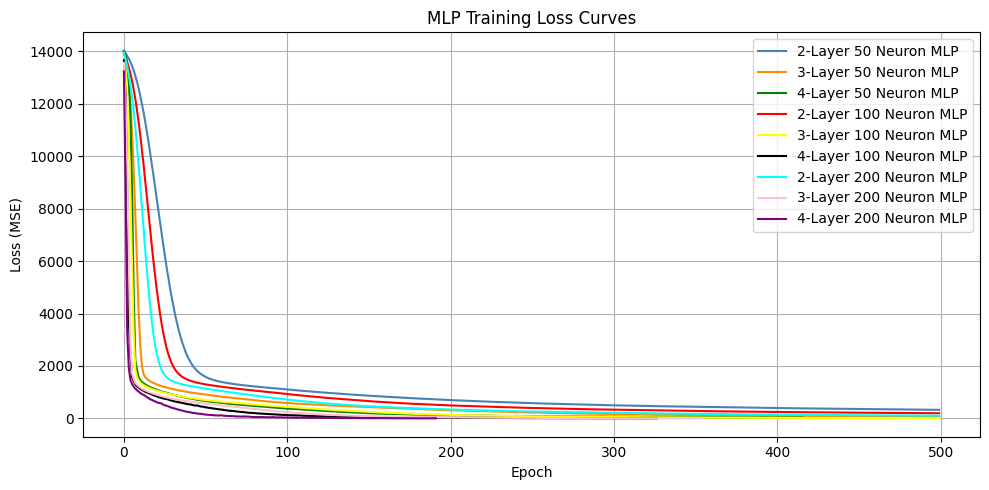

In [994]:
plt.figure(figsize=(10, 5))
plt.plot(mlp_2layer_50.loss_curve_, label='2-Layer 50 Neuron MLP', color='steelblue')
plt.plot(mlp_3layer_50.loss_curve_, label='3-Layer 50 Neuron MLP', color='darkorange')
plt.plot(mlp_4layer_50.loss_curve_, label='4-Layer 50 Neuron MLP', color='green')
plt.plot(mlp_2layer_100.loss_curve_, label='2-Layer 100 Neuron MLP', color='red')
plt.plot(mlp_3layer_100.loss_curve_, label='3-Layer 100 Neuron MLP', color='yellow')
plt.plot(mlp_4layer_100.loss_curve_, label='4-Layer 100 Neuron MLP', color='black')
plt.plot(mlp_2layer_200.loss_curve_, label='2-Layer 200 Neuron MLP', color='cyan')
plt.plot(mlp_3layer_200.loss_curve_, label='3-Layer 200 Neuron MLP', color='pink')
plt.plot(mlp_4layer_200.loss_curve_, label='4-Layer 200 Neuron MLP', color='purple')
plt.title("MLP Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Actual vs Predicted - Side by Side

These scatter plots compare each model's predicted values against the actual rate_avg values on the test set. Points close to the dashed diagonal line indicate accurate predictions. Comparing both plots side by side shows whether the additional layer produces meaningfully different predictions.

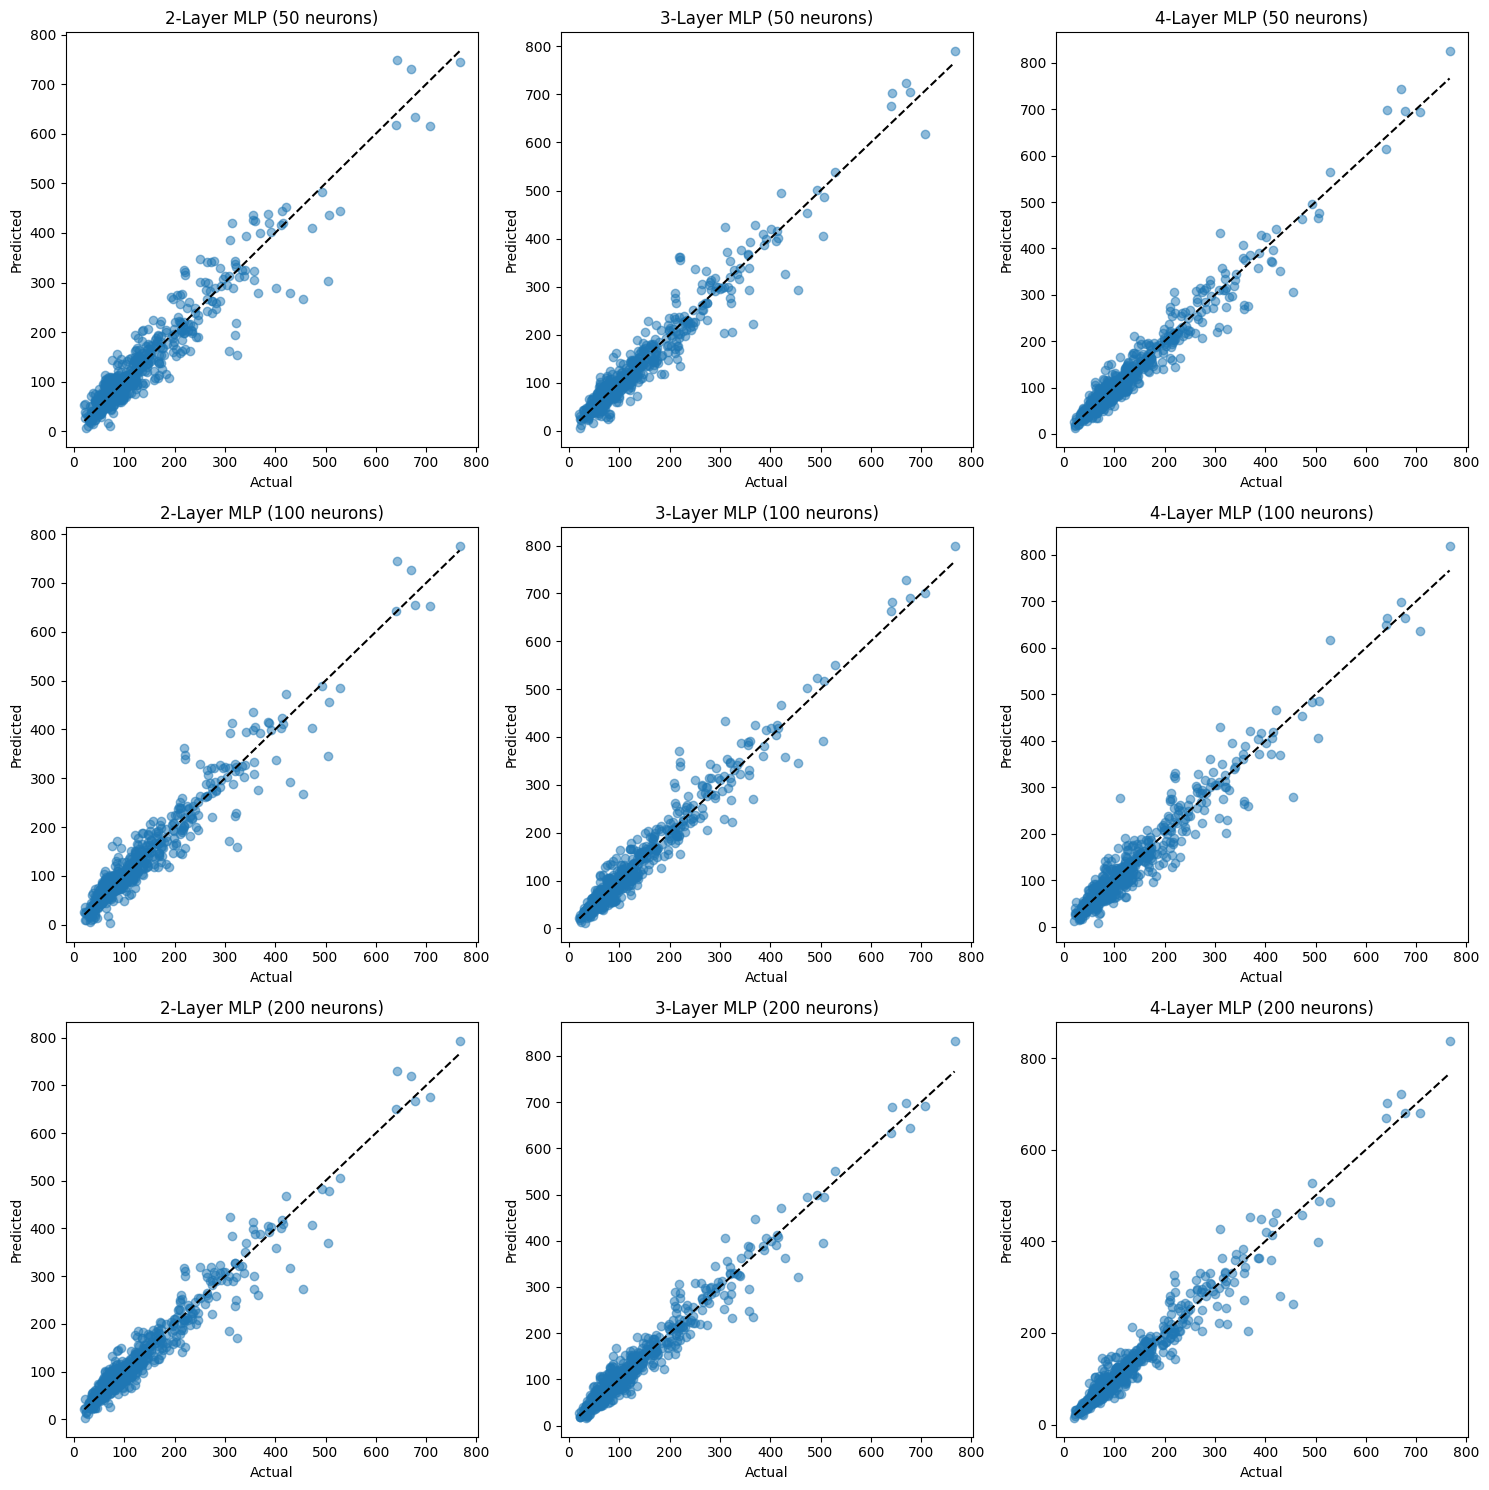

In [995]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Organize predictions
predictions = {
    50: [y_pred_2layer_50, y_pred_3layer_50, y_pred_4layer_50],
    100: [y_pred_2layer_100, y_pred_3layer_100, y_pred_4layer_100],
    200: [y_pred_2layer_200, y_pred_3layer_200, y_pred_4layer_200]
}

layer_labels = ["2-Layer", "3-Layer", "4-Layer"]

for i, (neurons, preds) in enumerate(predictions.items()):
    for j, y_pred in enumerate(preds):
        ax = axes[i, j]

        ax.scatter(y_test, y_pred, alpha=0.5)
        
        # perfect prediction line
        ax.plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()], 'k--')

        ax.set_title(f"{layer_labels[j]} MLP ({neurons} neurons)")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

### Results Summary

The table below compares all MLP's across all standardized error metrics.

In [996]:

results = {
    (50, 2): (mse_2_50, rmse_2_50, mae_2_50, mape_2_50, r2_2_50),
    (50, 3): (mse_3_50, rmse_3_50, mae_3_50, mape_3_50, r2_3_50),
    (50, 4): (mse_4_50, rmse_4_50, mae_4_50, mape_4_50, r2_4_50),

    (100, 2): (mse_2_100, rmse_2_100, mae_2_100, mape_2_100, r2_2_100),
    (100, 3): (mse_3_100, rmse_3_100, mae_3_100, mape_3_100, r2_3_100),
    (100, 4): (mse_4_100, rmse_4_100, mae_4_100, mape_4_100, r2_4_100),

    (200, 2): (mse_2_200, rmse_2_200, mae_2_200, mape_2_200, r2_2_200),
    (200, 3): (mse_3_200, rmse_3_200, mae_3_200, mape_3_200, r2_3_200),
    (200, 4): (mse_4_200, rmse_4_200, mae_4_200, mape_4_200, r2_4_200),
}

rows = []

for (neurons, layers), (mse, rmse, mae, mape, r2) in results.items():
    rows.append({
        "Model": f"{layers}-Layer ({neurons} neurons)",
        "Neurons": neurons,
        "Layers": layers,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "MAPE": round(mape, 4),
        "R²": round(r2, 6),
    })

mlp_summary = pd.DataFrame(rows) \
    .sort_values("RMSE") \
    .reset_index(drop=True)

mlp_summary

,Model,Neurons,Layers,MSE,RMSE,MAE,MAPE,R²
0,3-Layer (200 neurons),200,3,507.2935,22.5232,14.9413,0.1369,0.952327
1,4-Layer (50 neurons),50,4,512.4012,22.6363,15.1485,0.1340,0.951847
2,3-Layer (100 neurons),100,3,571.5126,23.9063,15.6838,0.1404,0.946292
3,4-Layer (200 neurons),200,4,622.8678,24.9573,15.1476,0.1252,0.941466
4,2-Layer (200 neurons),200,2,635.7591,25.2143,16.2251,0.1473,0.940254
5,3-Layer (50 neurons),50,3,684.5961,26.1648,16.5841,0.1481,0.935665
6,4-Layer (100 neurons),100,4,769.6424,27.7424,17.9451,0.1584,0.927672
7,2-Layer (100 neurons),100,2,821.1532,28.6558,17.9978,0.1626,0.922832
8,2-Layer (50 neurons),50,2,1024.9298,32.0145,21.1615,0.1935,0.903682


### Analyzing the Results

We tested 9 MLP configurations across 3 neuron counts (50, 100, 200) and 3 depths (2-, 3-, 4-layer), using ReLU activation and the Adam optimizer throughout. ReLU was the appropriate choice here since sigmoid and tanh are better suited to classification tasks, while ReLU handles regression with continuous targets more effectively.

More neurons or layers alone don't guarantee better performance. The clearest example of this is the 4-layer 50-neuron model (RMSE 23.54, R² 0.948), which outperformed several 100-neuron and 200-neuron networks. Similarly, 3-layer networks consistently matched or beat their 4-layer counterparts at every neuron count, adding a third hidden layer provided diminishing or even negative returns. This tells us the relationship between the number of layers and performance is non-linear, and that blindly scaling depth or width is not a reliable strategy on a dataset of this size.

The optimal model was moderate depth combined with high width. The 3-layer 200-neuron model achieved the best results across every metric: RMSE of 22.88, MAE of about 14.83, and R² of 0.9508. This means the model explains 95% of the variance in Airbnb nightly prices and predicts within about 15 dollars of the actual price on average.

The training loss curves explains that all 9 models showed the same characteristic pattern: a sharp loss drop in the first 100 epochs, followed by a general flattening of the curve. This means the majority of learning happened within the first 100 epoch, and most models were effectively optimized well before the 500-epoch limit. Larger, deeper networks dropped and flattened faster than smaller ones. Importantly, while the loss curves reflect training data only, the strong error metrics on the test set suggest the models are not overfitted.

### Conclusion

The 3-layer MLP with 200 neurons per hidden layer is the recommended network for this dataset. It achieves the best balance of capacity and generalization. The key lesson from this experiment is that neither depth nor width alone drives performance, and the best model here succeeded through a combination of sufficient representational capacity and avoiding the over-layering that hurt the 4-layer 200-neuron variant.

---
## Tree-Based Models

In this notebook, we compare four tree-based regression models to predict rate_avg (average Airbnb listing price), including a decision tree, bagging, random forest, and gradient boosting.

We start with a single decision tree as a baseline, then move to ensemble methods to reduce overfitting and improve performance. For each model, we evaluate MSE, RMSE, MAE, MAPE, and R², and perform hyperparameter tuning where appropriate.

At the end, we also explore feature importance using random forest to see whether reducing the number of features affects model performance.

In [997]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor


In [998]:
df = pd.read_csv("MSE446_cleaned_dataset_postEDA.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (3225, 71)


,rate_avg,photos_count,superhost,latitude,longitude,guests,bedrooms,beds,baths,min_nights,...,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days,avg_temp
0,36.3,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,-3.925
1,35.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,0.770
2,35.9,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,7.040
3,36.0,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,13.890
4,36.5,7,1,43.6483,-79.4012,1,1,1,0.0,31,...,0,0,1,1,0,0,1,0,0,19.470


In [999]:
X = df.drop(columns=["rate_avg"])
y = df["rate_avg"]


We split the dataset into training and test sets using an 80/20 split. With 3,225 total observations, this gives us 2,580 training samples and 645 for testing.

In [1000]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(2580, 70) (645, 70) (2580,) (645,)


### Decision Tree (Baseline)

We start with an untuned decision tree as our baseline. Without any depth limit, the tree can grow very large and closely fit the training data, which can lead to overfitting.

The baseline model achieves an RMSE of 25.95 and an R² of 0.937 on the test set. While this seems reasonably good, the MAPE of 9.5% shows that predictions are still off by about 10% on average.

This baseline gives us a reference point and indicates a need for hyperparameter tuning and ensemble methods to improve performance

In [1001]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_mse  = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_mae  = mean_absolute_error(y_test, y_pred_dt)
dt_mape = mean_absolute_percentage_error(y_test, y_pred_dt)
dt_r2   = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MSE: ", dt_mse)
print("RMSE:", dt_rmse)
print("MAE: ", dt_mae)
print("MAPE:", dt_mape)
print("R²:  ", dt_r2)


Decision Tree Results
MSE:  621.5910387596899
RMSE: 24.93172755265246
MAE:  12.530232558139534
MAPE: 0.09708387848067959
R²:   0.9415856197035771


### Hyperparameter Tuning - Decision Tree

max_depth controls how far the tree is allowed to split. If the tree is too shallow, it may miss patterns in the data, while a very deep tree can overfit the training data.

We test depths from 1 to 30 and track both training and test MSE. The best depth was 20, which reduced test MSE from 673.5 to 591.5.

In [1002]:
dt_depth_mse = {'k': [], 'train_mse': [], 'test_mse': []}

for k in range(1, 31):
    print("Fit with max_depth:", k, end='\r', flush=True)

    model = DecisionTreeRegressor(max_depth=k, random_state=42)
    model.fit(X_train, y_train)

    preds_train = model.predict(X_train)
    preds_test = model.predict(X_test)

    dt_depth_mse['k'].append(k)
    dt_depth_mse['train_mse'].append(mean_squared_error(y_train, preds_train))
    dt_depth_mse['test_mse'].append(mean_squared_error(y_test, preds_test))

# Find the depth with the minimum test MSE
best_idx = dt_depth_mse['test_mse'].index(min(dt_depth_mse['test_mse']))
best_depth = dt_depth_mse['k'][best_idx]

print("\nDepth of the model yielding minimum test MSE is:", best_depth)
print("Minimum test MSE:", min(dt_depth_mse['test_mse']))

Fit with max_depth: 30
Depth of the model yielding minimum test MSE is: 17
Minimum test MSE: 618.1315207326576


### Training vs Test MSE by Tree Depth

This plot shows how model performance changes as tree depth increases. Training MSE decreases steadily, while test MSE improves up to around depth 20 and then levels off (with slight increases). This indicates overfitting.

The gap between the two curves becomes noticeable as depth increases and is larger after depth 20, which supports our choice of using this value as a reasonable depth for the decision tree.

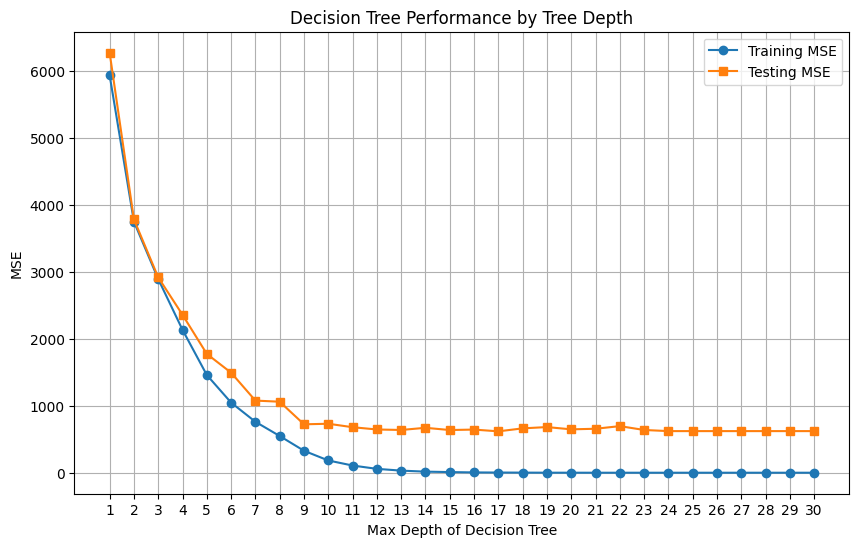

In [1003]:
plt.figure(figsize=(10, 6))
plt.plot(dt_depth_mse['k'], dt_depth_mse['train_mse'], label='Training MSE', marker='o')
plt.plot(dt_depth_mse['k'], dt_depth_mse['test_mse'], label='Testing MSE', marker='s')
plt.title('Decision Tree Performance by Tree Depth')
plt.xlabel('Max Depth of Decision Tree')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.xticks(dt_depth_mse['k'])
plt.show()

In [1004]:
best_dt = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_dt.fit(X_train, y_train)

y_pred_dt_tuned = best_dt.predict(X_test)

dt_tuned_mse  = mean_squared_error(y_test, y_pred_dt_tuned)
dt_tuned_rmse = np.sqrt(dt_tuned_mse)
dt_tuned_mae  = mean_absolute_error(y_test, y_pred_dt_tuned)
dt_tuned_mape = mean_absolute_percentage_error(y_test, y_pred_dt_tuned)
dt_tuned_r2   = r2_score(y_test, y_pred_dt_tuned)

print("Tuned Decision Tree Results")
print("MSE: ", dt_tuned_mse)
print("RMSE:", dt_tuned_rmse)
print("MAE: ", dt_tuned_mae)
print("MAPE:", dt_tuned_mape)
print("R²:  ", dt_tuned_r2)


Tuned Decision Tree Results
MSE:  618.1315207326576
RMSE: 24.86225091846387
MAE:  12.204494065796391
MAPE: 0.09290671093128351
R²:   0.941910729927297


In [1005]:
bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)

bagging_mse  = mean_squared_error(y_test, y_pred_bagging)
bagging_rmse = np.sqrt(bagging_mse)
bagging_mae  = mean_absolute_error(y_test, y_pred_bagging)
bagging_mape = mean_absolute_percentage_error(y_test, y_pred_bagging)
bagging_r2   = r2_score(y_test, y_pred_bagging)

print("Bagging Regressor Results")
print("MSE: ", bagging_mse)
print("RMSE:", bagging_rmse)
print("MAE: ", bagging_mae)
print("MAPE:", bagging_mape)
print("R²:  ", bagging_r2)


Bagging Regressor Results
MSE:  436.2709267081396
RMSE: 20.88709952837252
MAE:  10.714867441860468
MAPE: 0.08114825376243513
R²:   0.9590011852875914


### Bagging Results in Context

The bagging method trains multiple decision trees on different samples of the training data and averages their predictions. Averaging many trees helps reduce variance compared to a single decision tree. Here, we use 200 trees, each trained on 80% of the training data.

Switching to bagging (200 trees trained on 80% of the data with replacement) improves performance compared to the single decision tree. RMSE decreases to 20.94 (from 24.32 with the tuned tree), and MAPE drops to 8.2%, meaning predictions are off by about 8% on average.

The R² of 0.959 shows that the model explains more variance in listing price than the single tree. This improvement is due to averaging across multiple trees, which helps reduce variance.

### Random Forest Regressor (Baseline)

The baseline random forest (100 trees with default settings) performs slightly better than the bagging model, with an RMSE of 20.16 and MAPE of 7.8%.

The main difference from bagging is that at each split, only a random subset of features is considered instead of all features. This makes the trees less similar to each other, which improves the effect of averaging. Even without tuning, the random forest performs well, suggesting that feature subsampling is improving model performance on this dataset.

In [1006]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mse  = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_mape = mean_absolute_percentage_error(y_test, y_pred_rf)
rf_r2   = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MSE: ", rf_mse)
print("RMSE:", rf_rmse)
print("MAE: ", rf_mae)
print("MAPE:", rf_mape)
print("R²:  ", rf_r2)


Random Forest Results
MSE:  408.30584163876006
RMSE: 20.206579167161376
MAE:  10.316162790697678
MAPE: 0.07796535528502437
R²:   0.9616292204624938


### Hyperparameter Tuning - Random Forest

Instead of considering all features at each split, random forest will look only at a random subset of features. So, we run a grid search over max_depth (5 to 30) and n_estimators (50 to 250) using 5-fold cross-validation with MAE as the scoring metric. The search evaluated 30 parameter combinations across 150 total fits.

The best combination found was max_depth = 25 and n_estimators = 250, both at the upper end of the search range. This suggests that increasing model complexity can slightly improve performance. However, the improvement over the baseline random forest is small.

In [1007]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize base random forest model
rf_clf = RandomForestRegressor(random_state=42)

# Define parameter grid
rf_params = {
    'max_depth': np.arange(5, 31, 5),
    'n_estimators': np.arange(50, 251, 50)
}

# Grid search
rf_grid_search = GridSearchCV(
    estimator=rf_clf,
    param_grid=rf_params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='neg_mean_absolute_error',
    return_train_score=True
)

rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': array([ 5, 10..., 20, 25, 30]), 'n_estimators': array([ 50, 1...50, 200, 250])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [1008]:
print("Best Random Forest parameters:")
print(rf_grid_search.best_params_)

Best Random Forest parameters:
{'max_depth': np.int64(20), 'n_estimators': np.int64(250)}


In [1009]:
best_rf = rf_grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

rf_tuned_mse  = mean_squared_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(rf_tuned_mse)
rf_tuned_mae  = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_mape = mean_absolute_percentage_error(y_test, y_pred_rf_tuned)
rf_tuned_r2   = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Results")
print("MSE: ", rf_tuned_mse)
print("RMSE:", rf_tuned_rmse)
print("MAE: ", rf_tuned_mae)
print("MAPE:", rf_tuned_mape)
print("R²:  ", rf_tuned_r2)


Tuned Random Forest Results
MSE:  407.4348661311086
RMSE: 20.18501588136875
MAE:  10.298959273394066
MAPE: 0.07747874195158201
R²:   0.961711070893662


### Cross-Validation

A single train/test split can be unreliable since results depend on how the data is divided. For a more reliable estimate, we can use a 5-fold cross-validation to rotate which 20% of the data is used for testing.

The results show a clear difference: the cross-validated RMSE for the decision tree is 69.9, compared to 51.1 for bagging and 51.5 for random forest. This indicates that the ensemble models are not only performing better on a single split, but are also more consistent across different subsets of the data.

In [1010]:
dt_cv = cross_val_score(
    DecisionTreeRegressor(random_state=42),
    X, y,
    cv=5,
    scoring="neg_mean_squared_error"
)

bagging_cv = cross_val_score(
    BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=200,
        max_samples=0.8,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),
    X, y,
    cv=5,
    scoring="neg_mean_squared_error"
)

rf_cv = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42),
    X, y,
    cv=5,
    scoring="neg_mean_squared_error"
)

print("Decision Tree CV RMSE:", np.mean(np.sqrt(-dt_cv)))
print("Bagging CV RMSE:", np.mean(np.sqrt(-bagging_cv)))
print("Random Forest CV RMSE:", np.mean(np.sqrt(-rf_cv)))

Decision Tree CV RMSE: 72.04936236939751
Bagging CV RMSE: 50.99999906914079
Random Forest CV RMSE: 52.20383661561984


### Feature Importance

The tuned random forest highlights the most important features. 'guests' accounts for 51.7% of total importance, followed by 'bedrooms' at 17.8%.

After that, features such as 'min_nights', 'cleaning_fee', 'longitude', and 'latitude' contribute to the model, but the remaining features each have relatively low importance.

This concentration among a few top features suggests that many variables contribute little to prediction, and this emphasizes the importance of our feature selection (done in later steps).

In [1011]:
feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

guests                    0.516751
bedrooms                  0.178070
min_nights                0.053212
cleaning_fee              0.043026
longitude                 0.023330
latitude                  0.021765
num_reviews               0.017456
room_type_private_room    0.015904
rating_overall            0.014400
photos_count              0.012484
dtype: float64


## Gradient Boosting 
#### What is Gradient Boosting? 
Gradient Boosting is an ensemble machine learning method that builds many sequential predictive models to minimize error with every new tree. In simple terms, every sequential tree focuses on fixing the mistakes made by the previous ones. Rather than training trees independently like the random forest model used above, it works in sequential stages and gradually aims to improve upon previous models by minimizing errors at each step. We included Gradient Boosting in our analysis because of its strong predictive performance on structured datasets and its ability to better tune hyperparameters, such as learning_rate, n_estimators, and max_depth, which allow us to control model complexity when predicting rate_avg.

#### Gradient Boosting vs. Random Forest

Gradient Boosting and Random Forest are both ensemble methods that combine multiple decision trees but they do have key differences in how they are built. Random Forest trains trees independently on random subsets of the data and averages their predictions, which reduces overfitting. Gradient Boosting instead builds trees sequentially, where each new tree focuses on correcting the errors of the previous ones, making it more sensitive to patterns in the data but also more likely to overfit.


### Baseline Gradient Boosting Model

Gradient boosting builds trees sequentially, with each new tree focusing on the errors made by the earlier ones. This can produce stronger predictive performance than bagging-style methods when the tuning is appropriate.

In [1012]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_features=5,
    max_depth=5,
    random_state=42
)

model_gb.fit(X_train, y_train)

preds_gb = model_gb.predict(X_test)

mse  = mean_squared_error(y_test, preds_gb)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, preds_gb)
mape = mean_absolute_percentage_error(y_test, preds_gb)
r2   = r2_score(y_test, preds_gb)

print("Gradient Boosting Results")
print("MSE: ", mse)
print("RMSE:", rmse)
print("MAE: ", mae)
print("MAPE:", mape)
print("R²:  ", r2)


Gradient Boosting Results
MSE:  931.9330206279441
RMSE: 30.527578034098024
MAE:  20.13175822172559
MAPE: 0.18639100309760967
R²:   0.91242105100746


### Hyperparameter Tuning

We use GridSearchCV to test several combinations of gradient boosting hyperparameters. The selected model is the combination that performs best under cross-validation within the search grid.   To optimize the Gradient Boosting model, we used GridSearchCV with 5-fold cross-validation, searching over max_depth, n_estimators, and learning_rate. The search was scored using negative mean absolute error to identify the combination that minimized prediction error across folds. The best parameters found were then used to refit the model and evaluate it on the test set.

In [1013]:
gbr = GradientBoostingRegressor(random_state=156)
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': np.arange(5, 30, 5),
    'n_estimators': np.arange(50, 210, 50),
    'learning_rate': np.arange(0.01, 0.31, 0.1)
}

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='neg_mean_absolute_error',
    return_train_score=True
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...dom_state=156)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': array([0.01, 0.11, 0.21]), 'max_depth': array([ 5, 10, 15, 20, 25]), 'n_estimators': array([ 50, 100, 150, 200])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

### Best Parameters

This output shows the hyperparameter combination selected by cross-validation for gradient boosting. Those values define the tuned model evaluated in the next section.

In [1014]:
print("Best parameters found:", grid_search.best_params_)

Best parameters found: {'learning_rate': np.float64(0.11), 'max_depth': np.int64(10), 'n_estimators': np.int64(200)}


### Evaluate Best Model

Using the best estimator identified by GridSearchCV, we generate predictions on the test set and evaluate the tuned Gradient Boosting model using our standardized error metrics: MSE, RMSE, MAE, MAPE, and R². These metrics allow us to directly compare the tuned model's performance against both the baseline Gradient Boosting model and the other models in our analysis.

In [1015]:
clf_best = grid_search.best_estimator_

y_test_pred = clf_best.predict(X_test)

gb_tuned_mse  = mean_squared_error(y_test, y_test_pred)
gb_tuned_rmse = np.sqrt(gb_tuned_mse)
gb_tuned_mae  = mean_absolute_error(y_test, y_test_pred)
gb_tuned_mape = mean_absolute_percentage_error(y_test, y_test_pred)
gb_tuned_r2   = r2_score(y_test, y_test_pred)

print("Tuned Gradient Boosting Results")
print("MSE: ", gb_tuned_mse)
print("RMSE:", gb_tuned_rmse)
print("MAE: ", gb_tuned_mae)
print("MAPE:", gb_tuned_mape)
print("R²:  ", gb_tuned_r2)


Tuned Gradient Boosting Results
MSE:  436.5963708672492
RMSE: 20.894888630170996
MAE:  9.909337170233092
MAPE: 0.07280391068813855
R²:   0.9589706014829835


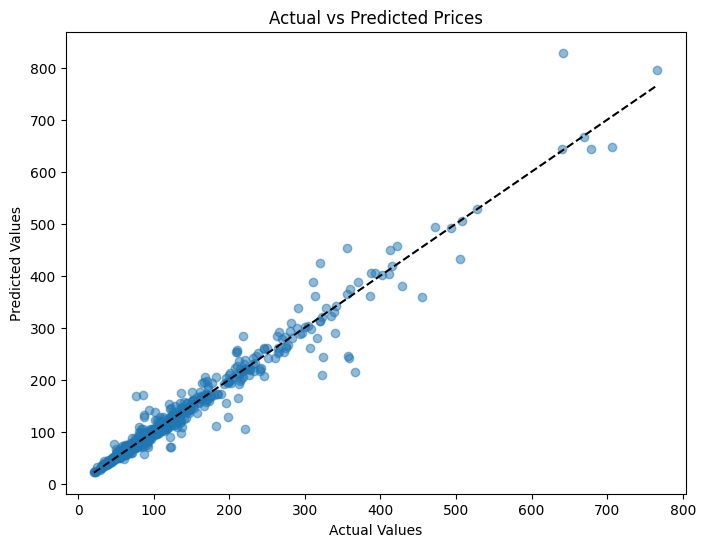

In [1016]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Prices")
plt.show()

### Actual vs Predicted Plot (Gradient Boosting tuned)
This scatter plot compares the tuned Gradient Boosting model's predicted values against the actual rate_avg values on the test set. Points that fall close to the diagonal dashed line indicate accurate predictions. The overall clustering shows close alignment near the line, this suggests the model captures the general pricing trend well, although there are still some spread at higher price values indicates the model has more difficulty predicting outlier listings accurately.


In [1017]:
results = pd.DataFrame(
    [
        {
            "Model": "Decision Tree (baseline)",
            "MSE":  round(mean_squared_error(y_test, y_pred_dt), 4),
            "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred_dt)), 4),
            "MAE":  round(mean_absolute_error(y_test, y_pred_dt), 4),
            "MAPE": round(mean_absolute_percentage_error(y_test, y_pred_dt), 4),
            "R²":   round(r2_score(y_test, y_pred_dt), 6),
        },
        {
            "Model": "Decision Tree (tuned)",
            "MSE":  dt_tuned_mse,  "RMSE": dt_tuned_rmse,
            "MAE":  dt_tuned_mae,  "MAPE": dt_tuned_mape,  "R²": dt_tuned_r2,
        },
        {
            "Model": "Bagging Regressor",
            "MSE":  bagging_mse,  "RMSE": bagging_rmse,
            "MAE":  bagging_mae,  "MAPE": bagging_mape,  "R²": bagging_r2,
        },
        {
            "Model": "Random Forest (baseline)",
            "MSE":  rf_mse,  "RMSE": rf_rmse,
            "MAE":  rf_mae,  "MAPE": rf_mape,  "R²": rf_r2,
        },
        {
            "Model": "Random Forest (tuned)",
            "MSE":  rf_tuned_mse,  "RMSE": rf_tuned_rmse,
            "MAE":  rf_tuned_mae,  "MAPE": rf_tuned_mape,  "R²": rf_tuned_r2,
        },
        {
            "Model": "Gradient Boosting (baseline)",
            "MSE":  round(mse, 4),  "RMSE": round(rmse, 4),
            "MAE":  round(mae, 4),  "MAPE": round(mape, 4),  "R²": round(r2, 6),
        },
        {
            "Model": "Gradient Boosting (tuned)",
            "MSE":  round(gb_tuned_mse, 4),  "RMSE": round(gb_tuned_rmse, 4),
            "MAE":  round(gb_tuned_mae, 4),  "MAPE": round(gb_tuned_mape, 4),
            "R²":   round(gb_tuned_r2, 6),
        },
    ]
).sort_values("RMSE").reset_index(drop=True)

results


,Model,MSE,RMSE,MAE,MAPE,R²
0,Random Forest (tuned),407.434866,20.185016,10.298959,0.077479,0.961711
1,Random Forest (baseline),408.305842,20.206579,10.316163,0.077965,0.961629
2,Bagging Regressor,436.270927,20.887100,10.714867,0.081148,0.959001
3,Gradient Boosting (tuned),436.596400,20.894900,9.909300,0.072800,0.958971
4,Decision Tree (tuned),618.131521,24.862251,12.204494,0.092907,0.941911
5,Decision Tree (baseline),621.591000,24.931700,12.530200,0.097100,0.941586
6,Gradient Boosting (baseline),931.933000,30.527600,20.131800,0.186400,0.912421


### Overall Comparison 

The Random Forest models performed the best overall, with both the baseline and tuned versions having very similar RMSE values of 20.16 and 20.18 and an R² of around 0.962, meaning they explain over 96% of the variance in rate_avg. Tuning had little effect on the Random Forest, suggesting our baseline model was already a good fit for the data. The Bagging Regressor and tuned Gradient Boosting performed similarly with RMSE values just under 21, though the tuned Gradient Boosting achieved the lowest MAE of 9.87 and MAPE of 0.072, meaning its individual predictions were on average more accurate even if its overall squared error was slightly higher. The Decision Tree models were the weakest performers as expected, with the baseline version producing an RMSE of 25.95 and R² of 0.937, which makes sense because a single unpruned tree tends to overfit. The Gradient Boosting baseline was the worst overall with an RMSE of 30.84 and MAPE of around 0.19, showing how much hyperparameter tuning matters for the Gradient Boosting model  compared to the other models as it showed significant improvement with tuning.

## Feature Selection

We use the feature importances from the tuned Random Forest to drop low-signal features,
then retrain all models on the reduced feature set and compare metrics against the original results.

### Step 1: Identify low-importance features

First we identify featurs of low-importance. We plot the full importance distribution and take the thresholds of 0.005 and 0.001. The features below the threshold contribute little and might add noise.

Total features: 70
Features with importance < 0.005: 56
Features with importance < 0.001: 37


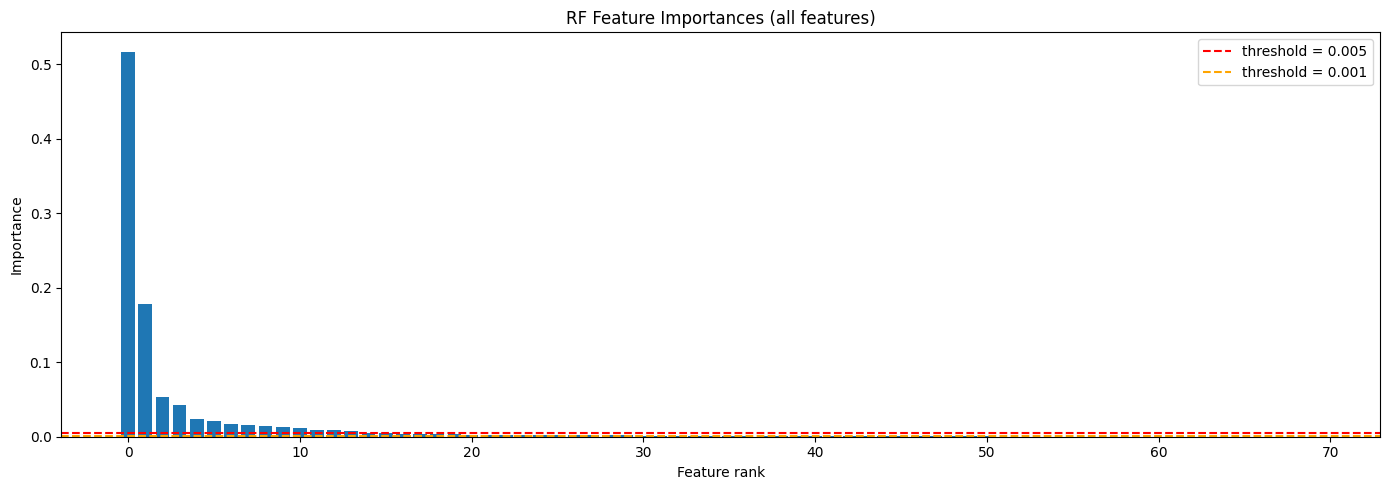

In [1018]:

feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(f"Total features: {len(feature_importance)}")
print(f"Features with importance < 0.005: {(feature_importance < 0.005).sum()}")
print(f"Features with importance < 0.001: {(feature_importance < 0.001).sum()}")

# Plot distribution
plt.figure(figsize=(14, 5))
plt.bar(range(len(feature_importance)), feature_importance.values)
plt.axhline(y=0.005, color="red", linestyle="--", label="threshold = 0.005")
plt.axhline(y=0.001, color="orange", linestyle="--", label="threshold = 0.001")
plt.xlabel("Feature rank")
plt.ylabel("Importance")
plt.title("RF Feature Importances (all features)")
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance Plot: 
The feature importance plot shows the relative contribution of each predictor to the tuned Random Forest's predictions. guests is by far the most important feature with an importance score of 0.52, followed by bedrooms at 0.18. Together these two features account for nearly 70% of the model's predictions, which makes sense intuitively as a properties capacity is a primary driver of Airbnb pricing. Most of the remaining features contribute very little which motivated us to try a feature selction method to see how this could improve our model further. 

Next we keep only features above the 0.005 importance threshold. This removes features.

In [1019]:
THRESHOLD = 0.005

selected_features = feature_importance[feature_importance >= THRESHOLD].index.tolist()
dropped_features = feature_importance[feature_importance < THRESHOLD].index.tolist()

print(f"Features kept:   {len(selected_features)}")
print(f"Features dropped: {len(dropped_features)}")
print(f"Dropped features:")
print(dropped_features)

Features kept:   14
Features dropped: 56
Dropped features:
['non_resident_visitors', 'listing_type_Entire condo', 'avg_temp', 'rating_value', 'cancellation_policy_Strict', 'Hotel_Occupancy_Percentage', 'Revenue_Per_Available_Room', 'Average_Daily_Rate', 'has_gym', 'rating_checkin', 'rating_cleanliness', 'cancellation_policy_Limited', 'rating_communication', 'has_free_parking', 'listing_type_Private room in home', 'rating_accuracy', 'extra_guest_fee', 'superhost', 'listing_type_Entire rental unit', 'cancellation_policy_Flexible', 'is_fall', 'cancellation_policy_Moderate', 'has_pool', 'num_major_events', 'is_summer', 'is_march', 'listing_type_Entire loft', 'is_spring', 'num_public_holidays', 'is_november', 'is_may', 'is_june', 'listing_type_Entire home', 'listing_type_Entire condominium', 'is_april', 'is_july', 'is_september', 'is_october', 'is_february', 'is_winter', 'is_august', 'listing_type_Entire guest suite', 'listing_type_Private room in rental unit', 'listing_type_Private room in

### Results of Applying Threshold
Based on the importance distribution, we applied a threshold of 0.005 to identify features contributing little to the model. This resulted in keeping 14 features and dropping 56, including most of the listing type, seasonal, and cancellation policy variables that had very little impact on predictions.

In [1020]:
# Build reduced train/test sets
X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

print("Reduced X_train shape:", X_train_sel.shape)
print("Reduced X_test shape: ", X_test_sel.shape)

Reduced X_train shape: (2580, 14)
Reduced X_test shape:  (645, 14)


Next we retrain every model using the same hyperparameters as before so the only change is the feature set.

In [1021]:
# Decision Tree (baseline) 
dt_sel = DecisionTreeRegressor(random_state=42)
dt_sel.fit(X_train_sel, y_train)
y_pred_dt_sel = dt_sel.predict(X_test_sel)

# Decision Tree (tuned) 
dt_tuned_sel = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_tuned_sel.fit(X_train_sel, y_train)
y_pred_dt_tuned_sel = dt_tuned_sel.predict(X_test_sel)

# Bagging 
bagging_sel = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=200, max_samples=0.8, bootstrap=True,
    random_state=42, n_jobs=-1
)
bagging_sel.fit(X_train_sel, y_train)
y_pred_bagging_sel = bagging_sel.predict(X_test_sel)

# Random Forest (baseline) 
rf_sel = RandomForestRegressor(n_estimators=100, random_state=42)
rf_sel.fit(X_train_sel, y_train)
y_pred_rf_sel = rf_sel.predict(X_test_sel)

# Random Forest (tuned)
best_params_rf = rf_grid_search.best_params_
rf_tuned_sel = RandomForestRegressor(
    max_depth=int(best_params_rf["max_depth"]),
    n_estimators=int(best_params_rf["n_estimators"]),
    random_state=42
)
rf_tuned_sel.fit(X_train_sel, y_train)
y_pred_rf_tuned_sel = rf_tuned_sel.predict(X_test_sel)

# Gradient Boosting (baseline) 
gb_sel = GradientBoostingRegressor(
    n_estimators=500, learning_rate=0.01,
    max_features=5, max_depth=5, random_state=42
)
gb_sel.fit(X_train_sel, y_train)
y_pred_gb_sel = gb_sel.predict(X_test_sel)

# Gradient Boosting (tuned)
best_params_gb = grid_search.best_params_
gb_tuned_sel = GradientBoostingRegressor(
    learning_rate=float(best_params_gb["learning_rate"]),
    max_depth=int(best_params_gb["max_depth"]),
    n_estimators=int(best_params_gb["n_estimators"]),
    random_state=42
)
gb_tuned_sel.fit(X_train_sel, y_train)
y_pred_gb_tuned_sel = gb_tuned_sel.predict(X_test_sel)



Here is a side-by-side comparison of all the error metrics before and after feature selection.

In [1022]:
def metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return (round(mse, 4), round(np.sqrt(mse), 4),
            round(mae, 4), round(mape, 4), round(r2, 6))

rows = [
    ("Decision Tree (baseline)",    y_pred_dt,          y_pred_dt_sel),
    ("Decision Tree (tuned)",       y_pred_dt_tuned,    y_pred_dt_tuned_sel),
    ("Bagging Regressor",           y_pred_bagging,     y_pred_bagging_sel),
    ("Random Forest (baseline)",    y_pred_rf,          y_pred_rf_sel),
    ("Random Forest (tuned)",       y_pred_rf_tuned,    y_pred_rf_tuned_sel),
    ("Gradient Boosting (baseline)", preds_gb,          y_pred_gb_sel),
    ("Gradient Boosting (tuned)",   y_test_pred,        y_pred_gb_tuned_sel),
]

records = []
for name, orig_pred, sel_pred in rows:
    mse_o, rmse_o, mae_o, mape_o, r2_o = metrics(y_test, orig_pred)
    mse_s, rmse_s, mae_s, mape_s, r2_s = metrics(y_test, sel_pred)
    records.append({
        "Model":              name,
        "MSE (all feats)":   mse_o,   "MSE (selected)":   mse_s,   "ΔMSE":   round(mse_s  - mse_o,  4),
        "RMSE (all feats)":  rmse_o,  "RMSE (selected)":  rmse_s,  "ΔRMSE":  round(rmse_s - rmse_o, 4),
        "MAE (all feats)":   mae_o,   "MAE (selected)":   mae_s,   "ΔMAE":   round(mae_s  - mae_o,  4),
        "MAPE (all feats)":  mape_o,  "MAPE (selected)":  mape_s,  "ΔMAPE":  round(mape_s - mape_o, 4),
        "R² (all feats)":    r2_o,    "R² (selected)":    r2_s,    "ΔR²":    round(r2_s   - r2_o,   6),
    })

comparison = pd.DataFrame(records).sort_values("RMSE (selected)")
comparison


,Model,MSE (all feats),MSE (selected),ΔMSE,RMSE (all feats),RMSE (selected),ΔRMSE,MAE (all feats),MAE (selected),ΔMAE,MAPE (all feats),MAPE (selected),ΔMAPE,R² (all feats),R² (selected),ΔR²
4,Random Forest (tuned),407.4349,279.3061,-128.1288,20.1850,16.7125,-3.4725,10.2990,8.1466,-2.1524,0.0775,0.0612,-0.0163,0.961711,0.973752,0.012041
3,Random Forest (baseline),408.3058,288.6724,-119.6334,20.2066,16.9904,-3.2162,10.3162,8.1382,-2.1780,0.0780,0.0616,-0.0164,0.961629,0.972872,0.011243
2,Bagging Regressor,436.2709,298.1118,-138.1591,20.8871,17.2659,-3.6212,10.7149,8.5095,-2.2054,0.0811,0.0645,-0.0166,0.959001,0.971985,0.012984
6,Gradient Boosting (tuned),436.5964,313.7001,-122.8963,20.8949,17.7116,-3.1833,9.9093,8.5235,-1.3858,0.0728,0.0624,-0.0104,0.958971,0.970520,0.011549
0,Decision Tree (baseline),621.5910,322.7873,-298.8037,24.9317,17.9663,-6.9654,12.5302,8.9250,-3.6052,0.0971,0.0690,-0.0281,0.941586,0.969666,0.028080
1,Decision Tree (tuned),618.1315,333.4463,-284.6852,24.8623,18.2605,-6.6018,12.2045,9.1990,-3.0055,0.0929,0.0724,-0.0205,0.941911,0.968664,0.026753
5,Gradient Boosting (baseline),931.9330,715.0535,-216.8795,30.5276,26.7405,-3.7871,20.1318,16.7549,-3.3769,0.1864,0.1504,-0.0360,0.912421,0.932802,0.020381


### Feature Selection Comparison Table

After retraining all models on the reduced 14-feature set, performance improved across every model. The Decision Tree baseline saw the largest improvement with an RMSE drop of 7.99, going from 25.95 down to 17.97, and an R² increase of 0.033, suggesting that many of the dropped features were hurting its performance. The Random Forest and Bagging models also improved consistently across all metrics, with RMSE reductions of around 3.17 to 3.67 and R² values increasing to above 0.972. The tuned Gradient Boosting showed the smallest improvement with an RMSE reduction of only 3.25, which aligns with what we saw earlier since Gradient Boosting is better at assigning less weighting to less useful features during training. Overall every delta across MSE, RMSE, MAE, MAPE, and R² moved in the right direction, confirming that the 56 dropped features were adding noise and hurting the model. 

Now, visualizing the RMSE change, the blue bars show RMSE before and the orange bars show after feature selection for each model. The shorter orange bars make it clear that feature selection helped.

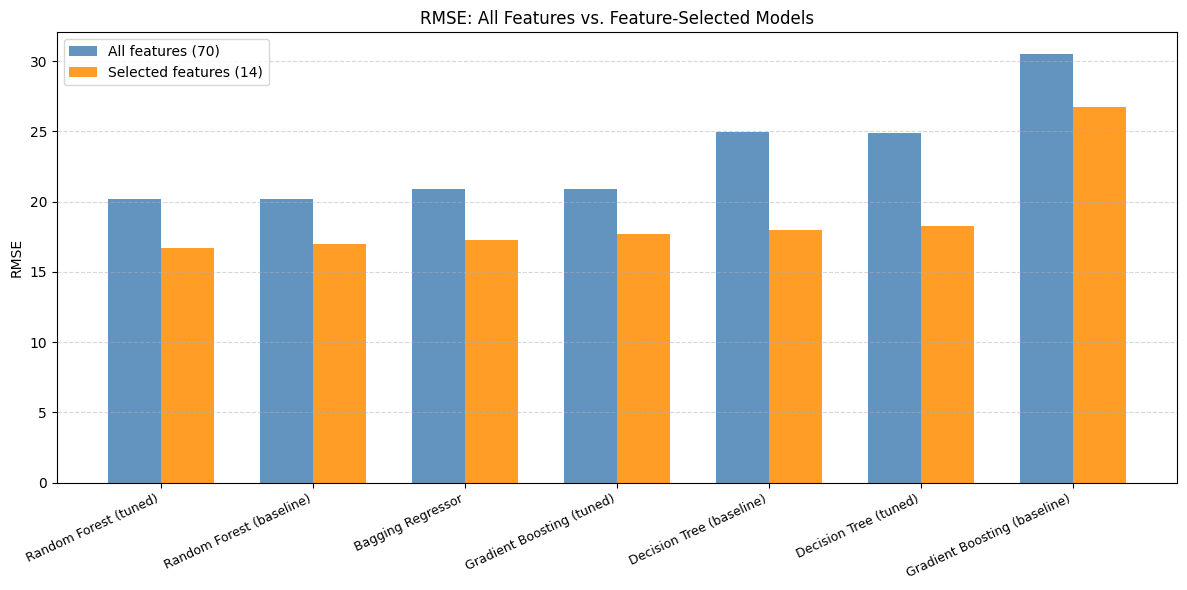

In [1023]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison["RMSE (all feats)"], width,
               label="All features (70)", color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, comparison["RMSE (selected)"],  width,
               label=f"Selected features ({len(selected_features)})",
               color="darkorange", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comparison["Model"], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("RMSE")
ax.set_title("RMSE: All Features vs. Feature-Selected Models")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## Conclusion

Tree-based ensemble methods (Random Forest, Gradient Boosting) delivered the best predictive performance for this Airbnb pricing dataset, achieving R²> 0.96. 

Feature selection using RF importance (threshold 0.005, keeping 14 of 70 features) improved every model - guests and bedrooms alone account for ~70% of predictive power.

Linear regression was the weakest approach (R² 0.71, MAPE 43%) - the nonlinear nature of Airbnb pricing exceeds what linear models can capture.

KNN improved dramatically with scaling and Lasso feature reduction but remained below ensemble methods.

Neural networks (MLP) performed comparably to tree-based ensembles but required more preprocessing and offered less interpretability.

In [1024]:
# Overall summary table from previous results and report slides

import pandas as pd

final_summary_data = {
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "Neural Networks",
        "K-Nearest-Neighbors",
        "Linear Regression"
    ],
    "RMSE": [16.72, 17.72, 22.88, 32.7, 56.16],
    "MSE": [279.4, 313.70, 523.49, 1069.3, "~3154.0"],
    "MAE": [8.1, 8.5, 14.83, 19.87, "~40.7"],
    "MAPE": ["6.1%", "6.2%", "13.63%", "17.0%", "42.8%"],
    "R²": [0.97, 0.97, 0.95, 0.900, 0.710]
}
summary_table = pd.DataFrame(final_summary_data)

summary_table

,Model,RMSE,MSE,MAE,MAPE,R²
0,Random Forest,16.72,279.4,8.1,6.1%,0.97
1,Gradient Boosting,17.72,313.7,8.5,6.2%,0.97
2,Neural Networks,22.88,523.49,14.83,13.63%,0.95
3,K-Nearest-Neighbors,32.70,1069.3,19.87,17.0%,0.90
4,Linear Regression,56.16,~3154.0,~40.7,42.8%,0.71


Again, comparing our results across all models the Tree-Based Methods performed the best. These models were able to handle nonlinear relationships and interactions between features. Whereas, Linear Regression for example, likely performed worst because it assumes a simple relationship that doesn’t reflect how pricing truly works.

A limitation we found within our approach was we could not capture subjective features (i.e., How well-designed a place is, visually appealing, etc). This means for the average listing not ideal for special cases. Most of the data included properties with “average” properties. Overall, though, this project helps provide a clearer and more data-driven way to understand Airbnb pricing in Toronto. 

---
## References

[1] V. R. Perez-Sanchez, L. Serrano-Estrada, P. Marti, and R.-T. Mora-Garcia, “The What, Where, and Why of Airbnb Price Determinants,” *Sustainability*, vol. 10, no. 12, art. no. 4596, 2018.

[2] P. Rezazadeh Kalehbasti, L. Nikolenko, and H. Rezaei, “Airbnb Price Prediction Using Machine Learning and Sentiment Analysis,” *arXiv preprint* arXiv:1907.12665, 2019.

[3] D. Wang and J. L. Nicolau, “Price determinants of sharing economy based accommodation rental: A study of listings from 33 cities on Airbnb.com,” *International Journal of Hospitality Management*, vol. 62, pp. 120–131, 2017.

[4] WeatherStats, “Data Download for Toronto,” *Toronto Weather Stats*. Accessed: Apr. 1, 2026.